# 카카오 스타일 데이터 사이언스팀 과제
## Task #1: 데이터 분석

## 분석 개요
- **데이터**: 2018년 6월 11일 하루치 지그재그 앱 이용자 로그 및 관련 정보
- **목적**: 유저 행동 패턴 파악, 전환율 분석, 인기 상품/쇼핑몰 도출, 비즈니스 인사이트 도출

## 분석 목차
1. 데이터 로딩 및 전처리
2. 데이터 품질 검토 (결측값·이상값)
3. 기초 통계 요약
4. 유저 분석 (연령대, OS, 활동 수준)
5. 이벤트 로그 분석 (시간대별, 유입 경로별)
6. 상품 분석 (카테고리, 가격대, 이미지)
7. 쇼핑몰 분석 (카테고리, 스타일, 연령대 타겟)
8. 전환율 분석 – 유저 단위 퍼널
9. 연령대별 행동 패턴
10. 인기 상품 및 쇼핑몰 분석
11. 유저 세그먼트 심화 분석
12. 통계적 유의성 검정
13. 세션 분석
14. 가격 민감도 분석
15. 종합 인사이트 요약


## 1. 데이터 로딩 및 전처리


In [1]:
import matplotlib.font_manager as fm

for font in fm.findSystemFonts():
    if 'malgun' in font.lower():
        print(font)

C:\Windows\Fonts\malgunsl.ttf
C:\Windows\Fonts\malgun.ttf
C:\Windows\Fonts\malgunbd.ttf


In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한국어 폰트 설정
import matplotlib.font_manager as fm
# Windows 기본 한글 폰트
font_path = "C:\Windows\Fonts\malgun.ttf"
font = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = font.get_name()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
sns.set_palette('Set2')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로딩 완료')

<>:13: SyntaxWarning: invalid escape sequence '\W'
<>:13: SyntaxWarning: invalid escape sequence '\W'
C:\Users\eunyeong\AppData\Local\Temp\ipykernel_23940\2572850295.py:13: SyntaxWarning: invalid escape sequence '\W'
  font_path = "C:\Windows\Fonts\malgun.ttf"


라이브러리 로딩 완료


In [3]:
# ── 데이터 로딩 ──────────────────────────────
goods  = pd.read_csv('goods_info.csv',      encoding='utf-8')
orders = pd.read_csv('order_info.csv',      encoding='utf-8')
shops  = pd.read_csv('shop_info.csv',       encoding='utf-8')
users  = pd.read_csv('user_info.csv',       encoding='utf-8')
logs   = pd.read_csv('user_event_logs.csv', encoding='utf-8')

# ── 타입 변환 ─────────────────────────────────
logs['timestamp']   = pd.to_datetime(logs['timestamp'])
orders['timestamp'] = pd.to_datetime(orders['timestamp'])
goods['timestamp']  = pd.to_datetime(goods['timestamp'])

# ── 시간 파생 변수 ──────────────────────────────
logs['hour']   = logs['timestamp'].dt.hour
logs['minute'] = logs['timestamp'].dt.minute

orders['hour'] = orders['timestamp'].dt.hour

print('데이터 로딩 완료')
print(f'  logs   : {logs.shape}')
print(f'  orders : {orders.shape}')
print(f'  goods  : {goods.shape}')
print(f'  shops  : {shops.shape}')
print(f'  users  : {users.shape}')

데이터 로딩 완료
  logs   : (105815, 8)
  orders : (867, 6)
  goods  : (7188, 8)
  shops  : (200, 5)
  users  : (10000, 3)


In [4]:
# ── 이벤트 유입 경로 분류 ─────────────────────────
def classify_origin(o):
    o = str(o)
    if 'goods_search' in o:    return '상품 검색'
    elif 'shops_ranking' in o: return '쇼핑몰 랭킹'
    elif 'shops_bookmark' in o:return '즐겨찾기'
    elif 'category' in o:      return '카테고리 검색'
    elif 'my_goods' in o:      return '내 상품'
    else:                       return '기타'

logs['origin_type'] = logs['event_origin'].apply(classify_origin)

# ── 연령대 분류 ──────────────────────────────────
def age_group(age):
    if age < 0:    return '미입력'
    elif age < 20: return '10대'
    elif age < 25: return '20대 초반'
    elif age < 30: return '20대 후반'
    elif age < 35: return '30대 초반'
    elif age < 40: return '30대 후반'
    elif age <= 45: return '40대'
    else:           return '기타'

users['age_group'] = users['age'].apply(age_group)

# ── 가격대 분류 ──────────────────────────────────
def price_band(price):
    if price < 10000:    return '1만원 미만'
    elif price < 20000:  return '1-2만원'
    elif price < 30000:  return '2-3만원'
    elif price < 50000:  return '3-5만원'
    elif price < 100000: return '5-10만원'
    else:                return '10만원 이상'

goods['price_band'] = goods['price'].apply(price_band)
orders['price_band'] = orders['price'].apply(price_band)

# ── 이미지 비율 ──────────────────────────────────
goods['aspect_ratio'] = goods['image_height'] / goods['image_width']
goods['img_size_label'] = goods.apply(
    lambda r: '정사각형' if abs(r['aspect_ratio']-1)<0.05
              else ('세로형' if r['aspect_ratio']>1 else '가로형'), axis=1)

print('전처리 완료')

전처리 완료


In [5]:
# ── logs ↔ users 병합 ────────────────────────────
logs_u = logs.merge(users[['user_id','os','age','age_group']], on='user_id', how='left')

# ── orders ↔ users 병합 ──────────────────────────
orders_u = orders.merge(users[['user_id','os','age','age_group']], on='user_id', how='left')

# ── orders ↔ goods 병합 ──────────────────────────
orders_g = orders_u.merge(goods[['goods_id','category','price_band']], on='goods_id', how='left')

print('병합 완료')

병합 완료


## 2. 데이터 품질 검토 (결측값 · 이상값)

분석 신뢰도를 높이기 위해 결측값·이상값을 먼저 확인합니다.


In [6]:
# ── 각 데이터셋 결측값 현황 ──────────────────────────────
import pandas as pd

datasets = {'logs': logs, 'orders': orders, 'goods': goods, 'shops': shops, 'users': users}

for name, df in datasets.items():
    null_cnt = df.isnull().sum()
    null_pct = (null_cnt / len(df) * 100).round(2)
    has_null = null_cnt[null_cnt > 0]
    if len(has_null) > 0:
        print(f'■ [{name}] 결측값 존재 컬럼')
        for col in has_null.index:
            print(f'   {col}: {null_cnt[col]:,}건 ({null_pct[col]:.1f}%)')
    else:
        print(f'■ [{name}] 결측값 없음 ✓')
    print()


■ [logs] 결측값 존재 컬럼
   event_goods_id: 87,294건 (82.5%)
   event_shop_id: 84,171건 (79.5%)

■ [orders] 결측값 없음 ✓

■ [goods] 결측값 없음 ✓

■ [shops] 결측값 존재 컬럼
   age: 61건 (30.5%)
   style: 41건 (20.5%)

■ [users] 결측값 없음 ✓



■ 상품 가격 (goods) 기술통계
count      7,188
mean      30,186
std       25,043
min          100
25%       17,000
50%       26,000
75%       37,000
max      648,000
Name: price, dtype: object
  0원 이하 상품: 0건
  10만원 초과 상품: 96건

■ 구매 가격 (orders) 기술통계
count        867
mean      22,790
std       12,783
min          100
25%       13,400
50%       20,000
75%       29,900
max      104,000
Name: price, dtype: object
  0원 이하 구매: 0건

■ 유저 나이 (users) 분포
  age < 0 (미입력): 343명 (3.4%)
  age 0~9 (10세 미만): 0명
  age 46+ (이상 범위): 0명

■ 연령 미입력 유저 vs 입력 유저 비교
  평균 이벤트 수 – 미입력: 14.0회  /  입력: 10.6회
  구매 전환율   – 미입력: 12.2%   /  입력: 8.2%


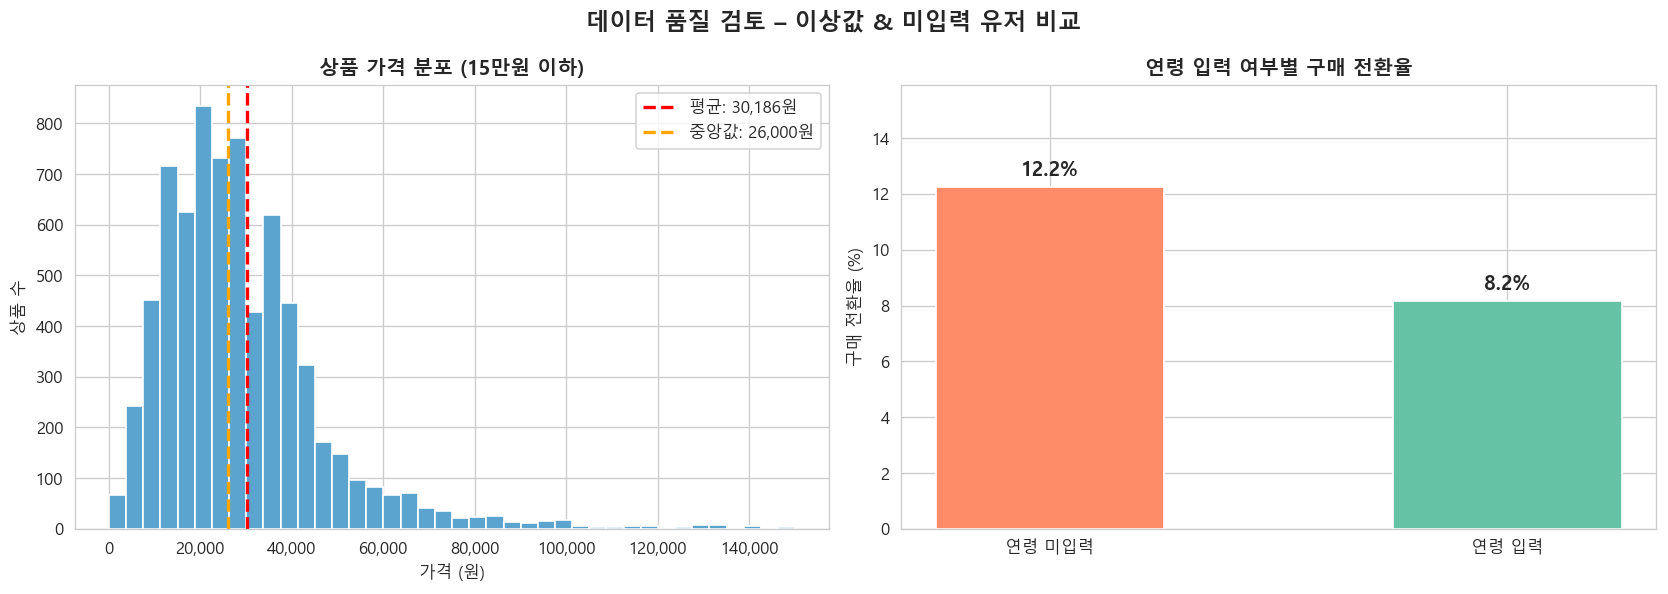

In [7]:
# ── 이상값 탐지 ────────────────────────────────────────────

# 1) 상품 가격 이상값
print('■ 상품 가격 (goods) 기술통계')
print(goods['price'].describe().apply(lambda x: f'{x:,.0f}'))
print(f'  0원 이하 상품: {(goods["price"] <= 0).sum()}건')
print(f'  10만원 초과 상품: {(goods["price"] > 100000).sum()}건')
print()

# 2) 구매 가격 이상값
print('■ 구매 가격 (orders) 기술통계')
print(orders['price'].describe().apply(lambda x: f'{x:,.0f}'))
print(f'  0원 이하 구매: {(orders["price"] <= 0).sum()}건')
print()

# 3) 유저 나이 분포
print('■ 유저 나이 (users) 분포')
print(f'  age < 0 (미입력): {(users["age"] < 0).sum():,}명 ({(users["age"] < 0).mean()*100:.1f}%)')
print(f'  age 0~9 (10세 미만): {((users["age"] >= 0) & (users["age"] < 10)).sum()}명')
print(f'  age 46+ (이상 범위): {(users["age"] > 45).sum()}명')
print()

# 4) 미입력 유저 행동 특성 비교
unknown_ids = users[users['age'] < 0]['user_id']
known_ids   = users[users['age'] >= 0]['user_id']

unk_event_mean = logs[logs['user_id'].isin(unknown_ids)]['user_id'].value_counts().mean()
kno_event_mean = logs[logs['user_id'].isin(known_ids)]['user_id'].value_counts().mean()

unk_buy_rate = orders[orders['user_id'].isin(unknown_ids)]['user_id'].nunique() / len(unknown_ids) * 100
kno_buy_rate = orders[orders['user_id'].isin(known_ids)]['user_id'].nunique()  / len(known_ids)   * 100

print('■ 연령 미입력 유저 vs 입력 유저 비교')
print(f'  평균 이벤트 수 – 미입력: {unk_event_mean:.1f}회  /  입력: {kno_event_mean:.1f}회')
print(f'  구매 전환율   – 미입력: {unk_buy_rate:.1f}%   /  입력: {kno_buy_rate:.1f}%')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('데이터 품질 검토 – 이상값 & 미입력 유저 비교', fontsize=14, fontweight='bold')

# 가격 분포 (이상값 포함)
ax = axes[0]
ax.hist(goods['price'][goods['price'] <= 150000], bins=40, color='#5BA4CF', edgecolor='white')
ax.axvline(goods['price'].mean(),   color='red',    linestyle='--', linewidth=2, label=f'평균: {goods["price"].mean():,.0f}원')
ax.axvline(goods['price'].median(), color='orange', linestyle='--', linewidth=2, label=f'중앙값: {goods["price"].median():,.0f}원')
ax.set_title('상품 가격 분포 (15만원 이하)', fontsize=12, fontweight='bold')
ax.set_xlabel('가격 (원)')
ax.set_ylabel('상품 수')
ax.legend()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 미입력 vs 입력 구매 전환율 비교
ax = axes[1]
labels = ['연령 미입력', '연령 입력']
vals   = [unk_buy_rate, kno_buy_rate]
colors_q = ['#FF8C69', '#66C2A5']
bars = ax.bar(labels, vals, color=colors_q, edgecolor='white', width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('연령 입력 여부별 구매 전환율', fontsize=12, fontweight='bold')
ax.set_ylabel('구매 전환율 (%)')
ax.set_ylim(0, max(vals)*1.3)

plt.tight_layout()
plt.savefig('output/fig_00_data_quality.png', bbox_inches='tight')
plt.show()


## 3. 기초 통계 요약


In [8]:
summary = {
    '분석 날짜': '2018-06-11 (하루치 데이터)',
    '총 이용자 수': f"{users['user_id'].nunique():,}",
    '총 이벤트 수': f"{len(logs):,}",
    '총 주문 수':   f"{len(orders):,}",
    '총 쇼핑몰 수': f"{shops['shop_id'].nunique():,}",
    '총 상품 수':   f"{goods['goods_id'].nunique():,}",
    '활동 유저 수 (로그 기록 있는)': f"{logs['user_id'].nunique():,}",
    '구매 발생 유저 수': f"{orders['user_id'].nunique():,}",
    '전체 전환율 (구매유저/활동유저)': f"{orders['user_id'].nunique()/logs['user_id'].nunique()*100:.2f}%",
}

for k, v in summary.items():
    print(f'  {k:35s}: {v}')

  분석 날짜                              : 2018-06-11 (하루치 데이터)
  총 이용자 수                            : 10,000
  총 이벤트 수                            : 105,815
  총 주문 수                             : 867
  총 쇼핑몰 수                            : 200
  총 상품 수                             : 7,188
  활동 유저 수 (로그 기록 있는)                 : 9,909
  구매 발생 유저 수                         : 832
  전체 전환율 (구매유저/활동유저)                 : 8.40%


## 4. 유저 분석


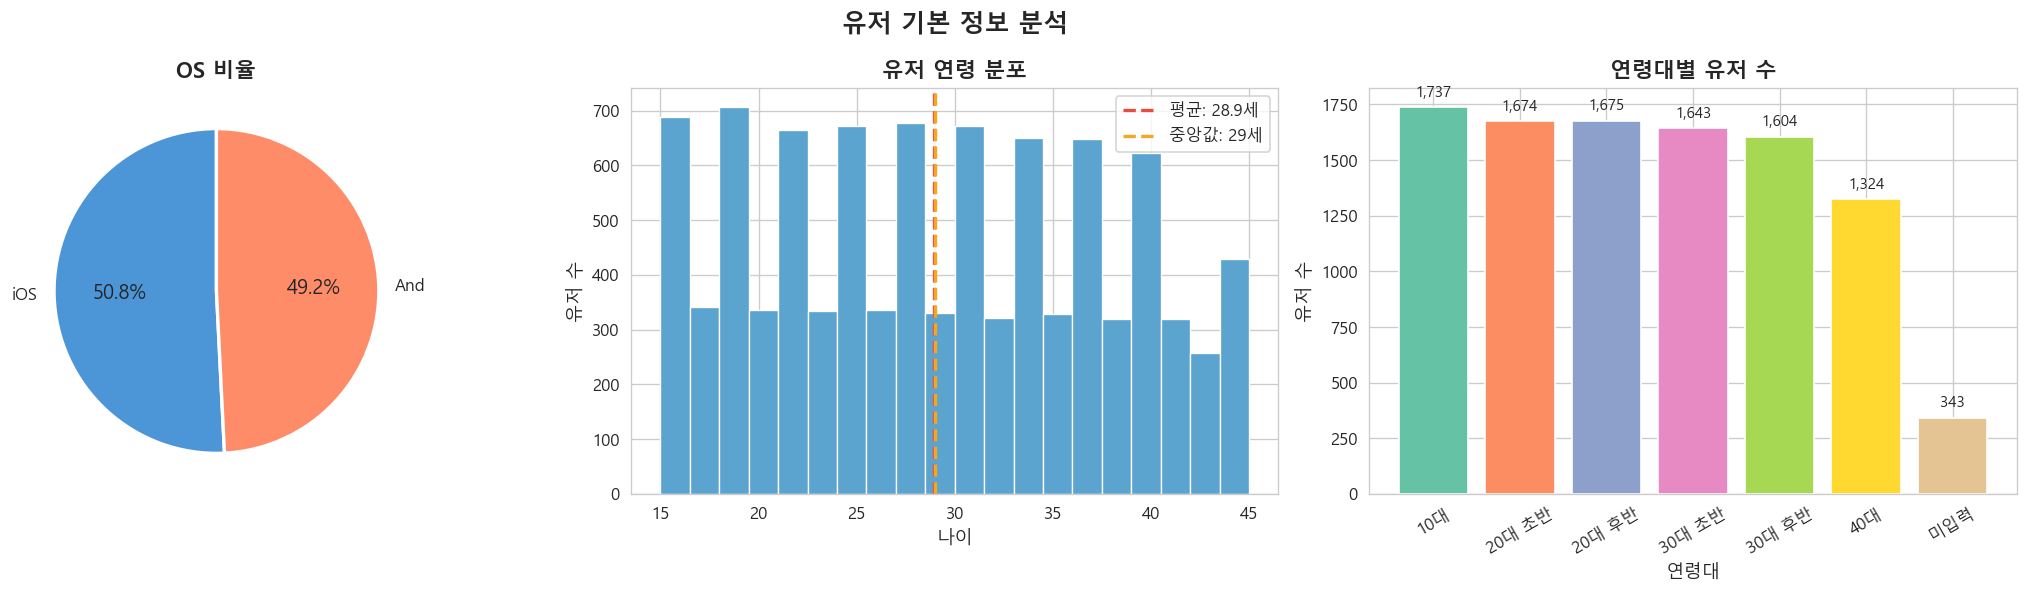

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('유저 기본 정보 분석', fontsize=15, fontweight='bold')

# ── (1) OS 분포 ──────────────────────────────────
ax = axes[0]
os_cnt = users['os'].value_counts()
colors = ['#4C96D7', '#FF8C69']
wedges, texts, autotexts = ax.pie(
    os_cnt.values, labels=os_cnt.index, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontsize(12)
ax.set_title('OS 비율', fontsize=13, fontweight='bold')

# ── (2) 연령 분포 히스토그램 ──────────────────────
ax = axes[1]
valid_age = users[users['age'] >= 0]['age']
ax.hist(valid_age, bins=20, color='#5BA4CF', edgecolor='white', linewidth=0.8)
ax.axvline(valid_age.mean(), color='#E94B3C', linestyle='--', linewidth=2,
           label=f'평균: {valid_age.mean():.1f}세')
ax.axvline(valid_age.median(), color='#F5A623', linestyle='--', linewidth=2,
           label=f'중앙값: {valid_age.median():.0f}세')
ax.set_xlabel('나이', fontsize=11)
ax.set_ylabel('유저 수', fontsize=11)
ax.set_title('유저 연령 분포', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# ── (3) 연령대 분포 ──────────────────────────────
ax = axes[2]
age_order = ['10대', '20대 초반', '20대 후반', '30대 초반', '30대 후반', '40대', '미입력']
age_cnt = users['age_group'].value_counts().reindex(age_order).fillna(0)
bars = ax.bar(age_cnt.index, age_cnt.values,
              color=sns.color_palette('Set2', len(age_cnt)), edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+30, f'{h:,.0f}',
            ha='center', va='bottom', fontsize=9)
ax.set_xlabel('연령대', fontsize=11)
ax.set_ylabel('유저 수', fontsize=11)
ax.set_title('연령대별 유저 수', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('output/fig_01_user_basic.png', bbox_inches='tight')
plt.show()

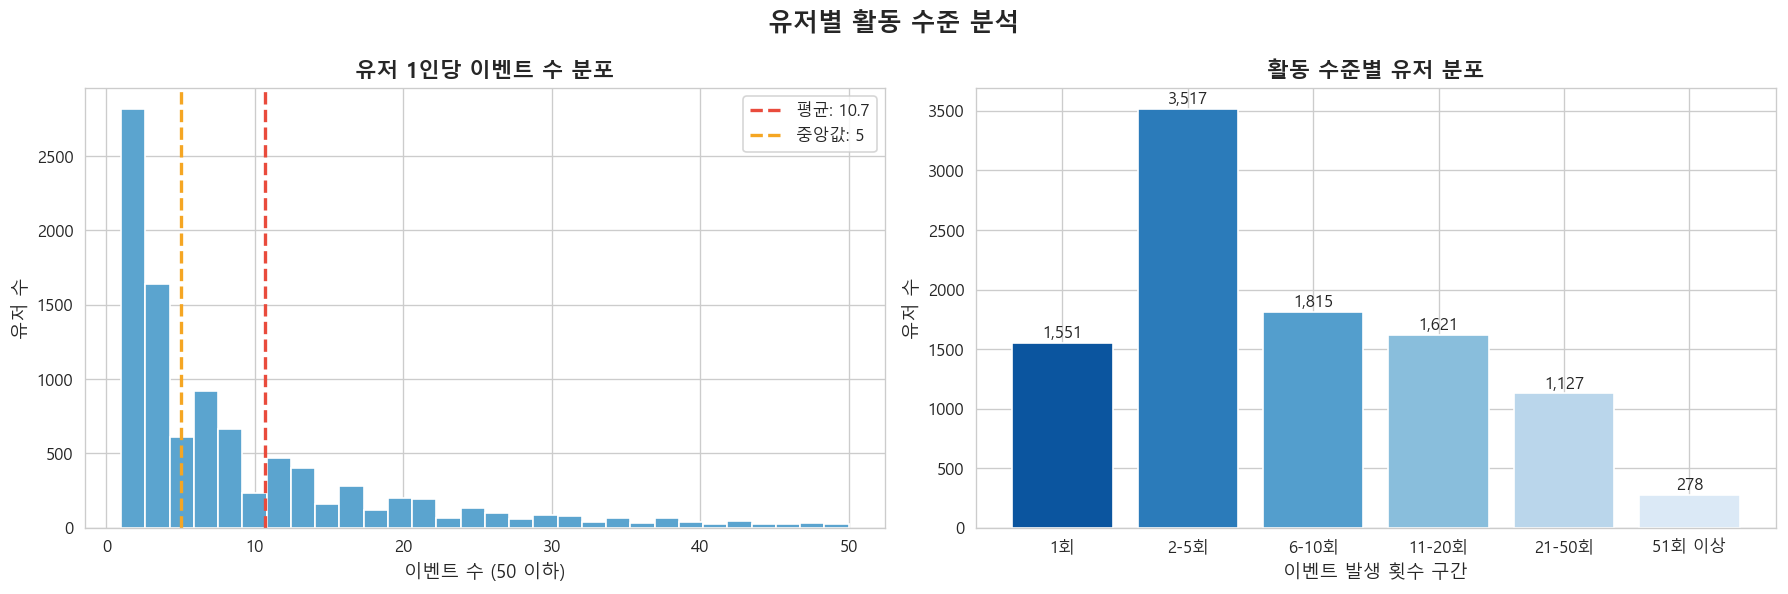


활동 유저 수: 9,909명 / 전체 10,000명
비활동 유저 수 (로그 없음): 91명
유저 1인당 평균 이벤트: 10.7회
유저 1인당 최대 이벤트: 231회


In [10]:
# ── 유저별 이벤트 수 분포 (활동 수준) ────────────────
user_event_cnt = logs['user_id'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('유저별 활동 수준 분석', fontsize=15, fontweight='bold')

ax = axes[0]
ax.hist(user_event_cnt[user_event_cnt <= 50], bins=30,
        color='#5BA4CF', edgecolor='white')
ax.axvline(user_event_cnt.mean(), color='#E94B3C', linestyle='--', linewidth=2,
           label=f'평균: {user_event_cnt.mean():.1f}')
ax.axvline(user_event_cnt.median(), color='#F5A623', linestyle='--', linewidth=2,
           label=f'중앙값: {user_event_cnt.median():.0f}')
ax.set_xlabel('이벤트 수 (50 이하)', fontsize=11)
ax.set_ylabel('유저 수', fontsize=11)
ax.set_title('유저 1인당 이벤트 수 분포', fontsize=13, fontweight='bold')
ax.legend()

ax = axes[1]
# 활동 구간별 분류
bins_labels = ['1회', '2-5회', '6-10회', '11-20회', '21-50회', '51회 이상']
bins_vals = [1, 2, 6, 11, 21, 51, user_event_cnt.max()+1]
activity_seg = pd.cut(user_event_cnt, bins=[0,1,5,10,20,50,9999],
                       labels=['1회','2-5회','6-10회','11-20회','21-50회','51회 이상'])
seg_cnt = activity_seg.value_counts().reindex(['1회','2-5회','6-10회','11-20회','21-50회','51회 이상'])
colors_seg = sns.color_palette('Blues_r', len(seg_cnt))
bars = ax.bar(seg_cnt.index, seg_cnt.values, color=colors_seg, edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+5, f'{h:,.0f}',
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel('이벤트 발생 횟수 구간', fontsize=11)
ax.set_ylabel('유저 수', fontsize=11)
ax.set_title('활동 수준별 유저 분포', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('output/fig_02_user_activity.png', bbox_inches='tight')
plt.show()

print(f"\n활동 유저 수: {len(user_event_cnt):,}명 / 전체 {len(users):,}명")
print(f"비활동 유저 수 (로그 없음): {len(users) - len(user_event_cnt):,}명")
print(f"유저 1인당 평균 이벤트: {user_event_cnt.mean():.1f}회")
print(f"유저 1인당 최대 이벤트: {user_event_cnt.max()}회")

## 5. 이벤트 로그 분석


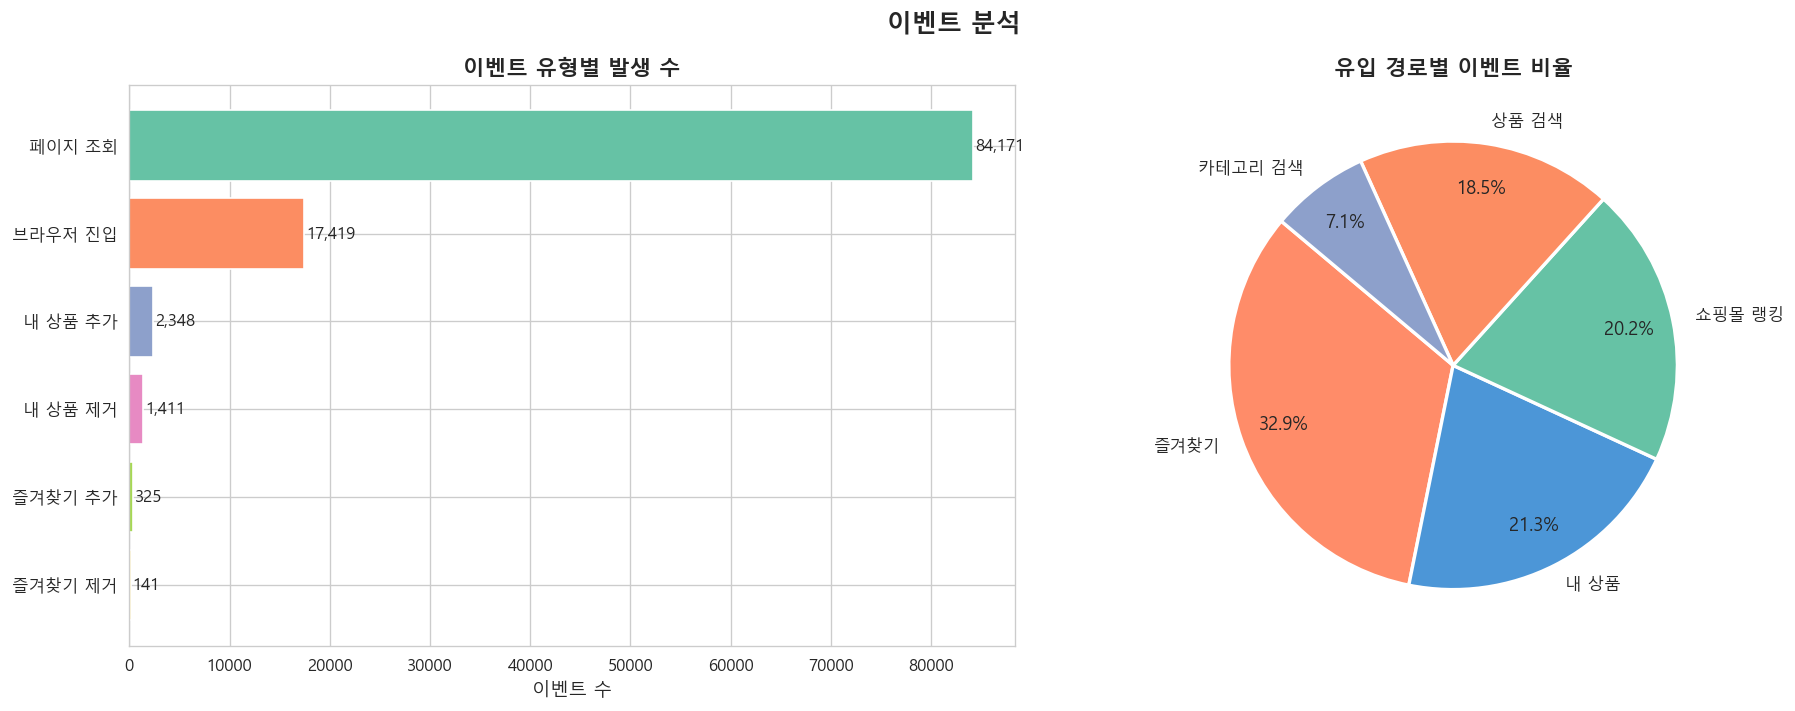

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('이벤트 분석', fontsize=15, fontweight='bold')

# ── (1) 이벤트 유형별 수 ─────────────────────────
ax = axes[0]
event_cnt = logs['event_name'].value_counts()
event_label_map = {
    'app_page_view':    '페이지 조회',
    'enter_browser':    '브라우저 진입',
    'add_my_goods':     '내 상품 추가',
    'remove_my_goods':  '내 상품 제거',
    'add_bookmark':     '즐겨찾기 추가',
    'remove_bookmark':  '즐겨찾기 제거',
}
event_cnt.index = [event_label_map.get(i, i) for i in event_cnt.index]
colors_e = sns.color_palette('Set2', len(event_cnt))
bars = ax.barh(event_cnt.index[::-1], event_cnt.values[::-1], color=colors_e[::-1])
for bar in bars:
    w = bar.get_width()
    ax.text(w+200, bar.get_y()+bar.get_height()/2, f'{w:,}',
            va='center', fontsize=10)
ax.set_xlabel('이벤트 수', fontsize=11)
ax.set_title('이벤트 유형별 발생 수', fontsize=13, fontweight='bold')

# ── (2) 유입 경로별 이벤트 수 ──────────────────────
ax = axes[1]
origin_cnt = logs['origin_type'].value_counts()
colors_o = ['#FF8C69','#4C96D7','#66C2A5','#FC8D62','#8DA0CB']
wedges, texts, autotexts = ax.pie(
    origin_cnt.values, labels=origin_cnt.index, autopct='%1.1f%%',
    colors=colors_o, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.8)
for at in autotexts: at.set_fontsize(11)
ax.set_title('유입 경로별 이벤트 비율', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('output/fig_03_event_overview.png', bbox_inches='tight')
plt.show()

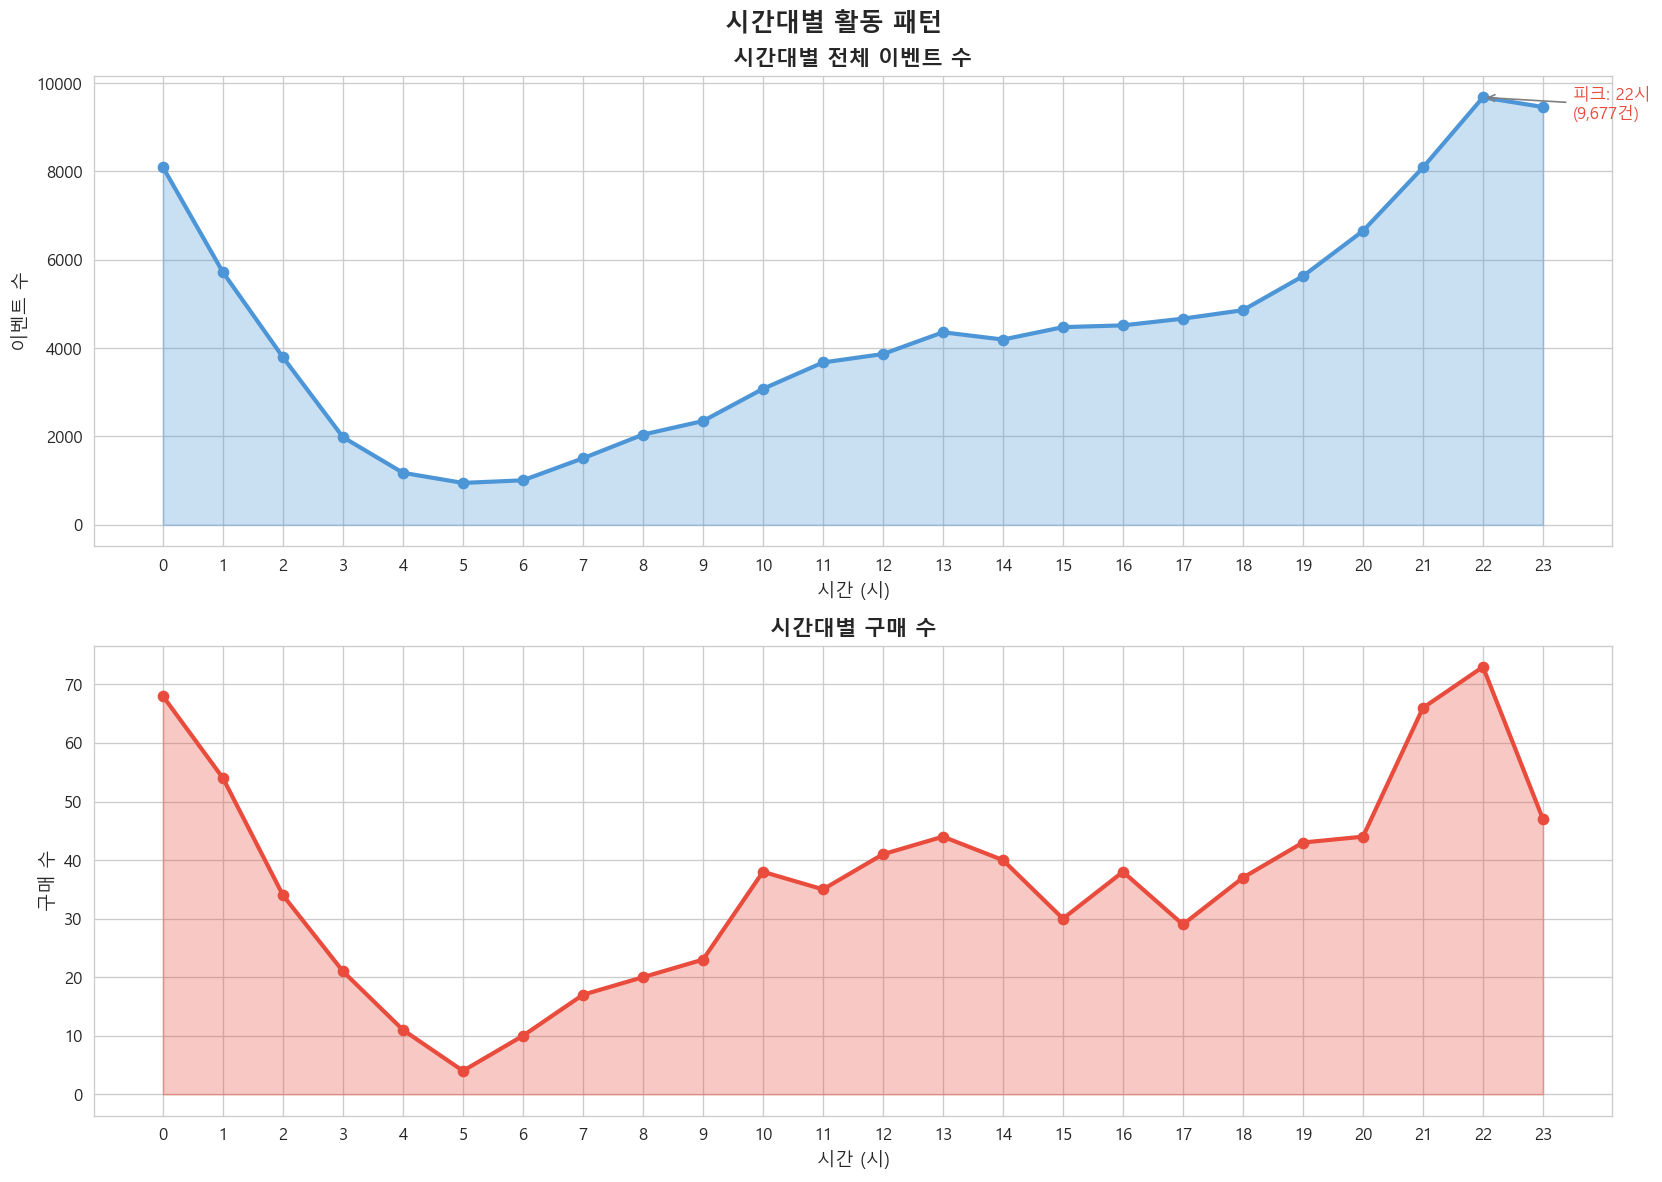


■ 시간대별 이벤트 상위 5개 시간대
 hour  count
   22   9677
   23   9459
    0   8095
   21   8090
   20   6653


In [12]:
# ── 시간대별 이벤트 수 ───────────────────────────────
hourly = logs.groupby('hour').size().reset_index(name='count')
hourly_order = orders.groupby('hour').size().reset_index(name='count')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('시간대별 활동 패턴', fontsize=15, fontweight='bold')

# 전체 이벤트
ax = axes[0]
ax.fill_between(hourly['hour'], hourly['count'], alpha=0.3, color='#4C96D7')
ax.plot(hourly['hour'], hourly['count'], marker='o', color='#4C96D7',
        linewidth=2.5, markersize=6)
peak_h = hourly.loc[hourly['count'].idxmax()]
ax.annotate(f"피크: {int(peak_h['hour'])}시\n({peak_h['count']:,}건)",
            xy=(peak_h['hour'], peak_h['count']),
            xytext=(peak_h['hour']+1.5, peak_h['count']-500),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='#E94B3C')
ax.set_xticks(range(0, 24))
ax.set_xlabel('시간 (시)', fontsize=11)
ax.set_ylabel('이벤트 수', fontsize=11)
ax.set_title('시간대별 전체 이벤트 수', fontsize=13, fontweight='bold')

# 구매 이벤트
ax = axes[1]
ax.fill_between(hourly_order['hour'], hourly_order['count'], alpha=0.3, color='#E94B3C')
ax.plot(hourly_order['hour'], hourly_order['count'], marker='o', color='#E94B3C',
        linewidth=2.5, markersize=6)
ax.set_xticks(range(0, 24))
ax.set_xlabel('시간 (시)', fontsize=11)
ax.set_ylabel('구매 수', fontsize=11)
ax.set_title('시간대별 구매 수', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('output/fig_04_hourly_pattern.png', bbox_inches='tight')
plt.show()

print('\n■ 시간대별 이벤트 상위 5개 시간대')
print(hourly.nlargest(5, 'count').to_string(index=False))

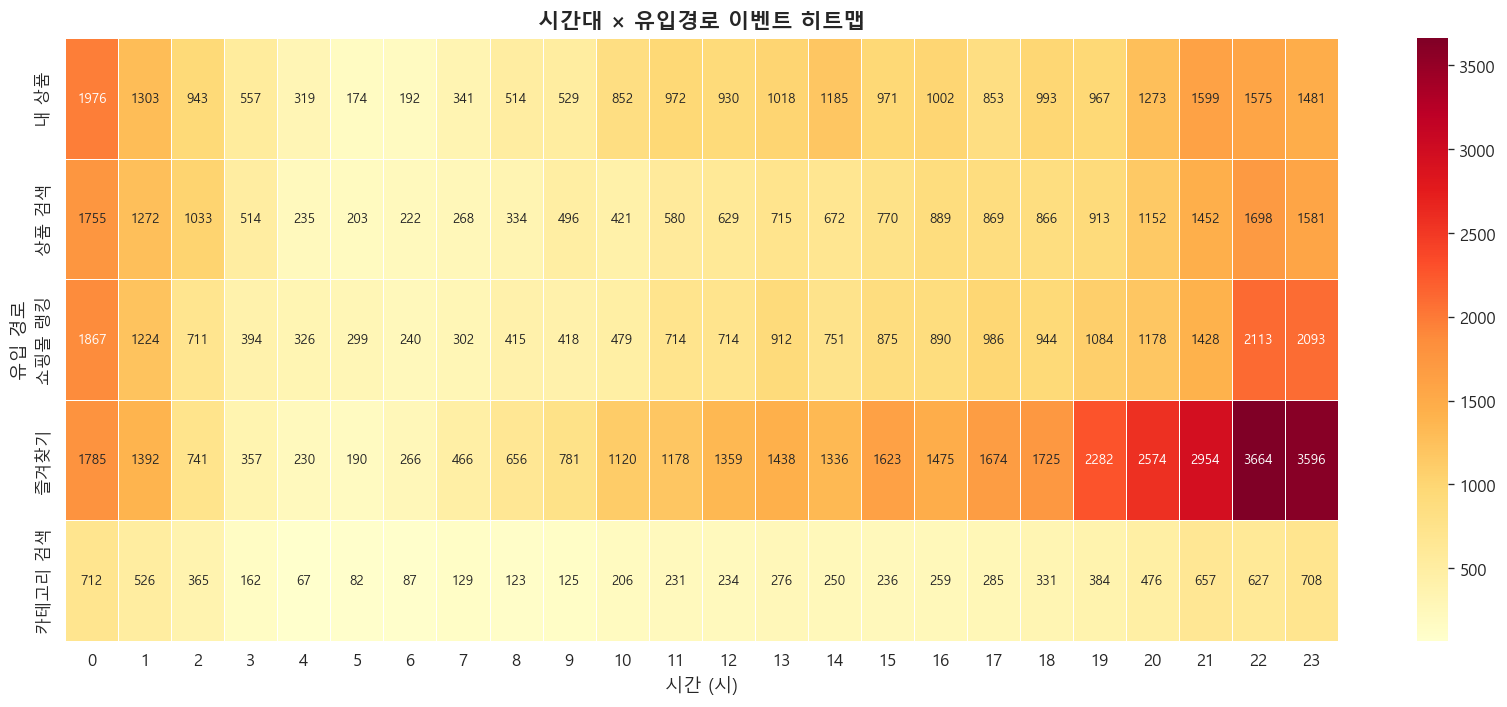

In [13]:
# ── 시간대 × 유입경로 히트맵 ───────────────────────
pivot_origin_hour = logs.groupby(['hour','origin_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_origin_hour.T, ax=ax, cmap='YlOrRd',
            linewidths=0.5, annot=True, fmt='d', annot_kws={'size':8})
ax.set_xlabel('시간 (시)', fontsize=11)
ax.set_ylabel('유입 경로', fontsize=11)
ax.set_title('시간대 × 유입경로 이벤트 히트맵', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/fig_05_heatmap_hour_origin.png', bbox_inches='tight')
plt.show()

### 5-5. 유입 경로별 구매 효율 분석
단순 유입 비중만으로는 실무 우선순위를 정하기 어렵기 때문에,  
유입 경로별 클릭·구매 효율을 함께 확인합니다.  
아래 분석은 탐색적 분석으로, 동일 유저-상품 기준으로 로그와 주문을 연결해 경로별 전환 효율을 비교합니다.

,클릭수,구매연결수,클릭유저수,구매연결유저수,클릭대비_구매연결율(%),클릭유저대비_구매연결유저율(%)
origin_type,,,,,,
내 상품,5426,1711,1316,518,31.53,39.36
상품 검색,2678,246,1173,114,9.19,9.72
카테고리 검색,1514,119,676,61,7.86,9.02
쇼핑몰 랭킹,1713,69,626,34,4.03,5.43
즐겨찾기,3431,99,1219,52,2.89,4.27


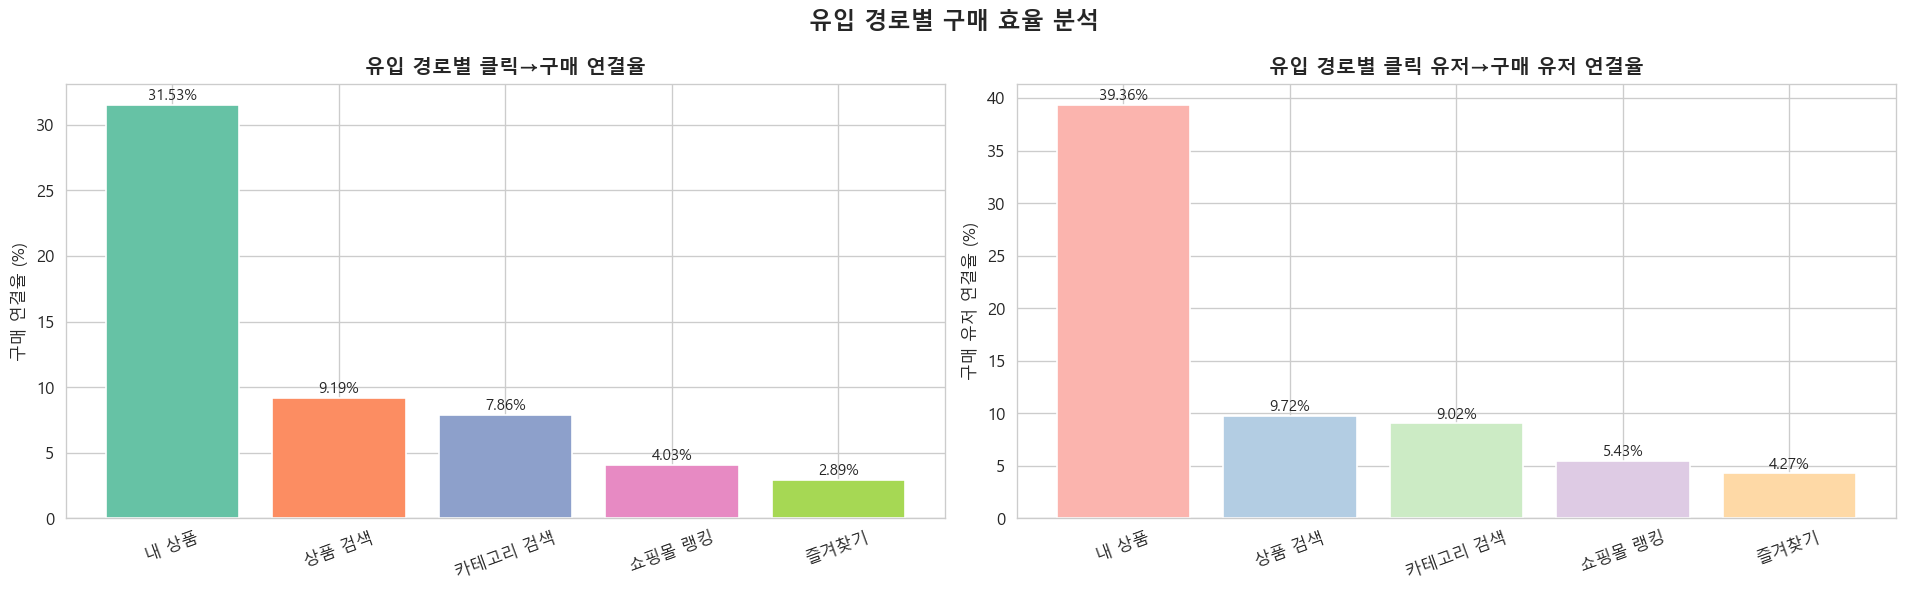

■ 클릭→구매 연결 효율 1위 유입 경로: 내 상품 (31.53%)


In [14]:
# ── 유입 경로별 구매 효율 분석 (탐색적) ──────────────────────
# enter_browser 이벤트 중 동일 유저가 동일 상품을 구매한 경우를 '구매 연결'로 간주
enter_logs = logs[
    (logs['event_name'] == 'enter_browser') &
    (logs['event_goods_id'].notna())
].copy()
enter_logs['event_goods_id'] = enter_logs['event_goods_id'].astype(int)

purchase_pairs = orders[['user_id', 'goods_id']].drop_duplicates().copy()
origin_conv = enter_logs.merge(
    purchase_pairs,
    left_on=['user_id', 'event_goods_id'],
    right_on=['user_id', 'goods_id'],
    how='left'
)
origin_conv['is_purchase_linked'] = origin_conv['goods_id'].notna()

origin_eff = origin_conv.groupby('origin_type').agg(
    클릭수=('user_id', 'count'),
    구매연결수=('is_purchase_linked', 'sum'),
    클릭유저수=('user_id', 'nunique'),
    구매연결유저수=('user_id', lambda x: x[origin_conv.loc[x.index, 'is_purchase_linked']].nunique())
)
origin_eff['클릭대비_구매연결율(%)'] = origin_eff['구매연결수'] / origin_eff['클릭수'] * 100
origin_eff['클릭유저대비_구매연결유저율(%)'] = origin_eff['구매연결유저수'] / origin_eff['클릭유저수'] * 100
origin_eff = origin_eff.sort_values('클릭대비_구매연결율(%)', ascending=False)

display(origin_eff.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('유입 경로별 구매 효율 분석', fontsize=14, fontweight='bold')

ax = axes[0]
bars = ax.bar(origin_eff.index, origin_eff['클릭대비_구매연결율(%)'],
              color=sns.color_palette('Set2', len(origin_eff)), edgecolor='white')
for bar, v in zip(bars, origin_eff['클릭대비_구매연결율(%)']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.08, f'{v:.2f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_title('유입 경로별 클릭→구매 연결율', fontsize=12, fontweight='bold')
ax.set_ylabel('구매 연결율 (%)')
ax.tick_params(axis='x', rotation=20)

ax = axes[1]
bars = ax.bar(origin_eff.index, origin_eff['클릭유저대비_구매연결유저율(%)'],
              color=sns.color_palette('Pastel1', len(origin_eff)), edgecolor='white')
for bar, v in zip(bars, origin_eff['클릭유저대비_구매연결유저율(%)']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.08, f'{v:.2f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_title('유입 경로별 클릭 유저→구매 유저 연결율', fontsize=12, fontweight='bold')
ax.set_ylabel('구매 유저 연결율 (%)')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('output/fig_09_origin_conversion_efficiency.png', bbox_inches='tight')
plt.show()

best_origin = origin_eff.index[0]
print(f'■ 클릭→구매 연결 효율 1위 유입 경로: {best_origin} ({origin_eff.iloc[0]["클릭대비_구매연결율(%)"]:.2f}%)')

## 6. 상품 분석


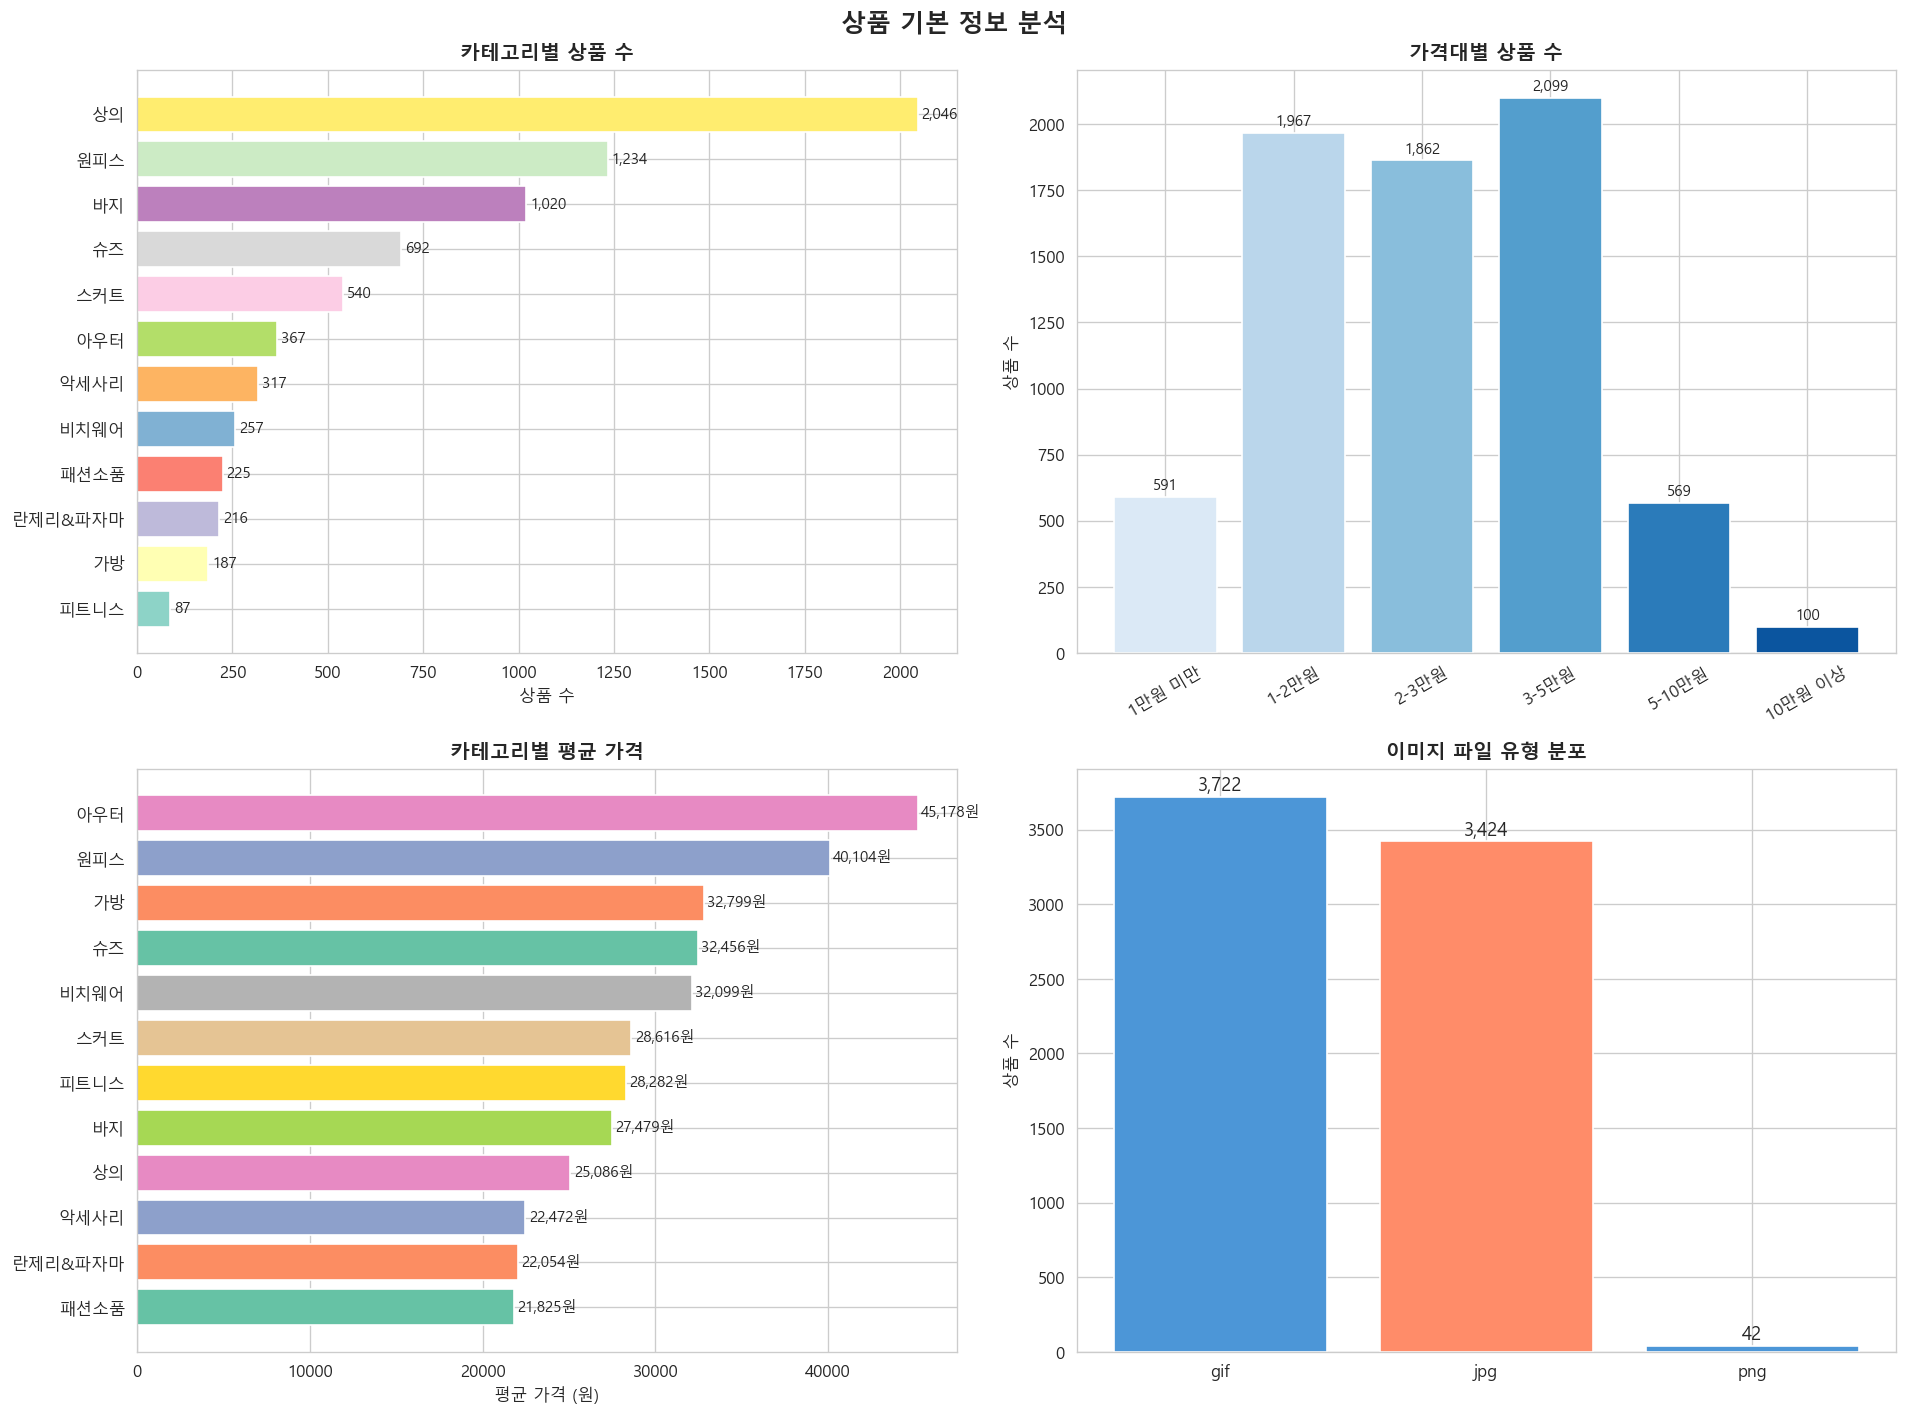

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('상품 기본 정보 분석', fontsize=15, fontweight='bold')

# ── (1) 카테고리별 상품 수 ────────────────────────
ax = axes[0, 0]
cat_cnt = goods['category'].value_counts()
colors_c = sns.color_palette('Set3', len(cat_cnt))
bars = ax.barh(cat_cnt.index[::-1], cat_cnt.values[::-1], color=colors_c)
for bar in bars:
    w = bar.get_width()
    ax.text(w+10, bar.get_y()+bar.get_height()/2, f'{w:,}',
            va='center', fontsize=9)
ax.set_title('카테고리별 상품 수', fontsize=12, fontweight='bold')
ax.set_xlabel('상품 수')

# ── (2) 가격대별 상품 수 ──────────────────────────
ax = axes[0, 1]
price_order = ['1만원 미만','1-2만원','2-3만원','3-5만원','5-10만원','10만원 이상']
price_cnt = goods['price_band'].value_counts().reindex(price_order).fillna(0)
bars = ax.bar(price_cnt.index, price_cnt.values,
              color=sns.color_palette('Blues', len(price_cnt)), edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+10, f'{h:,.0f}',
            ha='center', va='bottom', fontsize=9)
ax.set_title('가격대별 상품 수', fontsize=12, fontweight='bold')
ax.set_ylabel('상품 수')
ax.tick_params(axis='x', rotation=30)

# ── (3) 카테고리별 평균 가격 ──────────────────────
ax = axes[1, 0]
cat_price = goods.groupby('category')['price'].mean().sort_values(ascending=False)
bars = ax.barh(cat_price.index[::-1], cat_price.values[::-1],
               color=sns.color_palette('Set2', len(cat_price)))
for bar in bars:
    w = bar.get_width()
    ax.text(w+200, bar.get_y()+bar.get_height()/2, f'{w:,.0f}원',
            va='center', fontsize=9)
ax.set_title('카테고리별 평균 가격', fontsize=12, fontweight='bold')
ax.set_xlabel('평균 가격 (원)')

# ── (4) 이미지 유형별 분포 ────────────────────────
ax = axes[1, 1]
img_data = {
    '유형': goods['image_type'].value_counts().index.tolist(),
    '형태': goods['img_size_label'].value_counts().index.tolist()[:3]
}
img_type_cnt = goods['image_type'].value_counts()
img_shape_cnt = goods['img_size_label'].value_counts()

x = np.arange(len(img_type_cnt))
bars = ax.bar(img_type_cnt.index, img_type_cnt.values,
              color=['#4C96D7','#FF8C69'], edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+10, f'{h:,}',
            ha='center', va='bottom', fontsize=11)
ax.set_title('이미지 파일 유형 분포', fontsize=12, fontweight='bold')
ax.set_ylabel('상품 수')

plt.tight_layout()
plt.savefig('output/fig_06_goods_basic.png', bbox_inches='tight')
plt.show()

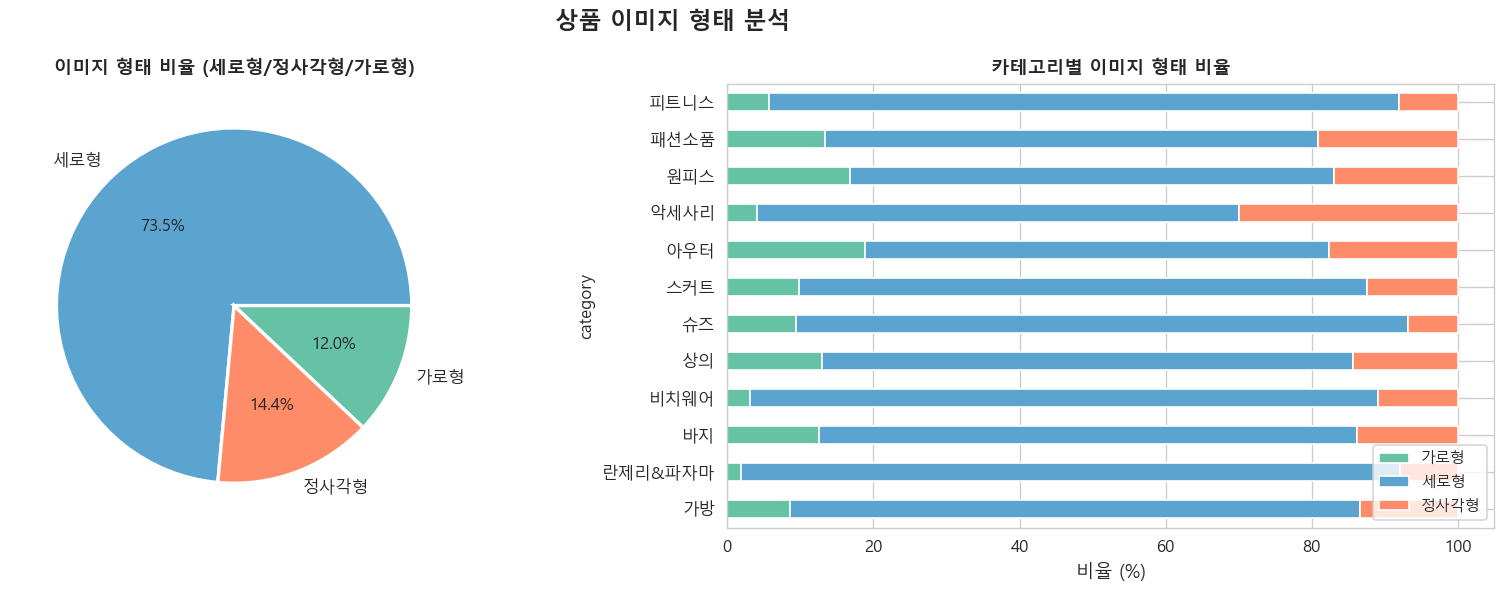

In [16]:
# ── 이미지 형태(비율) 분석 ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('상품 이미지 형태 분석', fontsize=14, fontweight='bold')

ax = axes[0]
shape_cnt = goods['img_size_label'].value_counts()
ax.pie(shape_cnt.values, labels=shape_cnt.index, autopct='%1.1f%%',
       colors=['#5BA4CF','#FF8C69','#66C2A5'],
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('이미지 형태 비율 (세로형/정사각형/가로형)', fontsize=11, fontweight='bold')

ax = axes[1]
# 카테고리별 이미지 형태 비율
cat_shape = goods.groupby(['category','img_size_label']).size().unstack(fill_value=0)
cat_shape_pct = cat_shape.div(cat_shape.sum(axis=1), axis=0) * 100
cat_shape_pct.plot(kind='barh', stacked=True, ax=ax,
                   color=['#66C2A5','#5BA4CF','#FF8C69'], edgecolor='white')
ax.set_xlabel('비율 (%)', fontsize=11)
ax.set_title('카테고리별 이미지 형태 비율', fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('output/fig_07_image_shape.png', bbox_inches='tight')
plt.show()

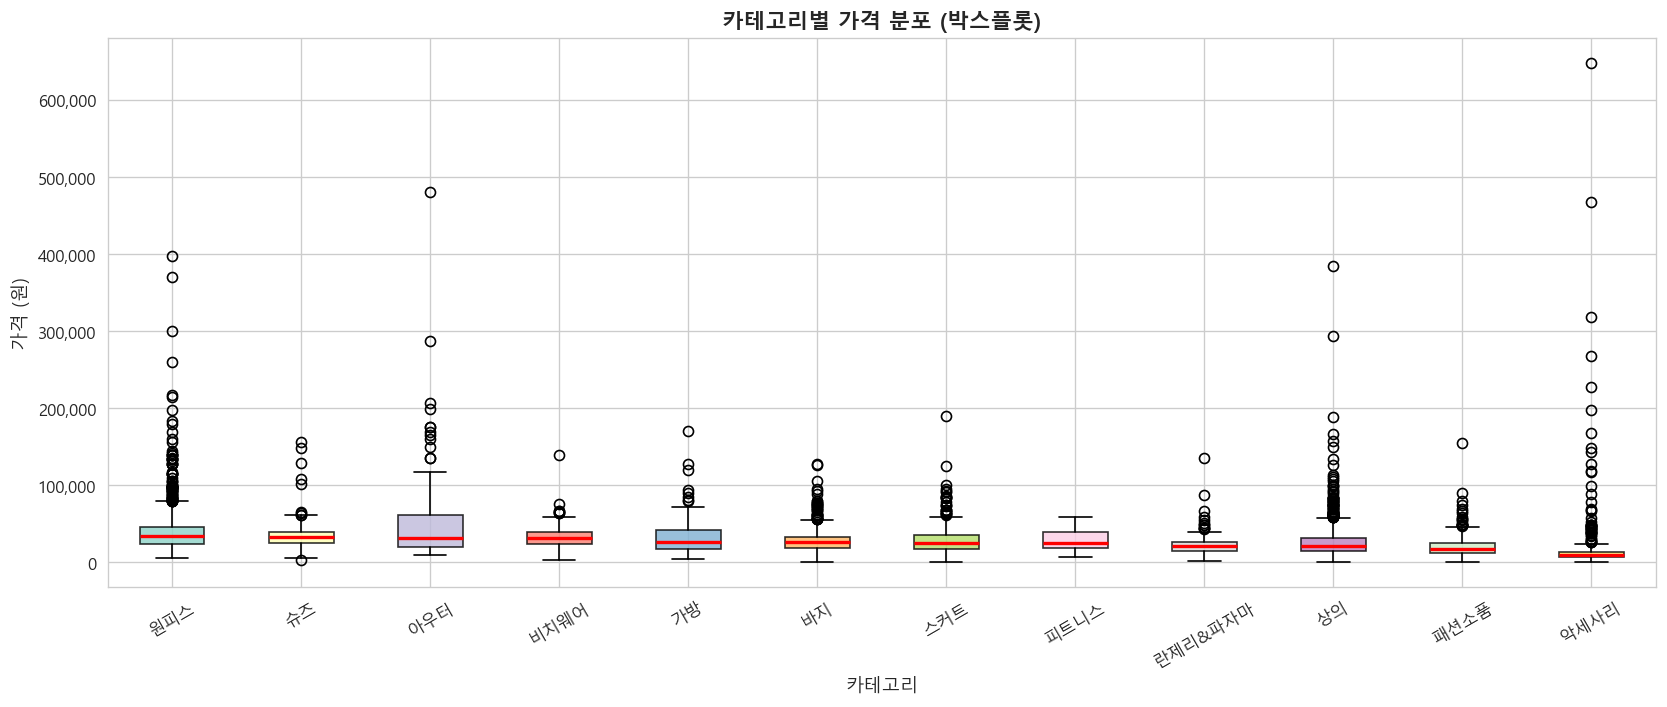

In [17]:
# ── 카테고리별 가격 분포 (박스플롯) ────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

cat_order_by_price = goods.groupby('category')['price'].median().sort_values(ascending=False).index

data_for_box = [goods[goods['category']==c]['price'].values for c in cat_order_by_price]
bp = ax.boxplot(data_for_box, labels=cat_order_by_price, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))

colors_box = sns.color_palette('Set3', len(cat_order_by_price))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xlabel('카테고리', fontsize=11)
ax.set_ylabel('가격 (원)', fontsize=11)
ax.set_title('카테고리별 가격 분포 (박스플롯)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('output/fig_08_price_boxplot.png', bbox_inches='tight')
plt.show()

## 7. 쇼핑몰 분석


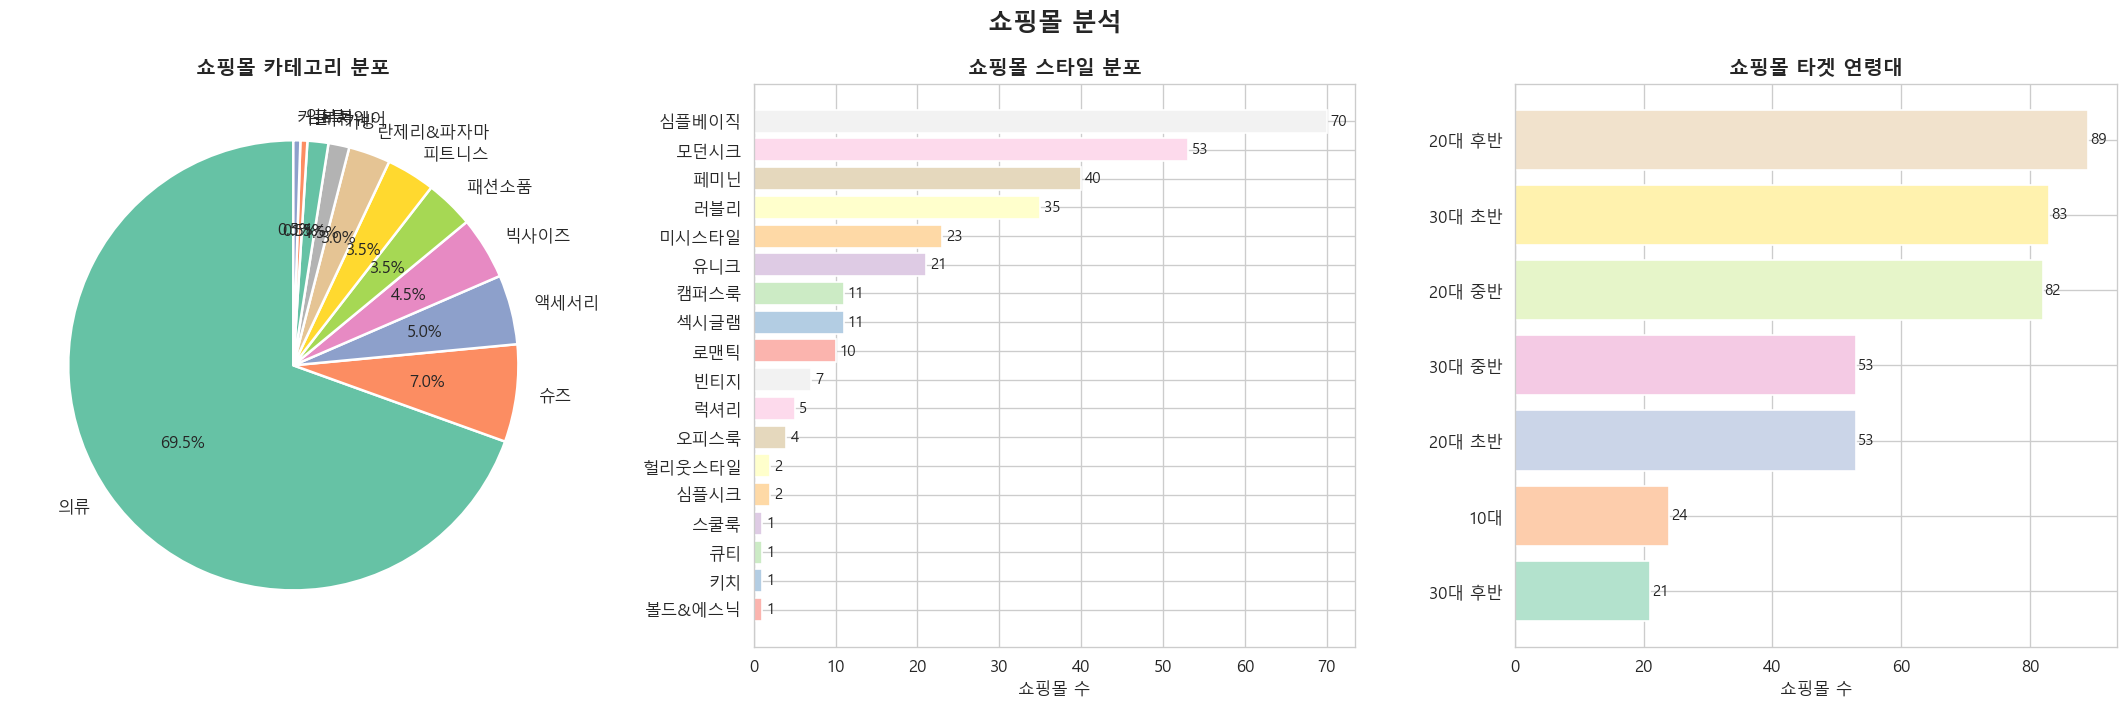

In [18]:
# ── 스타일 분류 (멀티값 처리) ───────────────────────
all_styles = []
for s in shops['style'].dropna():
    all_styles.extend(s.split('/'))
style_series = pd.Series(all_styles)
style_cnt = style_series.value_counts()

# ── 연령 타겟 분류 ──────────────────────────────────
all_ages_shop = []
for a in shops['age'].dropna():
    all_ages_shop.extend(a.split('/'))
age_shop_series = pd.Series(all_ages_shop)
age_shop_cnt = age_shop_series.value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('쇼핑몰 분석', fontsize=15, fontweight='bold')

# (1) 쇼핑몰 카테고리
ax = axes[0]
shop_cat = shops['category'].value_counts()
colors_sc = sns.color_palette('Set2', len(shop_cat))
ax.pie(shop_cat.values, labels=shop_cat.index, autopct='%1.1f%%',
       colors=colors_sc, startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('쇼핑몰 카테고리 분포', fontsize=12, fontweight='bold')

# (2) 스타일 분포
ax = axes[1]
bars = ax.barh(style_cnt.index[::-1], style_cnt.values[::-1],
               color=sns.color_palette('Pastel1', len(style_cnt)))
for bar in bars:
    w = bar.get_width()
    ax.text(w+0.5, bar.get_y()+bar.get_height()/2, f'{w:,}',
            va='center', fontsize=9)
ax.set_title('쇼핑몰 스타일 분포', fontsize=12, fontweight='bold')
ax.set_xlabel('쇼핑몰 수')

# (3) 타겟 연령대 분포
ax = axes[2]
bars = ax.barh(age_shop_cnt.index[::-1], age_shop_cnt.values[::-1],
               color=sns.color_palette('Pastel2', len(age_shop_cnt)))
for bar in bars:
    w = bar.get_width()
    ax.text(w+0.3, bar.get_y()+bar.get_height()/2, f'{w:,}',
            va='center', fontsize=9)
ax.set_title('쇼핑몰 타겟 연령대', fontsize=12, fontweight='bold')
ax.set_xlabel('쇼핑몰 수')

plt.tight_layout()
plt.savefig('output/fig_09_shop_analysis.png', bbox_inches='tight')
plt.show()

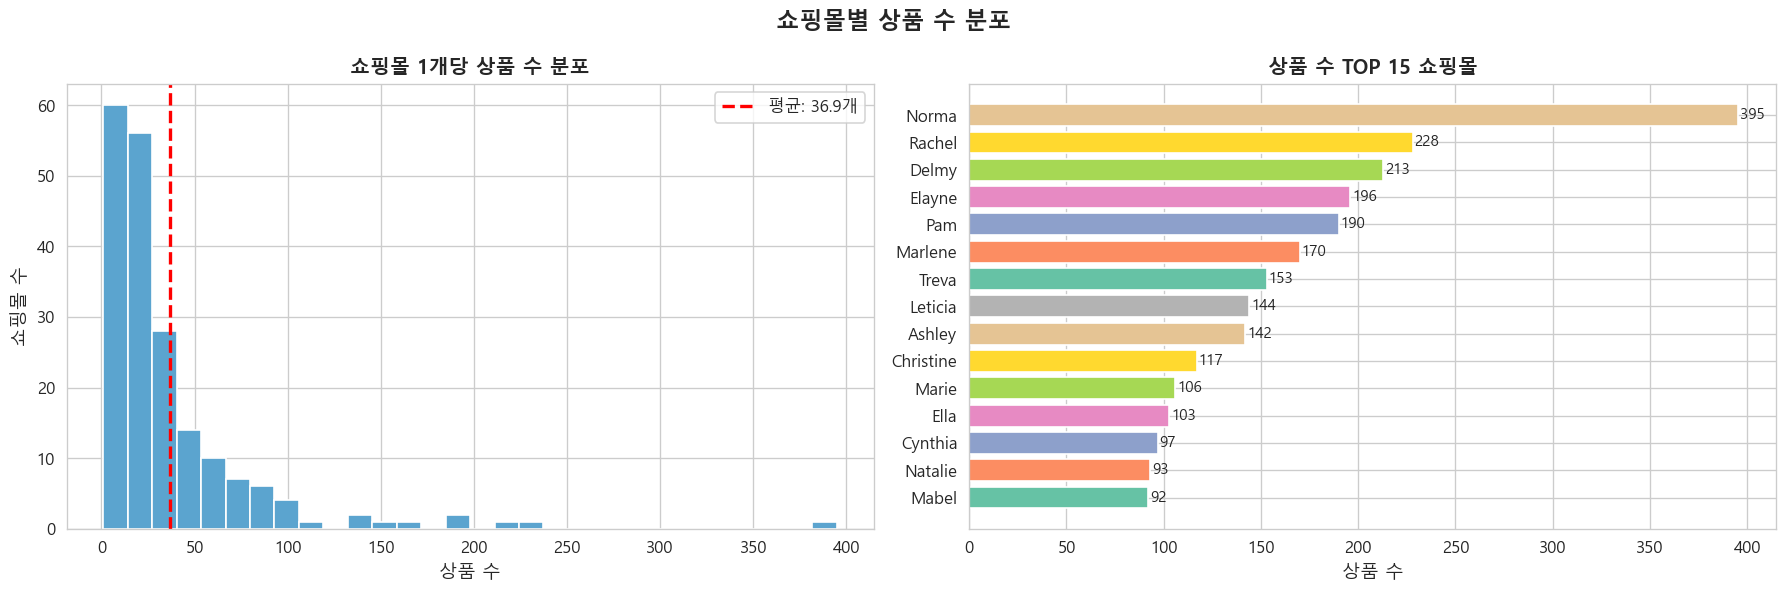

In [19]:
# ── 쇼핑몰별 상품 수 분포 ──────────────────────────
shop_goods_cnt = goods['shop_id'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('쇼핑몰별 상품 수 분포', fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(shop_goods_cnt, bins=30, color='#5BA4CF', edgecolor='white')
ax.axvline(shop_goods_cnt.mean(), color='red', linestyle='--', linewidth=2,
           label=f'평균: {shop_goods_cnt.mean():.1f}개')
ax.set_xlabel('상품 수', fontsize=11)
ax.set_ylabel('쇼핑몰 수', fontsize=11)
ax.set_title('쇼핑몰 1개당 상품 수 분포', fontsize=12, fontweight='bold')
ax.legend()

ax = axes[1]
top_shops = shop_goods_cnt.head(15)
top_shops_name = shops.set_index('shop_id').loc[top_shops.index]['name']
bars = ax.barh(top_shops_name.values[::-1], top_shops.values[::-1],
               color=sns.color_palette('Set2', 15))
for bar in bars:
    w = bar.get_width()
    ax.text(w+1, bar.get_y()+bar.get_height()/2, f'{w:,}',
            va='center', fontsize=9)
ax.set_xlabel('상품 수', fontsize=11)
ax.set_title('상품 수 TOP 15 쇼핑몰', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('output/fig_10_shop_goods.png', bbox_inches='tight')
plt.show()

### 7-4. 쇼핑몰 효율 지표 분석
절대 이벤트 수·구매 수만 보면 상품 수가 많은 쇼핑몰이 유리할 수 있습니다.  
따라서 상품 수 보정 지표를 함께 계산해 숨은 고효율 쇼핑몰을 확인합니다.

,name,category,상품수,이벤트수,구매수,이벤트/상품,구매/상품,구매전환율(구매/이벤트)
123,Edie,란제리&파자마,62.0,176,39.0,2.839,0.629,0.222
122,Arleen,의류,17.0,55,6.0,3.235,0.353,0.109
110,Amparo,슈즈,18.0,47,5.0,2.611,0.278,0.106
99,Patsy,액세서리,50.0,162,17.0,3.240,0.340,0.105
133,Frances,의류,25.0,59,6.0,2.360,0.240,0.102
81,Jasmine,의류,38.0,120,11.0,3.158,0.289,0.092
93,Kimberley,슈즈,29.0,77,7.0,2.655,0.241,0.091
157,Keisha,의류,24.0,56,5.0,2.333,0.208,0.089
179,Tonya,의류,40.0,172,14.0,4.300,0.350,0.081
88,Sonia,액세서리,70.0,211,17.0,3.014,0.243,0.081


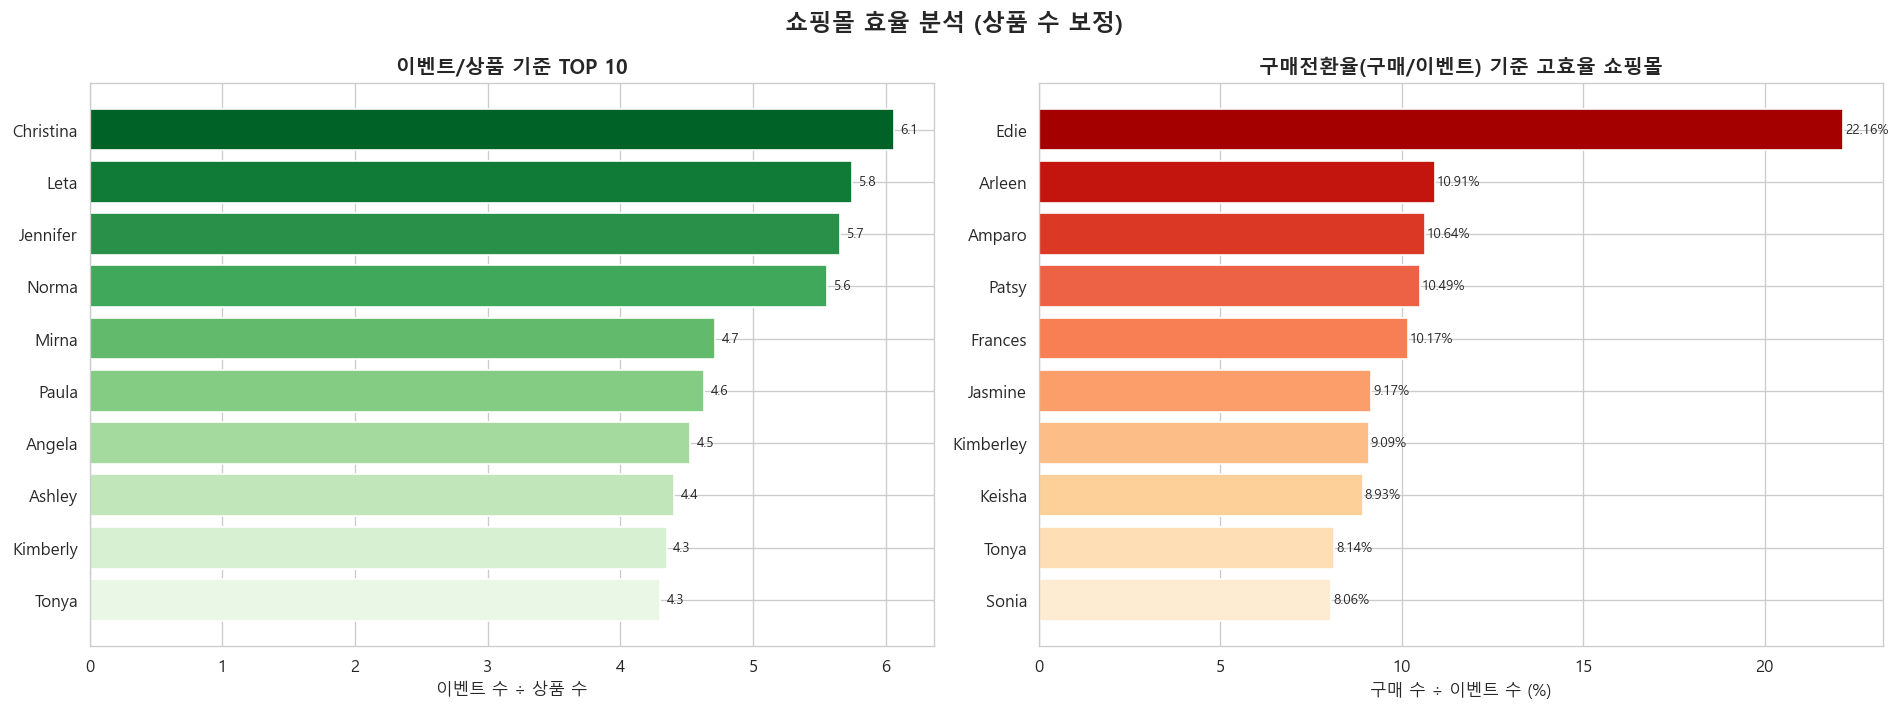

In [20]:
# ── 쇼핑몰 효율 지표 분석 (상품 수 보정) ──────────────────────
shop_goods_cnt = goods.groupby('shop_id').size().rename('상품수')
shop_event_cnt_named = logs[logs['event_shop_id'].notna()]['event_shop_id'].astype(int).value_counts().rename('이벤트수')
shop_buy_cnt = orders['shop_id'].value_counts().rename('구매수')

shop_efficiency = pd.concat([shop_goods_cnt, shop_event_cnt_named, shop_buy_cnt], axis=1).fillna(0)
shop_efficiency.index.name = 'shop_id'
shop_efficiency = shop_efficiency.reset_index()
shop_efficiency = shop_efficiency.merge(
    shops[['shop_id', 'name', 'category']],
    on='shop_id',
    how='left'
)

shop_efficiency['이벤트/상품'] = shop_efficiency['이벤트수'] / shop_efficiency['상품수'].replace(0, np.nan)
shop_efficiency['구매/상품'] = shop_efficiency['구매수'] / shop_efficiency['상품수'].replace(0, np.nan)
shop_efficiency['구매전환율(구매/이벤트)'] = shop_efficiency['구매수'] / shop_efficiency['이벤트수'].replace(0, np.nan)
shop_efficiency = shop_efficiency.fillna(0)

eff_filtered = shop_efficiency[shop_efficiency['이벤트수'] >= shop_efficiency['이벤트수'].median()].copy()
top_hidden = eff_filtered.sort_values('구매전환율(구매/이벤트)', ascending=False).head(10)

display(
    top_hidden[['name', 'category', '상품수', '이벤트수', '구매수', '이벤트/상품', '구매/상품', '구매전환율(구매/이벤트)']]
    .round(3)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('쇼핑몰 효율 분석 (상품 수 보정)', fontsize=14, fontweight='bold')

ax = axes[0]
top_eps = shop_efficiency.sort_values('이벤트/상품', ascending=False).head(10)
bars = ax.barh(top_eps['name'][::-1], top_eps['이벤트/상품'][::-1],
               color=sns.color_palette('Greens', 10), edgecolor='white')
for bar, v in zip(bars, top_eps['이벤트/상품'][::-1]):
    ax.text(v + 0.05, bar.get_y() + bar.get_height()/2, f'{v:.1f}',
            va='center', fontsize=8)
ax.set_title('이벤트/상품 기준 TOP 10', fontsize=12, fontweight='bold')
ax.set_xlabel('이벤트 수 ÷ 상품 수')

ax = axes[1]
top_cvr = top_hidden.sort_values('구매전환율(구매/이벤트)', ascending=True)
bars = ax.barh(top_cvr['name'], top_cvr['구매전환율(구매/이벤트)'] * 100,
               color=sns.color_palette('OrRd', len(top_cvr)), edgecolor='white')
for bar, v in zip(bars, top_cvr['구매전환율(구매/이벤트)'] * 100):
    ax.text(v + 0.05, bar.get_y() + bar.get_height()/2, f'{v:.2f}%',
            va='center', fontsize=8)
ax.set_title('구매전환율(구매/이벤트) 기준 고효율 쇼핑몰', fontsize=12, fontweight='bold')
ax.set_xlabel('구매 수 ÷ 이벤트 수 (%)')

plt.tight_layout()
plt.savefig('output/fig_18_shop_efficiency.png', bbox_inches='tight')
plt.show()

## 8. 전환율 분석 – 유저 단위 퍼널

이벤트 건수 기준이 아닌 유저 단위의 퍼널 전환율도 계산합니다.
동일 유저가 여러 번 클릭해도 중복 집계되지 않아 더 정확한 전환율을 파악할 수 있습니다.


■ 이벤트 단위 퍼널 (기존)
  페이지 조회: 84,171건  →  클릭: 17,419건  (20.7%)  →  구매: 867건 (5.0%)

■ 유저 단위 퍼널
  조회 유저: 9,908명  →  클릭 유저: 4,426명  (44.7%)  →  구매 유저: 832명 (18.8%)



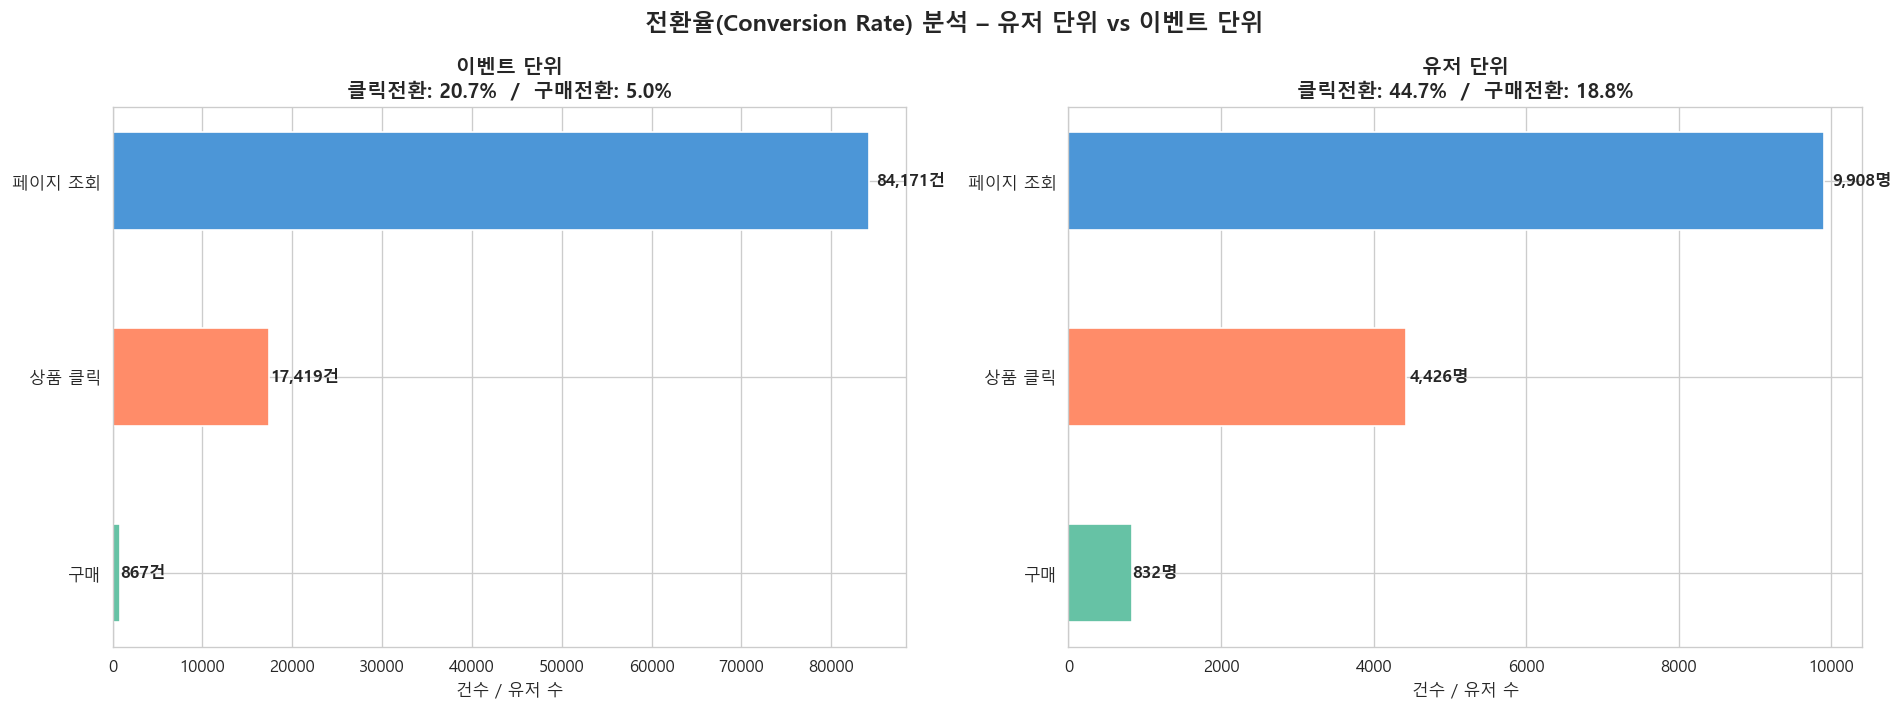

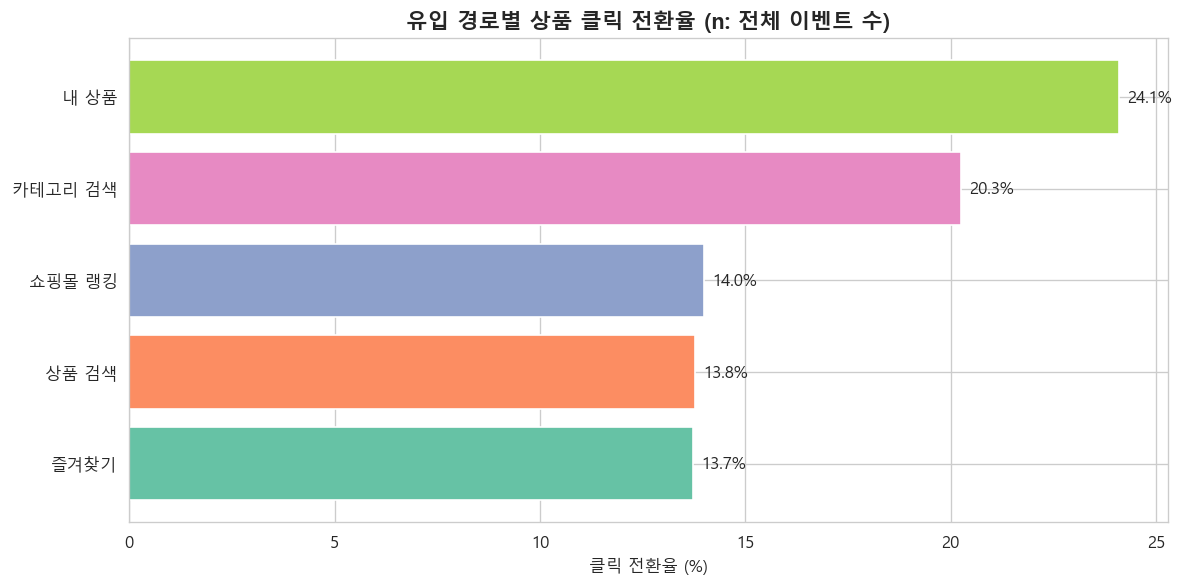

In [21]:
# ── 유저 단위 퍼널 분석 ────────────────────────────────────
# 이벤트 건수 기준 (기존)
total_page_view      = (logs['event_name'] == 'app_page_view').sum()
total_enter_browser  = (logs['event_name'] == 'enter_browser').sum()
total_orders         = len(orders)

# 유저 단위
users_viewed  = logs[logs['event_name'] == 'app_page_view']['user_id'].nunique()
users_clicked = logs[logs['event_name'] == 'enter_browser']['user_id'].nunique()
users_bought  = orders['user_id'].nunique()

cr1_event = total_enter_browser / total_page_view * 100
cr2_event = total_orders / total_enter_browser * 100
cr1_user  = users_clicked / users_viewed  * 100
cr2_user  = users_bought  / users_clicked * 100

print('■ 이벤트 단위 퍼널 (기존)')
print(f'  페이지 조회: {total_page_view:,}건  →  클릭: {total_enter_browser:,}건  ({cr1_event:.1f}%)  →  구매: {total_orders:,}건 ({cr2_event:.1f}%)')
print()
print('■ 유저 단위 퍼널')
print(f'  조회 유저: {users_viewed:,}명  →  클릭 유저: {users_clicked:,}명  ({cr1_user:.1f}%)  →  구매 유저: {users_bought:,}명 ({cr2_user:.1f}%)')
print()

# ── 시각화: 이벤트 단위 vs 유저 단위 퍼널 비교 ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('전환율(Conversion Rate) 분석 – 유저 단위 vs 이벤트 단위', fontsize=14, fontweight='bold')

funnel_data = [
    ('이벤트 단위', [total_page_view, total_enter_browser, total_orders]),
    ('유저 단위',   [users_viewed,    users_clicked,        users_bought]),
]
labels = ['페이지 조회', '상품 클릭', '구매']
colors_funnel = ['#4C96D7', '#FF8C69', '#66C2A5']

for ax, (title, vals) in zip(axes, funnel_data):
    bars = ax.barh(labels[::-1], vals[::-1], color=colors_funnel[::-1], height=0.5)
    for bar, v in zip(bars, vals[::-1]):
        unit = '건' if title == '이벤트 단위' else '명'
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{v:,}{unit}', va='center', fontsize=10, fontweight='bold')
    cr_a = vals[1] / vals[0] * 100
    cr_b = vals[2] / vals[1] * 100
    ax.set_title(f'{title}\n클릭전환: {cr_a:.1f}%  /  구매전환: {cr_b:.1f}%', fontsize=12, fontweight='bold')
    ax.set_xlabel('건수 / 유저 수')

plt.tight_layout()
plt.savefig('output/fig_11_conversion.png', bbox_inches='tight')
plt.show()

# ── 유입 경로별 클릭 전환율 ─────────────────────────────────
origin_enter = logs[logs['event_name']=='enter_browser']['origin_type'].value_counts()
origin_total = logs['origin_type'].value_counts()
origin_cr_df = pd.DataFrame({'total': origin_total, 'enter': origin_enter}).fillna(0)
origin_cr_df['cr'] = origin_cr_df['enter'] / origin_cr_df['total'] * 100
origin_cr_df = origin_cr_df.sort_values('cr', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(origin_cr_df.index[::-1], origin_cr_df['cr'][::-1],
               color=sns.color_palette('Set2', len(origin_cr_df)))
for bar in bars:
    w = bar.get_width()
    n = origin_cr_df.loc[origin_cr_df['cr'] == w, 'total'].values
    ax.text(w + 0.2, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}%', va='center', fontsize=10)
ax.set_title('유입 경로별 상품 클릭 전환율 (n: 전체 이벤트 수)', fontsize=13, fontweight='bold')
ax.set_xlabel('클릭 전환율 (%)')
plt.tight_layout()
plt.savefig('output/fig_11b_origin_cr.png', bbox_inches='tight')
plt.show()


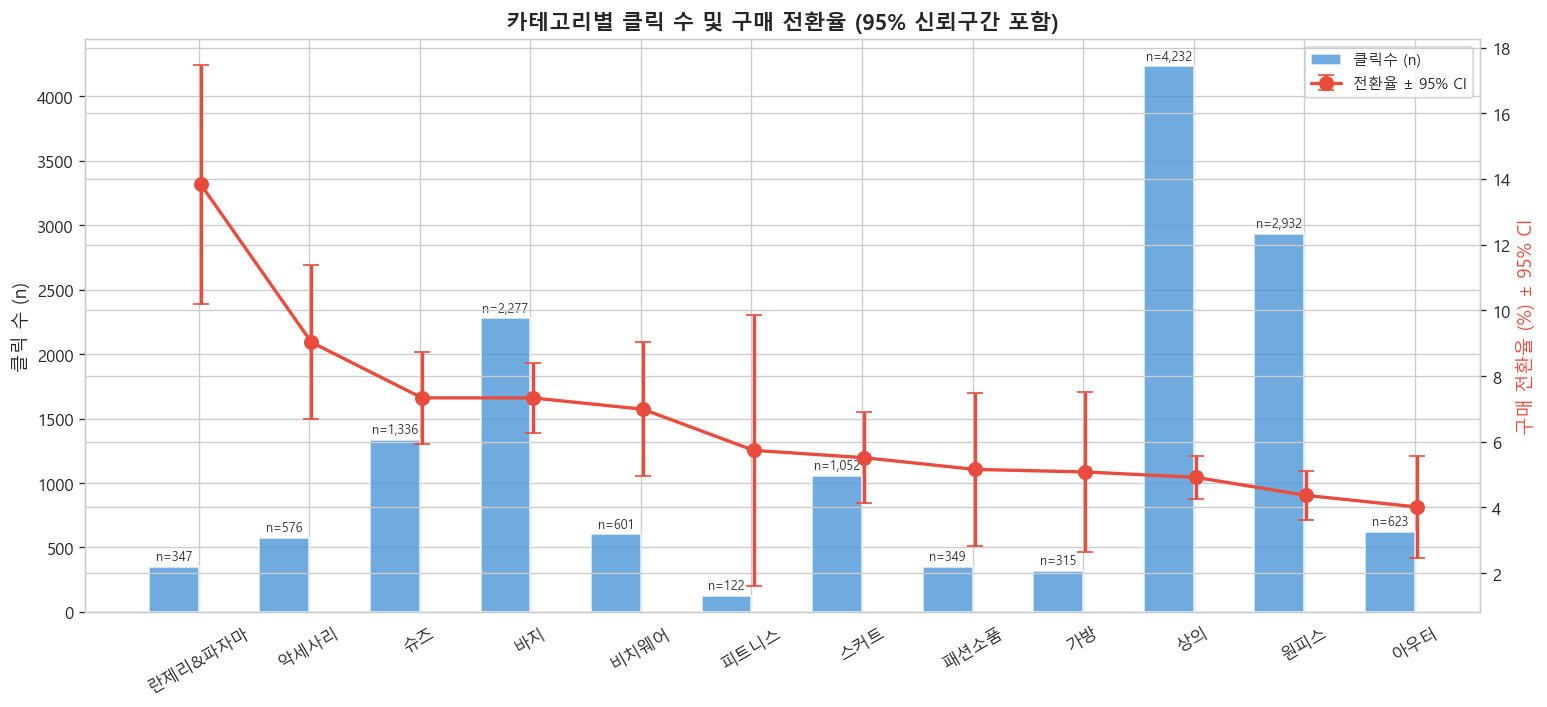


■ 카테고리별 전환율 (95% 신뢰구간 포함)
           클릭수  구매수    전환율  ci_low  ci_high
category                                   
란제리&파자마    347   48  13.83   10.20    17.47
악세사리       576   52   9.03    6.69    11.37
슈즈        1336   98   7.34    5.94     8.73
바지        2277  167   7.33    6.26     8.41
비치웨어       601   42   6.99    4.95     9.03
피트니스       122    7   5.74    1.61     9.86
스커트       1052   58   5.51    4.13     6.89
패션소품       349   18   5.16    2.84     7.48
가방         315   16   5.08    2.65     7.50
상의        4232  208   4.91    4.26     5.57
원피스       2932  128   4.37    3.63     5.11
아우터        623   25   4.01    2.47     5.55


In [22]:
# ── 카테고리별 전환율 분석 (신뢰구간 포함) ──────────────────────
from scipy import stats as scipy_stats
import numpy as np

enter_with_goods = logs[(logs['event_name']=='enter_browser') & (logs['event_goods_id'].notna())].copy()
enter_with_goods['event_goods_id'] = enter_with_goods['event_goods_id'].astype(int)
enter_goods_merge = enter_with_goods.merge(goods[['goods_id','category']],
                                            left_on='event_goods_id', right_on='goods_id', how='left')
enter_cat  = enter_goods_merge.groupby('category')['event_goods_id'].count()
order_cat  = orders_g.groupby('category').size()

cat_conv = pd.DataFrame({'클릭수': enter_cat, '구매수': order_cat}).fillna(0)
cat_conv['전환율'] = cat_conv['구매수'] / cat_conv['클릭수'] * 100

# 이항비율 95% 신뢰구간 계산
def binom_ci(success, total, z=1.96):
    if total == 0: return 0, 0
    p = success / total
    margin = z * np.sqrt(p * (1 - p) / total)
    return max(0, (p - margin) * 100), min(100, (p + margin) * 100)

cat_conv[['ci_low','ci_high']] = cat_conv.apply(
    lambda r: pd.Series(binom_ci(r['구매수'], r['클릭수'])), axis=1)
cat_conv['ci_err'] = (cat_conv['ci_high'] - cat_conv['ci_low']) / 2
cat_conv = cat_conv.sort_values('전환율', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(cat_conv))
width = 0.45

bars1 = ax.bar(x - width/2, cat_conv['클릭수'], width, label='클릭수 (n)',
               color='#4C96D7', alpha=0.8)
# n 수 표시
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            f'n={int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7.5, color='#333')

ax2 = ax.twinx()
ax2.errorbar(x + width/2 - width/2 + 0.02, cat_conv['전환율'],
             yerr=cat_conv['ci_err'], fmt='o-', color='#E94B3C',
             linewidth=2, markersize=8, capsize=5, label='전환율 ± 95% CI')

ax.set_xticks(x)
ax.set_xticklabels(cat_conv.index, rotation=30, fontsize=10)
ax.set_ylabel('클릭 수 (n)', fontsize=11)
ax2.set_ylabel('구매 전환율 (%) ± 95% CI', fontsize=11, color='#E94B3C')
ax.set_title('카테고리별 클릭 수 및 구매 전환율 (95% 신뢰구간 포함)', fontsize=13, fontweight='bold')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('output/fig_12_cat_conversion.png', bbox_inches='tight')
plt.show()

print('\n■ 카테고리별 전환율 (95% 신뢰구간 포함)')
print(cat_conv[['클릭수','구매수','전환율','ci_low','ci_high']].round(2).to_string())

## 9. 연령대별 행동 패턴


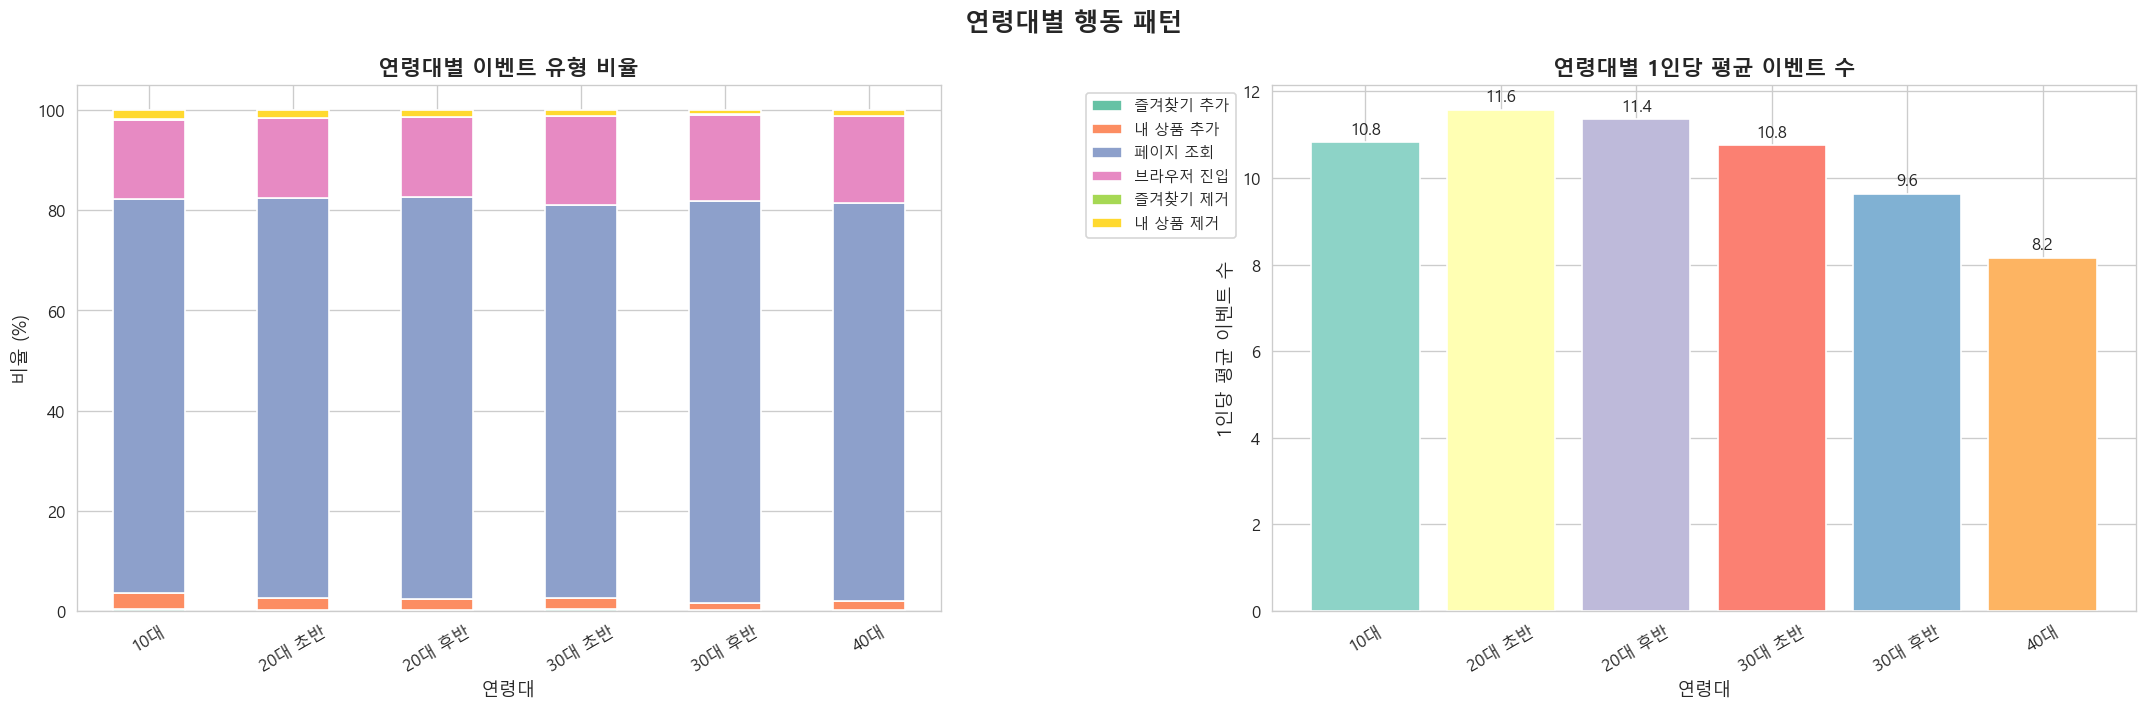

In [23]:
# ── 연령대별 이벤트 수 및 종류 ──────────────────────
age_order = ['10대', '20대 초반', '20대 후반', '30대 초반', '30대 후반', '40대']
logs_u_valid = logs_u[logs_u['age'] >= 0]

age_event = logs_u_valid.groupby(['age_group','event_name']).size().unstack(fill_value=0)
age_event = age_event.reindex(age_order)

event_korean = {
    'app_page_view':    '페이지 조회',
    'enter_browser':    '브라우저 진입',
    'add_my_goods':     '내 상품 추가',
    'remove_my_goods':  '내 상품 제거',
    'add_bookmark':     '즐겨찾기 추가',
    'remove_bookmark':  '즐겨찾기 제거',
}
age_event.columns = [event_korean.get(c, c) for c in age_event.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('연령대별 행동 패턴', fontsize=15, fontweight='bold')

# 스택 바 차트
ax = axes[0]
age_event_pct = age_event.div(age_event.sum(axis=1), axis=0) * 100
age_event_pct.plot(kind='bar', stacked=True, ax=ax,
                   color=sns.color_palette('Set2', len(age_event_pct.columns)),
                   edgecolor='white')
ax.set_xlabel('연령대', fontsize=11)
ax.set_ylabel('비율 (%)', fontsize=11)
ax.set_title('연령대별 이벤트 유형 비율', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='upper right', fontsize=9, bbox_to_anchor=(1.35, 1))

# 연령대별 1인당 평균 이벤트 수
ax = axes[1]
user_count_by_age = users[users['age']>=0]['age_group'].value_counts()
event_count_by_age = logs_u_valid.groupby('age_group').size()
avg_events_by_age = (event_count_by_age / user_count_by_age).reindex(age_order).fillna(0)

bars = ax.bar(avg_events_by_age.index, avg_events_by_age.values,
              color=sns.color_palette('Set3', len(age_order)), edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.1, f'{h:.1f}',
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel('연령대', fontsize=11)
ax.set_ylabel('1인당 평균 이벤트 수', fontsize=11)
ax.set_title('연령대별 1인당 평균 이벤트 수', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('output/fig_13_age_behavior.png', bbox_inches='tight')
plt.show()

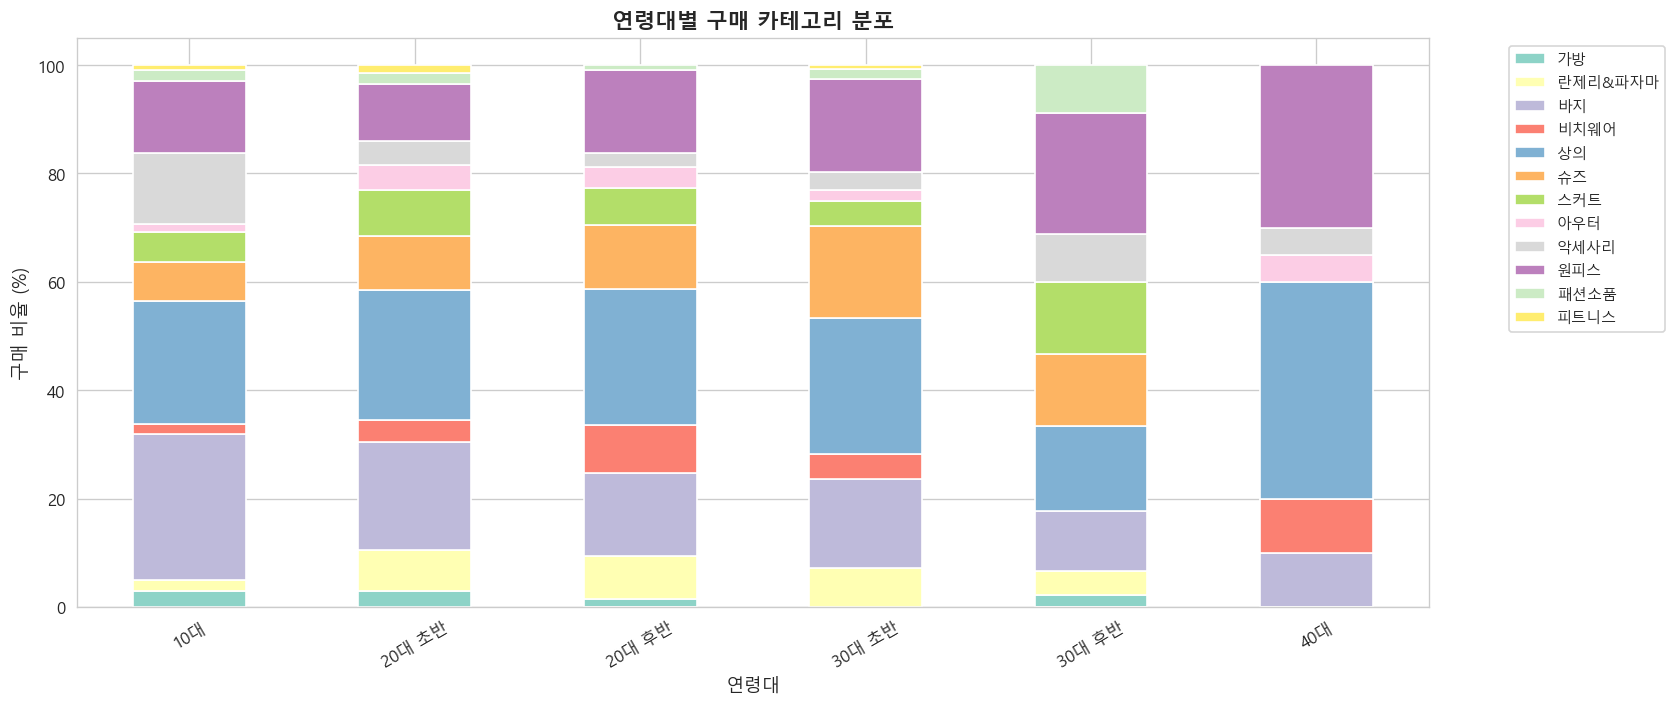


■ 연령대별 구매 수 (절대값)
category   가방  란제리&파자마  바지  비치웨어  상의  슈즈  스커트  아우터  악세사리  원피스  패션소품  피트니스
age_group                                                                
10대         6        4  55     4  46  15   11    3    27   27     4     2
20대 초반      6       15  40     8  48  20   17    9     9   21     4     3
20대 후반      3       16  31    18  51  24   14    8     5   31     2     0
30대 초반      0       11  25     7  38  26    7    3     5   26     3     1
30대 후반      1        2   5     0   7   6    6    0     4   10     4     0
40대         0        0   2     2   8   0    0    1     1    6     0     0


In [24]:
# ── 연령대별 구매 카테고리 분포 ──────────────────────
orders_u_valid = orders_g[orders_g['age'] >= 0]
age_cat_order = orders_u_valid.groupby(['age_group','category']).size().unstack(fill_value=0)
age_cat_order = age_cat_order.reindex(age_order).fillna(0)

# 비율로 변환
age_cat_pct = age_cat_order.div(age_cat_order.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
age_cat_pct.plot(kind='bar', stacked=True, ax=ax,
                 color=sns.color_palette('Set3', len(age_cat_pct.columns)),
                 edgecolor='white')
ax.set_xlabel('연령대', fontsize=11)
ax.set_ylabel('구매 비율 (%)', fontsize=11)
ax.set_title('연령대별 구매 카테고리 분포', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1), fontsize=9)

plt.tight_layout()
plt.savefig('output/fig_14_age_category.png', bbox_inches='tight')
plt.show()

print('\n■ 연령대별 구매 수 (절대값)')
print(age_cat_order.to_string())

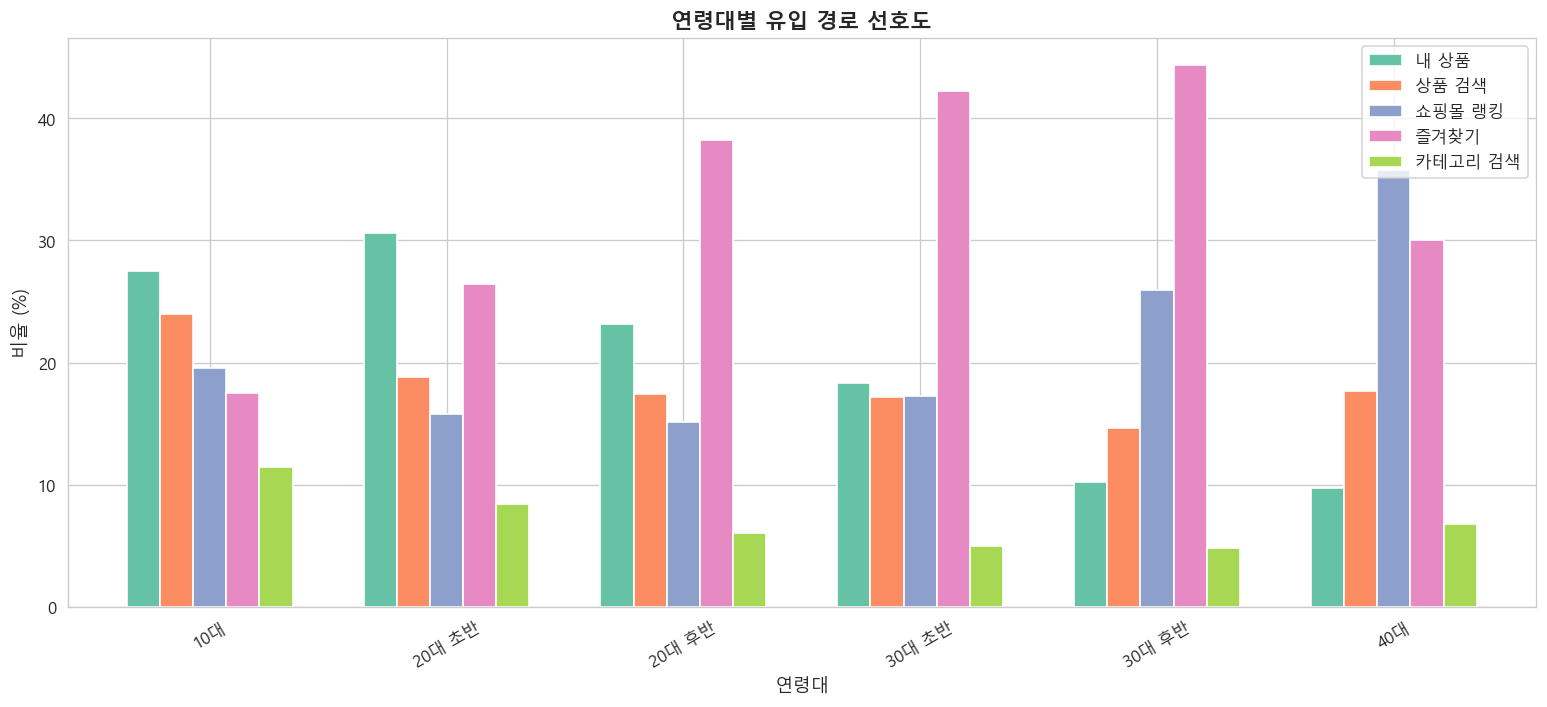

In [25]:
# ── 연령대별 유입 경로 선호도 ──────────────────────
age_origin = logs_u_valid.groupby(['age_group','origin_type']).size().unstack(fill_value=0)
age_origin = age_origin.reindex(age_order).fillna(0)
age_origin_pct = age_origin.div(age_origin.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
age_origin_pct.plot(kind='bar', stacked=False, ax=ax,
                    color=sns.color_palette('Set2', 5), edgecolor='white', width=0.7)
ax.set_xlabel('연령대', fontsize=11)
ax.set_ylabel('비율 (%)', fontsize=11)
ax.set_title('연령대별 유입 경로 선호도', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('output/fig_15_age_origin.png', bbox_inches='tight')
plt.show()

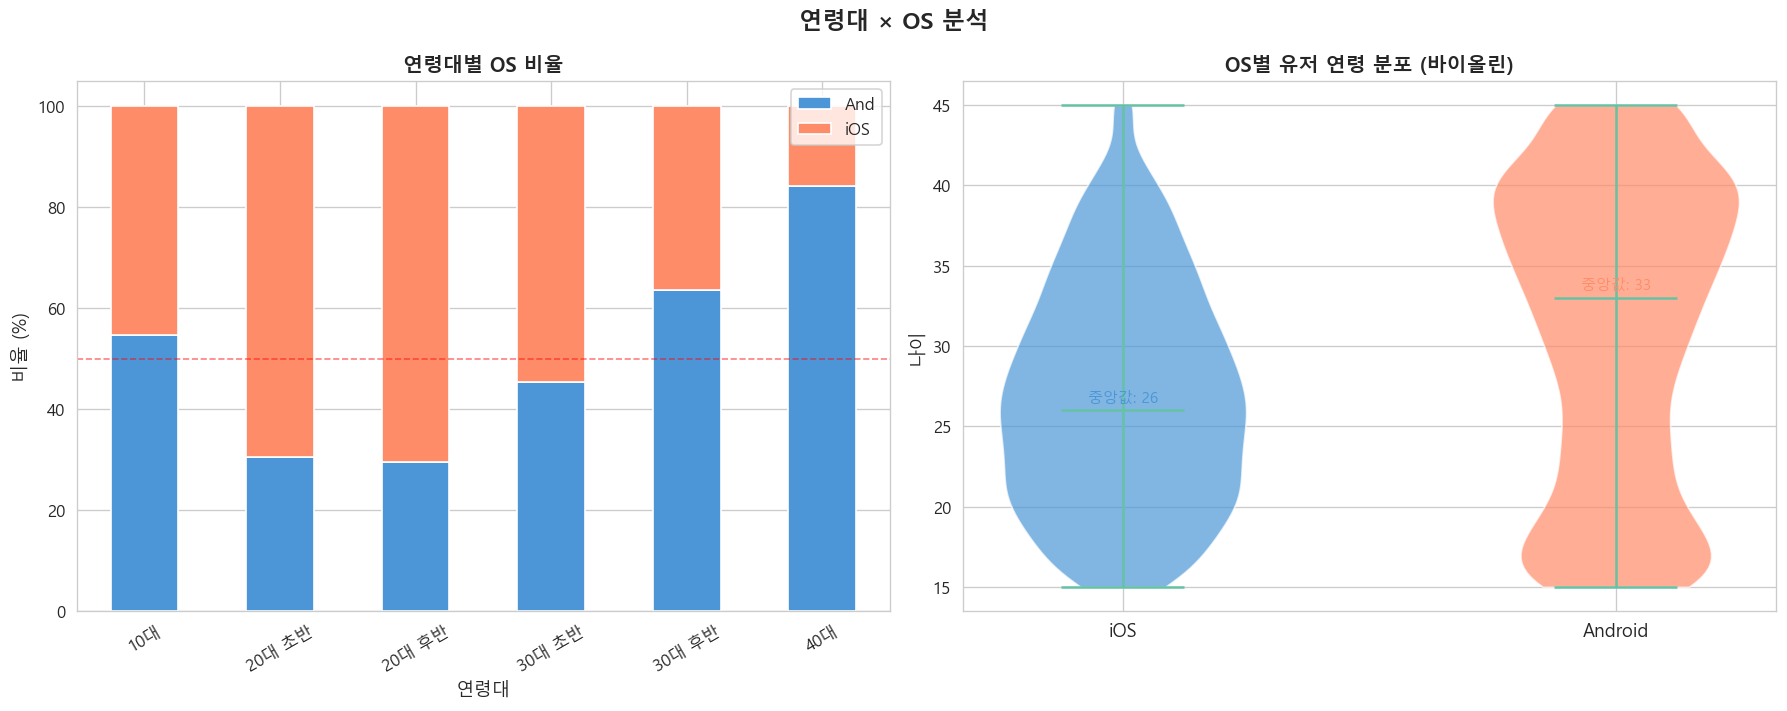

In [26]:
# ── 연령대별 OS 분포 ────────────────────────────────
age_os = users[users['age']>=0].groupby(['age_group','os']).size().unstack(fill_value=0)
age_os = age_os.reindex(age_order)
age_os_pct = age_os.div(age_os.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('연령대 × OS 분석', fontsize=14, fontweight='bold')

ax = axes[0]
age_os_pct.plot(kind='bar', stacked=True, ax=ax,
                color=['#4C96D7','#FF8C69'], edgecolor='white')
ax.set_xlabel('연령대', fontsize=11)
ax.set_ylabel('비율 (%)', fontsize=11)
ax.set_title('연령대별 OS 비율', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend(['And','iOS'], fontsize=10)
ax.axhline(50, color='red', linestyle='--', linewidth=1, alpha=0.5)

ax = axes[1]
# OS별 연령 분포 바이올린 플롯
users_valid = users[users['age']>=0]
ios_ages = users_valid[users_valid['os']=='iOS']['age']
and_ages = users_valid[users_valid['os']=='And']['age']
data_violin = [ios_ages.values, and_ages.values]
vp = ax.violinplot(data_violin, positions=[1, 2], showmedians=True,
                   showextrema=True)
for pc in vp['bodies']:
    pc.set_alpha(0.7)
vp['bodies'][0].set_facecolor('#4C96D7')
vp['bodies'][1].set_facecolor('#FF8C69')
ax.set_xticks([1, 2])
ax.set_xticklabels(['iOS', 'Android'], fontsize=11)
ax.set_ylabel('나이', fontsize=11)
ax.set_title('OS별 유저 연령 분포 (바이올린)', fontsize=12, fontweight='bold')
ax.text(1, ios_ages.median()+0.5, f'중앙값: {ios_ages.median():.0f}',
        ha='center', fontsize=9, color='#4C96D7')
ax.text(2, and_ages.median()+0.5, f'중앙값: {and_ages.median():.0f}',
        ha='center', fontsize=9, color='#FF8C69')

plt.tight_layout()
plt.savefig('output/fig_16_age_os.png', bbox_inches='tight')
plt.show()

## 10. 인기 상품 및 쇼핑몰 분석


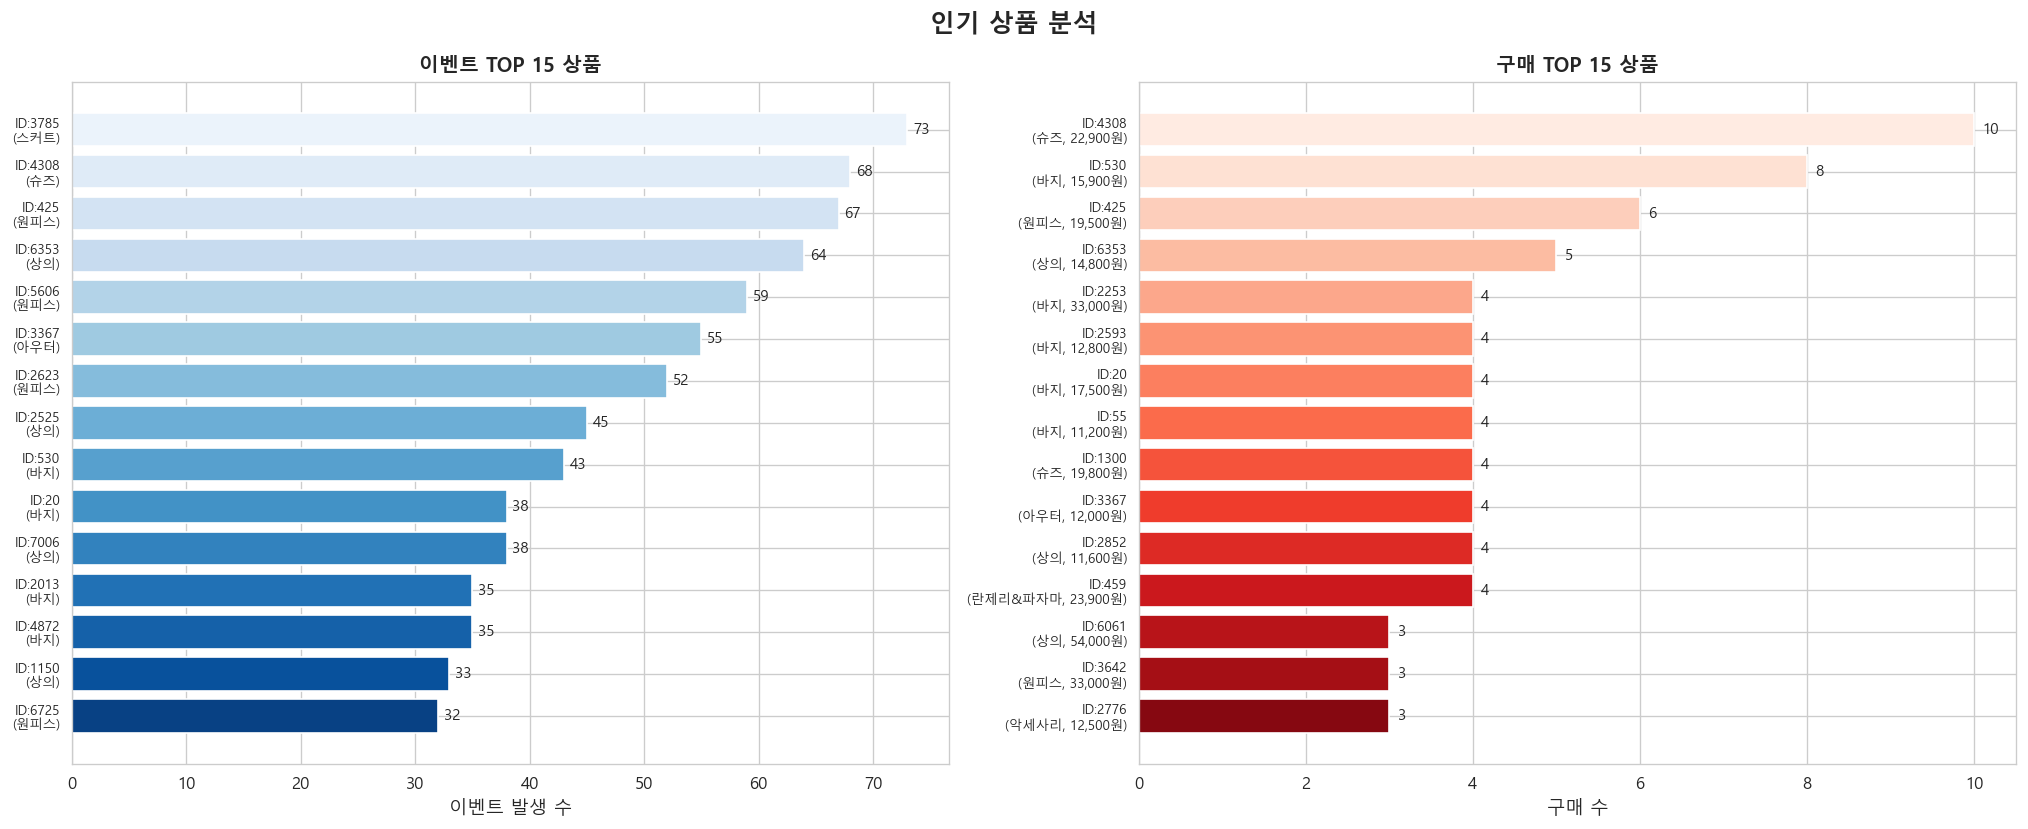

In [27]:
# ── 이벤트 기반 인기 상품 ──────────────────────────
popular_goods_log = logs[logs['event_goods_id'].notna()]['event_goods_id'].astype(int).value_counts()
popular_goods_buy = orders['goods_id'].value_counts()

# 상위 15개 상품 정보 가져오기
top15_buy = popular_goods_buy.head(15).reset_index()
top15_buy.columns = ['goods_id', '구매수']
top15_buy = top15_buy.merge(goods[['goods_id','category','price','shop_id']], on='goods_id', how='left')
top15_buy = top15_buy.merge(shops[['shop_id','name']], on='shop_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('인기 상품 분석', fontsize=15, fontweight='bold')

ax = axes[0]
top_log = popular_goods_log.head(15)
top_log_info = top_log.reset_index()
top_log_info.columns = ['goods_id','이벤트수']
top_log_info = top_log_info.merge(goods[['goods_id','category']], on='goods_id', how='left')

colors_pop = [sns.color_palette('Set3',12)[list(goods['category'].unique()).index(c)
              if c in goods['category'].unique() else 0]
              for c in top_log_info['category'].fillna('기타')]
bars = ax.barh(range(15), top_log_info['이벤트수'][::-1].values,
               color=sns.color_palette('Blues_r', 15))
ax.set_yticks(range(15))
ax.set_yticklabels([f"ID:{r['goods_id']}\n({r['category']})" 
                    for _, r in top_log_info.iloc[::-1].iterrows()], fontsize=8)
for bar in bars:
    w = bar.get_width()
    ax.text(w+0.5, bar.get_y()+bar.get_height()/2, f'{w:,}',
            va='center', fontsize=9)
ax.set_xlabel('이벤트 발생 수', fontsize=11)
ax.set_title('이벤트 TOP 15 상품', fontsize=12, fontweight='bold')

ax = axes[1]
bars = ax.barh(range(len(top15_buy)), top15_buy['구매수'][::-1].values,
               color=sns.color_palette('Reds_r', 15))
ax.set_yticks(range(len(top15_buy)))
ax.set_yticklabels([f"ID:{r['goods_id']}\n({r['category']}, {r['price']:,}원)" 
                    for _, r in top15_buy.iloc[::-1].iterrows()], fontsize=8)
for bar in bars:
    w = bar.get_width()
    ax.text(w+0.1, bar.get_y()+bar.get_height()/2, f'{w:,}',
            va='center', fontsize=9)
ax.set_xlabel('구매 수', fontsize=11)
ax.set_title('구매 TOP 15 상품', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('output/fig_17_popular_goods.png', bbox_inches='tight')
plt.show()

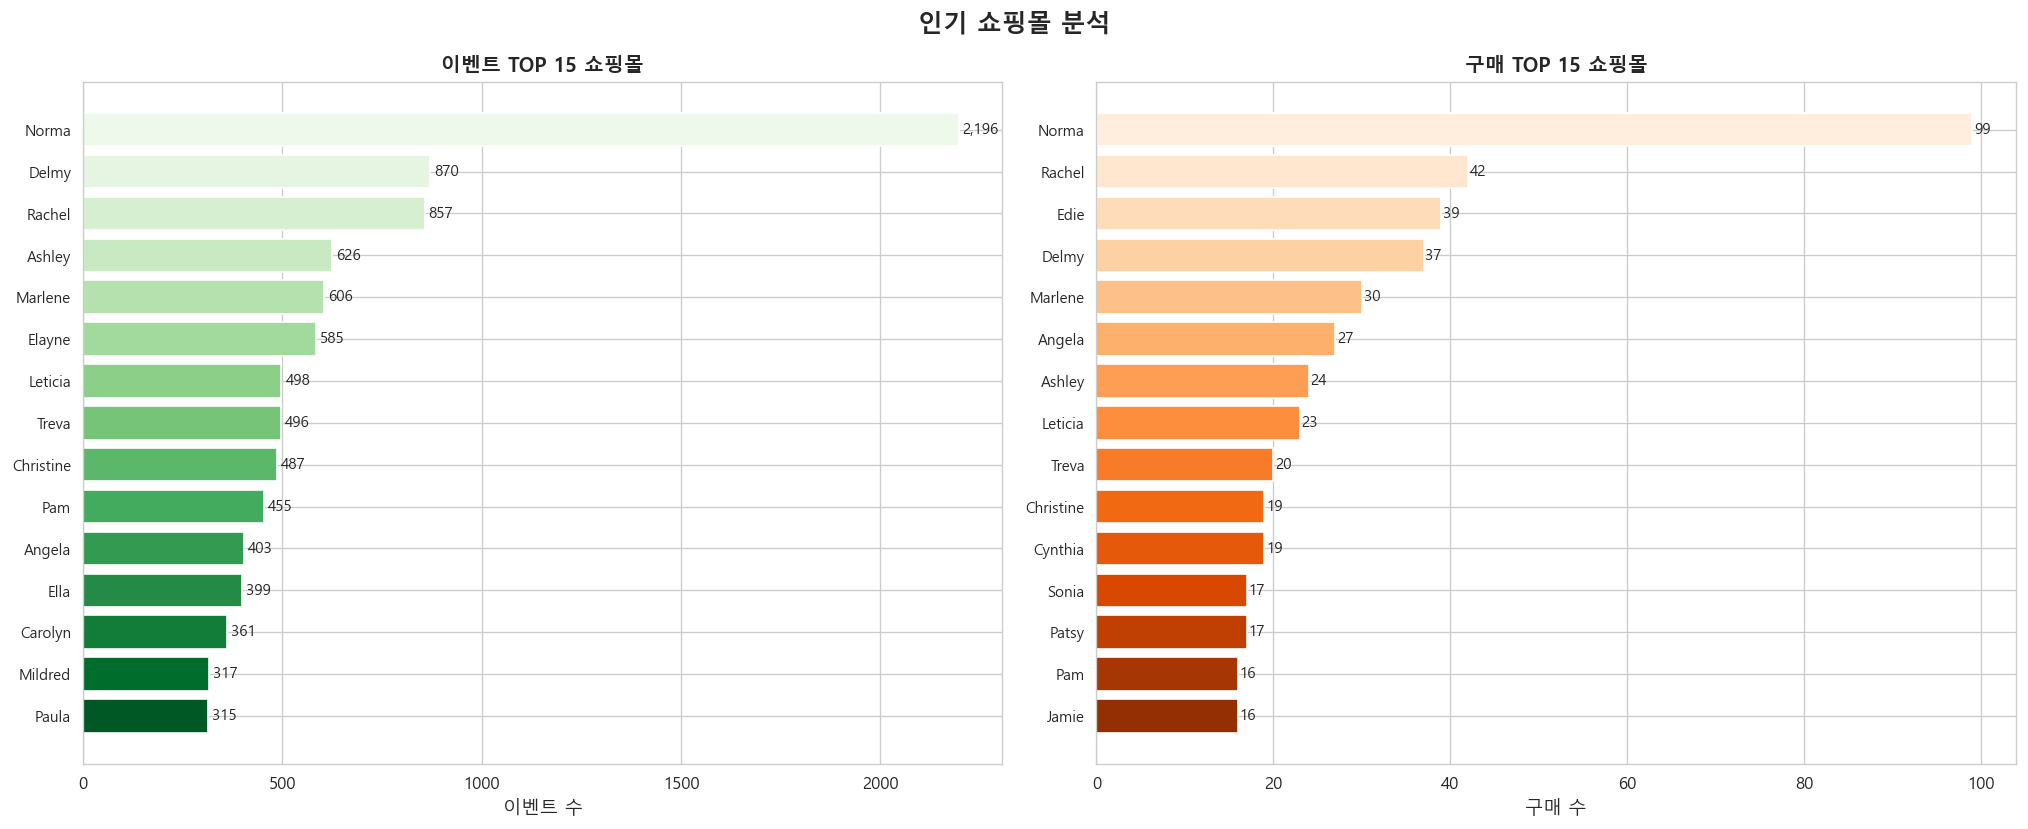

In [28]:
# ── 쇼핑몰 인기 분석 (이벤트 수 vs 구매 수) ────────────
shop_event_cnt = logs[logs['event_shop_id'].notna()]['event_shop_id'].astype(int).value_counts()
shop_order_cnt = orders['shop_id'].value_counts()

shop_popularity = pd.DataFrame({
    '이벤트수': shop_event_cnt,
    '구매수': shop_order_cnt
}).fillna(0)
shop_popularity = shop_popularity.merge(shops[['shop_id','name','category']], 
                                         left_index=True, right_on='shop_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('인기 쇼핑몰 분석', fontsize=15, fontweight='bold')

ax = axes[0]
top_shop_event = shop_popularity.nlargest(15, '이벤트수')
bars = ax.barh(range(15), top_shop_event['이벤트수'][::-1].values,
               color=sns.color_palette('Greens_r', 15))
ax.set_yticks(range(15))
ax.set_yticklabels(top_shop_event['name'].fillna('Unknown')[::-1].values, fontsize=9)
for bar in bars:
    w = bar.get_width()
    ax.text(w+10, bar.get_y()+bar.get_height()/2, f'{w:,.0f}',
            va='center', fontsize=9)
ax.set_xlabel('이벤트 수', fontsize=11)
ax.set_title('이벤트 TOP 15 쇼핑몰', fontsize=12, fontweight='bold')

ax = axes[1]
top_shop_buy = shop_popularity[shop_popularity['구매수']>0].nlargest(15, '구매수')
bars = ax.barh(range(len(top_shop_buy)), top_shop_buy['구매수'][::-1].values,
               color=sns.color_palette('Oranges_r', 15))
ax.set_yticks(range(len(top_shop_buy)))
ax.set_yticklabels(top_shop_buy['name'].fillna('Unknown')[::-1].values, fontsize=9)
for bar in bars:
    w = bar.get_width()
    ax.text(w+0.2, bar.get_y()+bar.get_height()/2, f'{w:.0f}',
            va='center', fontsize=9)
ax.set_xlabel('구매 수', fontsize=11)
ax.set_title('구매 TOP 15 쇼핑몰', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('output/fig_18_popular_shops.png', bbox_inches='tight')
plt.show()

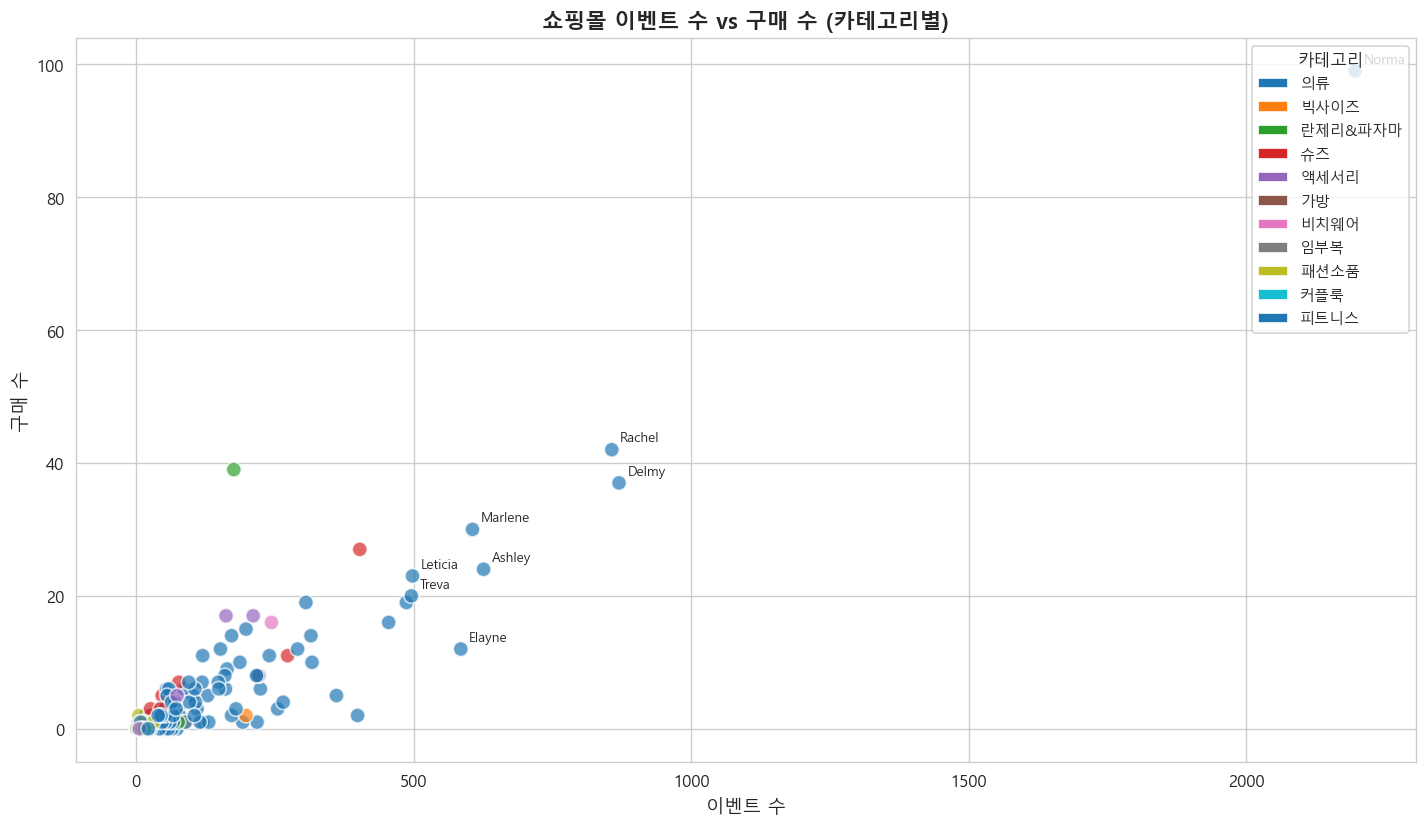

In [29]:
# ── 쇼핑몰 이벤트 수 vs 구매 수 산점도 ────────────────
fig, ax = plt.subplots(figsize=(12, 7))

scatter_data = shop_popularity[shop_popularity['이벤트수'] > 0].copy()

# 카테고리별 색상
categories_shop = scatter_data['category'].fillna('기타').unique()
cat_colors = {c: sns.color_palette('tab10', len(categories_shop))[i] 
              for i, c in enumerate(categories_shop)}
colors_sc = [cat_colors.get(c, 'gray') for c in scatter_data['category'].fillna('기타')]

sc = ax.scatter(scatter_data['이벤트수'], scatter_data['구매수'],
               c=colors_sc, alpha=0.7, s=80, edgecolors='white')

# 상위 쇼핑몰 레이블
for _, row in scatter_data.nlargest(8, '이벤트수').iterrows():
    ax.annotate(row['name'] if pd.notna(row['name']) else '',
               (row['이벤트수'], row['구매수']),
               textcoords='offset points', xytext=(5, 5), fontsize=8)

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cat_colors[c], label=c) for c in categories_shop]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, title='카테고리')

ax.set_xlabel('이벤트 수', fontsize=11)
ax.set_ylabel('구매 수', fontsize=11)
ax.set_title('쇼핑몰 이벤트 수 vs 구매 수 (카테고리별)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('output/fig_19_shop_scatter.png', bbox_inches='tight')
plt.show()

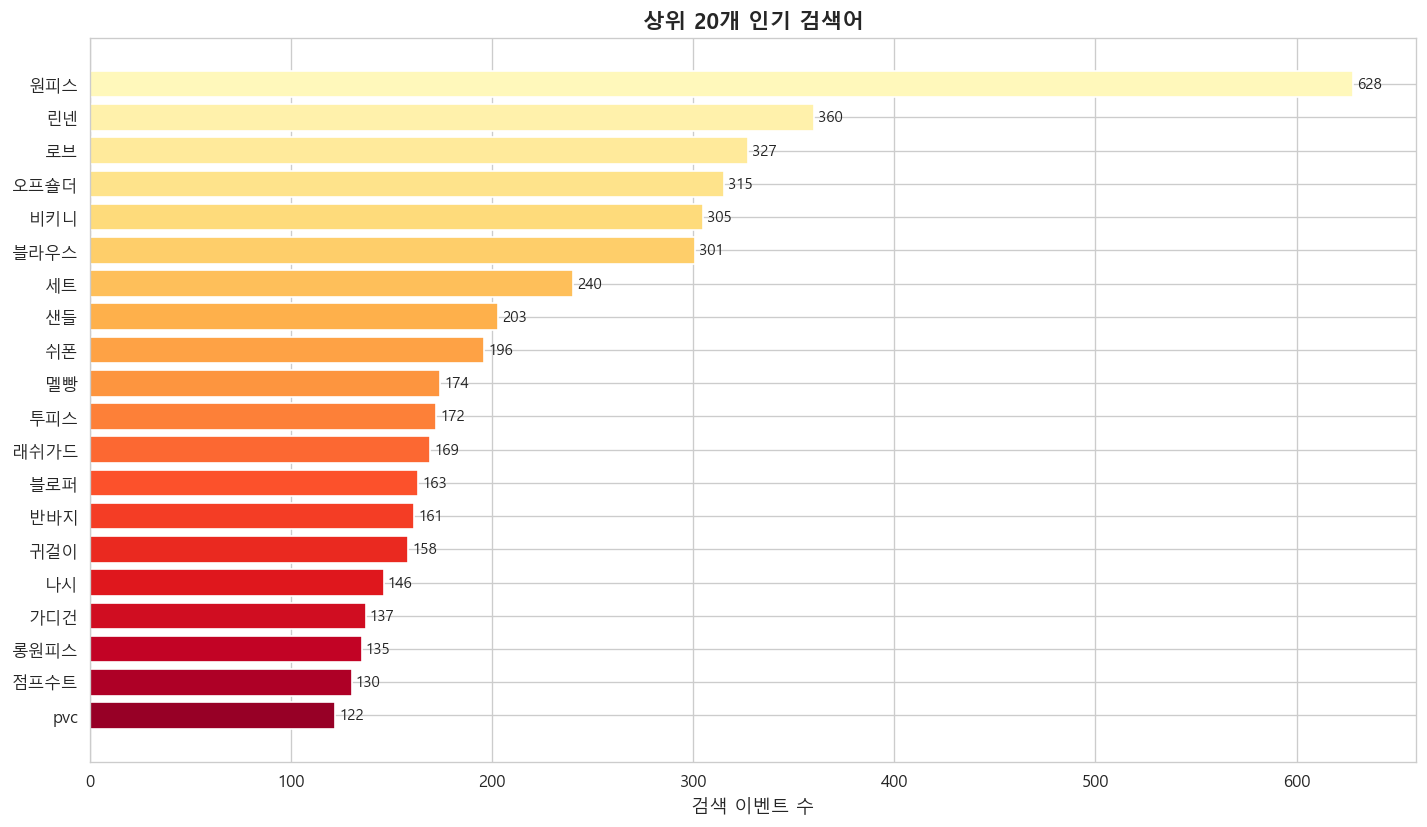


■ 카테고리 검색 상위 15개
cat_keyword
상의         2102
원피스        1336
바지         1150
스커트         690
슈즈          614
비치웨어        336
아우터         322
가방          322
악세사리        282
패션소품        169
란제리&파자마     165
피트니스         50


In [30]:
# ── 검색어 분석 ──────────────────────────────────
search_logs = logs[logs['origin_type']=='상품 검색'].copy()
search_logs['keyword'] = search_logs['event_origin'].str.replace('goods_search_result/', '', regex=False)
search_keyword_cnt = search_logs['keyword'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(search_keyword_cnt.index[::-1], search_keyword_cnt.values[::-1],
               color=sns.color_palette('YlOrRd', 20)[::-1])
for bar in bars:
    w = bar.get_width()
    ax.text(w+2, bar.get_y()+bar.get_height()/2, f'{w:,}',
            va='center', fontsize=9)
ax.set_xlabel('검색 이벤트 수', fontsize=11)
ax.set_title('상위 20개 인기 검색어', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/fig_20_search_keywords.png', bbox_inches='tight')
plt.show()

# 카테고리 검색 키워드
cat_search_logs = logs[logs['origin_type']=='카테고리 검색'].copy()
cat_search_logs['cat_keyword'] = cat_search_logs['event_origin'].str.replace('category_search_result/', '', regex=False)
cat_keyword_cnt = cat_search_logs['cat_keyword'].value_counts().head(15)

print('\n■ 카테고리 검색 상위 15개')
print(cat_keyword_cnt.to_string())

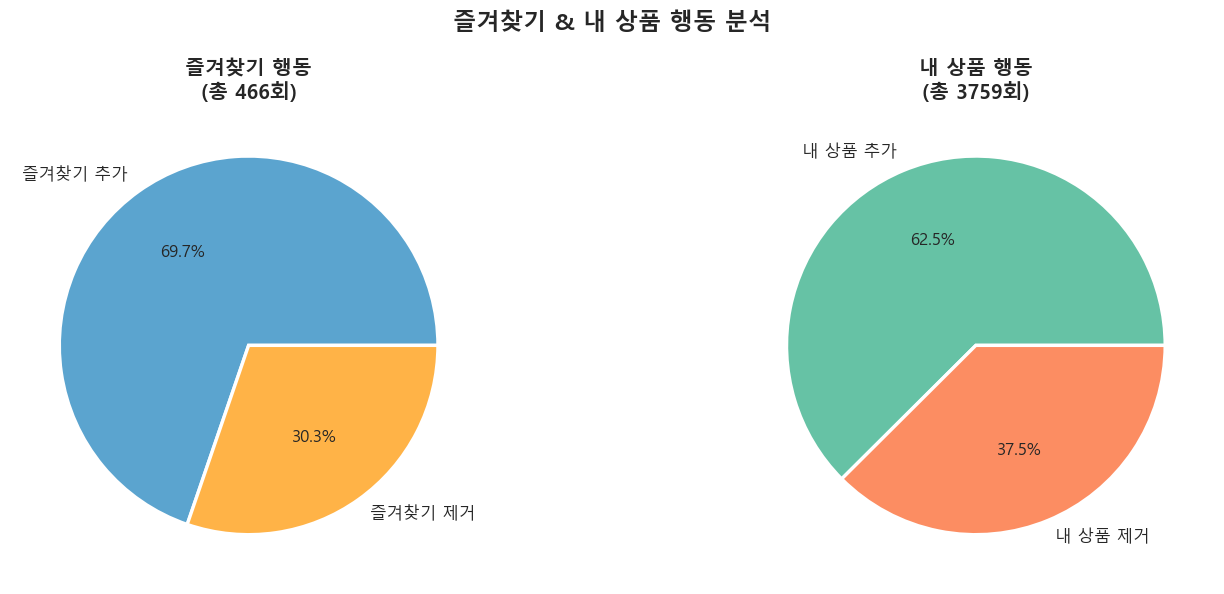


■ 행동 지속성 지표
  즐겨찾기 유지율: 69.7%
  내 상품 유지율: 62.5%


In [31]:
# ── 즐겨찾기(북마크) 패턴 분석 ────────────────────────
add_bm   = (logs['event_name'] == 'add_bookmark').sum()
rm_bm    = (logs['event_name'] == 'remove_bookmark').sum()
add_mg   = (logs['event_name'] == 'add_my_goods').sum()
rm_mg    = (logs['event_name'] == 'remove_my_goods').sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('즐겨찾기 & 내 상품 행동 분석', fontsize=14, fontweight='bold')

ax = axes[0]
bm_labels = ['즐겨찾기 추가', '즐겨찾기 제거']
bm_values = [add_bm, rm_bm]
wedges, texts, autotexts = ax.pie(bm_values, labels=bm_labels, autopct='%1.1f%%',
                                   colors=['#5BA4CF','#FFB347'],
                                   wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title(f'즐겨찾기 행동\n(총 {add_bm+rm_bm}회)', fontsize=12, fontweight='bold')

ax = axes[1]
mg_labels = ['내 상품 추가', '내 상품 제거']
mg_values = [add_mg, rm_mg]
wedges, texts, autotexts = ax.pie(mg_values, labels=mg_labels, autopct='%1.1f%%',
                                   colors=['#66C2A5','#FC8D62'],
                                   wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title(f'내 상품 행동\n(총 {add_mg+rm_mg}회)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('output/fig_21_bookmark_mygoods.png', bbox_inches='tight')
plt.show()

print(f'\n■ 행동 지속성 지표')
print(f'  즐겨찾기 유지율: {add_bm/(add_bm+rm_bm)*100:.1f}%')
print(f'  내 상품 유지율: {add_mg/(add_mg+rm_mg)*100:.1f}%')

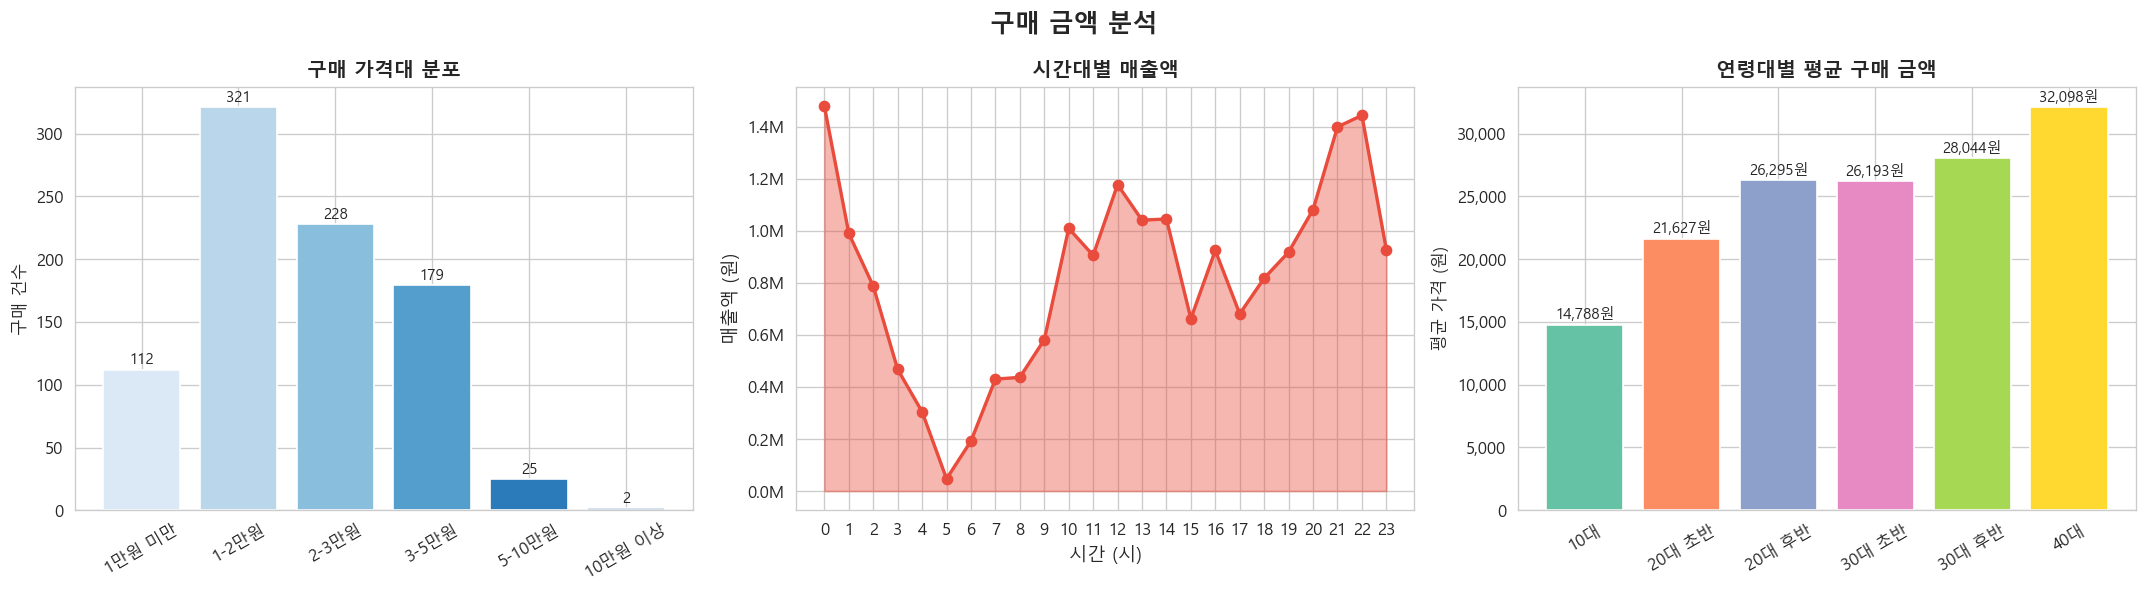


■ 구매 금액 통계
  총 매출: 19,759,320원
  평균 구매 금액: 22,790원
  중앙 구매 금액: 20,000원


In [32]:
# ── 구매 금액 분석 ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('구매 금액 분석', fontsize=15, fontweight='bold')

# (1) 구매 가격대 분포
ax = axes[0]
price_order = ['1만원 미만','1-2만원','2-3만원','3-5만원','5-10만원','10만원 이상']
order_price_cnt = orders['price_band'].value_counts().reindex(price_order).fillna(0)
bars = ax.bar(order_price_cnt.index, order_price_cnt.values,
              color=sns.color_palette('Blues', 6), edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+1, f'{h:.0f}',
            ha='center', va='bottom', fontsize=9)
ax.set_title('구매 가격대 분포', fontsize=12, fontweight='bold')
ax.set_ylabel('구매 건수')
ax.tick_params(axis='x', rotation=30)

# (2) 시간대별 누적 매출
ax = axes[1]
hourly_revenue = orders.groupby('hour')['price'].sum()
ax.fill_between(hourly_revenue.index, hourly_revenue.values, alpha=0.4, color='#E94B3C')
ax.plot(hourly_revenue.index, hourly_revenue.values, 'o-', color='#E94B3C', linewidth=2)
ax.set_xticks(range(0, 24))
ax.set_xlabel('시간 (시)', fontsize=11)
ax.set_ylabel('매출액 (원)', fontsize=11)
ax.set_title('시간대별 매출액', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# (3) 연령대별 평균 구매 금액
ax = axes[2]
age_avg_price = orders_u_valid.groupby('age_group')['price'].mean().reindex(age_order)
bars = ax.bar(age_avg_price.index, age_avg_price.values,
              color=sns.color_palette('Set2', len(age_order)), edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+100, f'{h:,.0f}원',
            ha='center', va='bottom', fontsize=9)
ax.set_title('연령대별 평균 구매 금액', fontsize=12, fontweight='bold')
ax.set_ylabel('평균 가격 (원)')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('output/fig_22_purchase_price.png', bbox_inches='tight')
plt.show()

print(f'\n■ 구매 금액 통계')
print(f'  총 매출: {orders["price"].sum():,}원')
print(f'  평균 구매 금액: {orders["price"].mean():,.0f}원')
print(f'  중앙 구매 금액: {orders["price"].median():,.0f}원')

## 11. 유저 세그먼트 심화 분석



### 11-1. 활동량 기반 유저 세그먼트 분석
유저를 활동량(event 수) 기준으로 Light / Medium / Heavy 세그먼트로 나누고,  
각 세그먼트의 구매율, 평균 이벤트 수, 평균 클릭 수를 비교합니다.  
이는 단순 분포 확인을 넘어 어떤 사용자군이 실제 구매와 더 가깝게 연결되는지 파악하기 위한 분석입니다.

=== 활동량 기반 유저 세그먼트 요약 ===


,유저수,평균_이벤트수,평균_클릭수,평균_즐겨찾기수,구매율
activity_segment,,,,,
Light,3753,1.84,0.08,0.00,1.23
Medium,2900,6.01,0.73,0.01,3.97
Heavy,3256,25.03,4.62,0.09,17.84


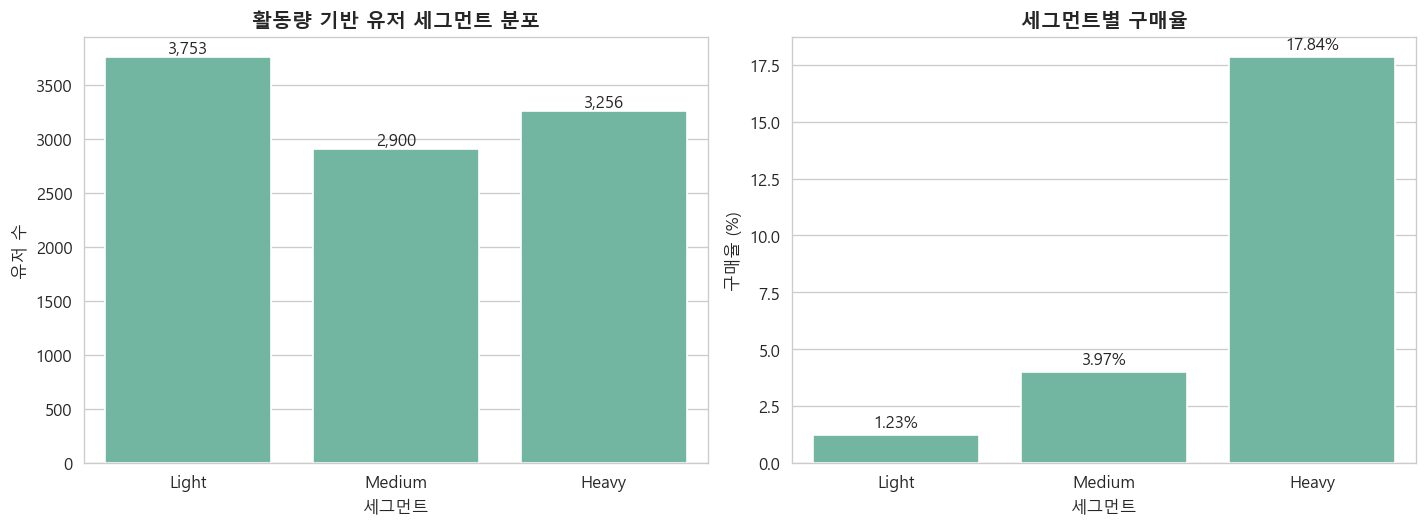


=== 세그먼트별 연령대 구성비(%) ===


age_group,10대,20대 초반,20대 후반,30대 초반,30대 후반,40대,미입력
activity_segment,,,,,,,
Heavy,18.34,18.06,17.20,16.98,15.36,10.04,4.02
Light,16.68,16.07,15.72,15.53,16.31,16.73,2.96
Medium,17.41,16.07,17.17,16.66,16.72,12.69,3.28



=== 세그먼트별 OS 구성비(%) ===


os,And,iOS
activity_segment,,
Heavy,47.54,52.46
Light,51.03,48.97
Medium,49.00,51.00


In [35]:
# ── 활동량 기반 유저 세그먼트 분석 ─────────────────────────
segment_user = logs.groupby('user_id').agg(
    event_count=('event_name', 'count'),
    click_count=('event_name', lambda x: (x == 'enter_browser').sum()),
    bookmark_count=('event_name', lambda x: (x == 'add_bookmark').sum()),
    mygoods_count=('event_name', lambda x: (x == 'add_my_goods').sum())
).reset_index()

segment_user['is_buyer'] = segment_user['user_id'].isin(orders['user_id'].unique())

# 분위수 기준 Light / Medium / Heavy 분류
q1 = segment_user['event_count'].quantile(0.33)
q2 = segment_user['event_count'].quantile(0.66)

def assign_activity_segment(x):
    if x <= q1:
        return 'Light'
    elif x <= q2:
        return 'Medium'
    else:
        return 'Heavy'

segment_user['activity_segment'] = segment_user['event_count'].apply(assign_activity_segment)
segment_user = segment_user.merge(users[['user_id', 'age_group', 'os']], on='user_id', how='left')

segment_summary = segment_user.groupby('activity_segment').agg(
    유저수=('user_id', 'count'),
    평균_이벤트수=('event_count', 'mean'),
    평균_클릭수=('click_count', 'mean'),
    평균_즐겨찾기수=('bookmark_count', 'mean'),
    구매율=('is_buyer', 'mean')
).reindex(['Light', 'Medium', 'Heavy'])

segment_summary['구매율'] = (segment_summary['구매율'] * 100).round(2)
segment_summary = segment_summary.round(2)

print("=== 활동량 기반 유저 세그먼트 요약 ===")
display(segment_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 세그먼트 분포
seg_counts = segment_user['activity_segment'].value_counts().reindex(['Light','Medium','Heavy'])
sns.barplot(x=seg_counts.index, y=seg_counts.values, ax=axes[0])
axes[0].set_title('활동량 기반 유저 세그먼트 분포', fontsize=12, fontweight='bold')
axes[0].set_xlabel('세그먼트')
axes[0].set_ylabel('유저 수')

for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + max(seg_counts.values)*0.01, f'{v:,}', ha='center', fontsize=10)

# 세그먼트별 구매율
sns.barplot(x=segment_summary.index, y=segment_summary['구매율'], ax=axes[1])
axes[1].set_title('세그먼트별 구매율', fontsize=12, fontweight='bold')
axes[1].set_xlabel('세그먼트')
axes[1].set_ylabel('구매율 (%)')

for i, v in enumerate(segment_summary['구매율'].values):
    axes[1].text(i, v + max(segment_summary['구매율'].values)*0.02, f'{v:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('output/fig_23_user_segments.png', bbox_inches='tight')
plt.show()

# 연령/OS 분포 보조 분석
segment_age = pd.crosstab(segment_user['activity_segment'], segment_user['age_group'], normalize='index') * 100
segment_os = pd.crosstab(segment_user['activity_segment'], segment_user['os'], normalize='index') * 100

print("\n=== 세그먼트별 연령대 구성비(%) ===")
display(segment_age.round(2))

print("\n=== 세그먼트별 OS 구성비(%) ===")
display(segment_os.round(2))

■ 구매 유저 기본 통계
  총 구매 유저: 832명
  평균 구매 횟수: 1.04회
  평균 구매 금액: 23,749원

■ 가치 세그먼트별 유저 수
value_segment
저가치(1-3만원)    279
중가치(3-5만원)    278
고가치(5만원+)     275



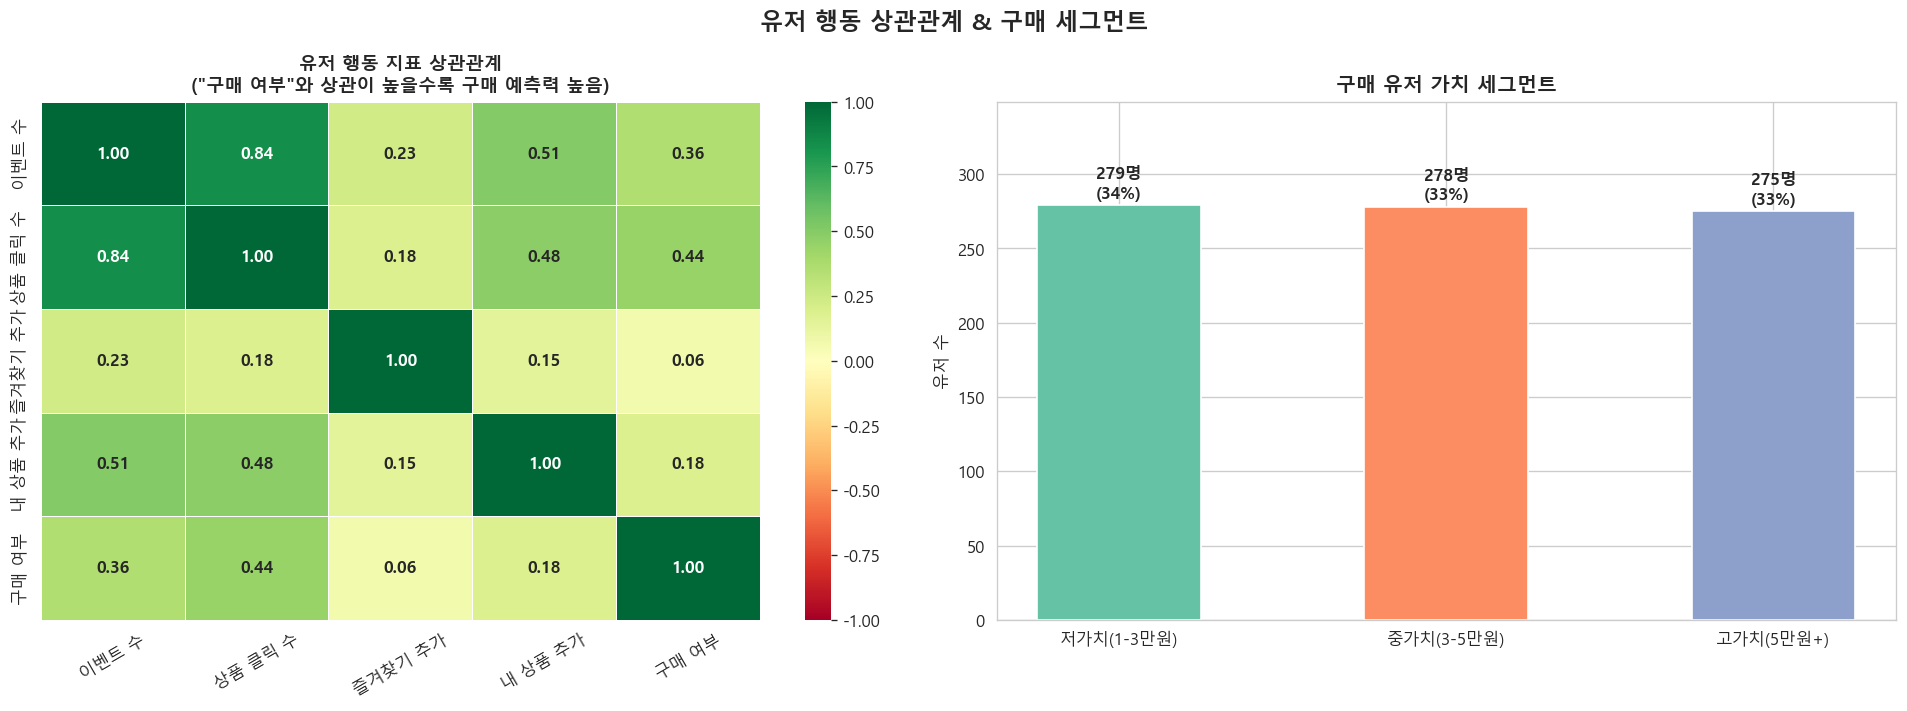


■ 주요 상관계수 (vs 구매 여부)
  이벤트 수       : r = 0.358
  상품 클릭 수     : r = 0.441
  즐겨찾기 추가     : r = 0.064
  내 상품 추가     : r = 0.183


In [36]:
# ── 활동 기반 유저 세그먼트 (개선된 RFM) ─────────────────────────
# 하루 데이터에서 Recency는 의미 없음 → F(구매 횟수) + M(구매 금액) 중심
# 비구매 유저를 포함한 전체 유저 활동 세그먼트도 함께 분석

rfm = orders.groupby('user_id').agg(
    frequency=('goods_id', 'count'),
    monetary=('price', 'sum')
).reset_index()
rfm = rfm.merge(users[['user_id','age_group','os']], on='user_id', how='left')

# 구매 금액 기준 세그먼트
rfm['value_segment'] = pd.qcut(rfm['monetary'], q=3,
                                labels=['저가치(1-3만원)', '중가치(3-5만원)', '고가치(5만원+)'])

print('■ 구매 유저 기본 통계')
print(f'  총 구매 유저: {len(rfm):,}명')
print(f'  평균 구매 횟수: {rfm["frequency"].mean():.2f}회')
print(f'  평균 구매 금액: {rfm["monetary"].mean():,.0f}원')
print()
print('■ 가치 세그먼트별 유저 수')
print(rfm['value_segment'].value_counts().to_string())
print()

# ── 전체 유저 활동 세그먼트 ────────────────────────────────
user_summary = logs.groupby('user_id').agg(
    event_count   =('event_name', 'count'),
    click_count   =('event_name', lambda x: (x == 'enter_browser').sum()),
    bookmark_count=('event_name', lambda x: (x == 'add_bookmark').sum()),
    mygoods_count =('event_name', lambda x: (x == 'add_my_goods').sum()),
).reset_index()
user_summary['is_buyer'] = user_summary['user_id'].isin(orders['user_id'])

# ── 상관관계 분석 ─────────────────────────────────────────
corr_cols = ['event_count', 'click_count', 'bookmark_count', 'mygoods_count', 'is_buyer']
corr_labels = ['이벤트 수', '상품 클릭 수', '즐겨찾기 추가', '내 상품 추가', '구매 여부']
corr_df = user_summary[corr_cols].copy()
corr_df.columns = corr_labels
corr_matrix = corr_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('유저 행동 상관관계 & 구매 세그먼트', fontsize=14, fontweight='bold')

# 상관관계 히트맵
ax = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # 상삼각 마스킹
sns.heatmap(corr_matrix, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 10, 'weight': 'bold'})
ax.set_title('유저 행동 지표 상관관계\n("구매 여부"와 상관이 높을수록 구매 예측력 높음)', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=30)

# 구매 금액 세그먼트 분포
ax = axes[1]
seg_cnt = rfm['value_segment'].value_counts().sort_index()
colors_seg2 = ['#66C2A5', '#FC8D62', '#8DA0CB']
bars = ax.bar(seg_cnt.index, seg_cnt.values, color=colors_seg2, edgecolor='white', width=0.5)
for bar, v in zip(bars, seg_cnt.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+2, f'{v}명\n({v/len(rfm)*100:.0f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('구매 유저 가치 세그먼트', fontsize=12, fontweight='bold')
ax.set_ylabel('유저 수')
ax.set_ylim(0, seg_cnt.max() * 1.25)

plt.tight_layout()
plt.savefig('output/fig_23_rfm.png', bbox_inches='tight')
plt.show()

print('\n■ 주요 상관계수 (vs 구매 여부)')
for col in corr_labels[:-1]:
    r = corr_matrix.loc[col, '구매 여부']
    print(f'  {col:12s}: r = {r:.3f}')


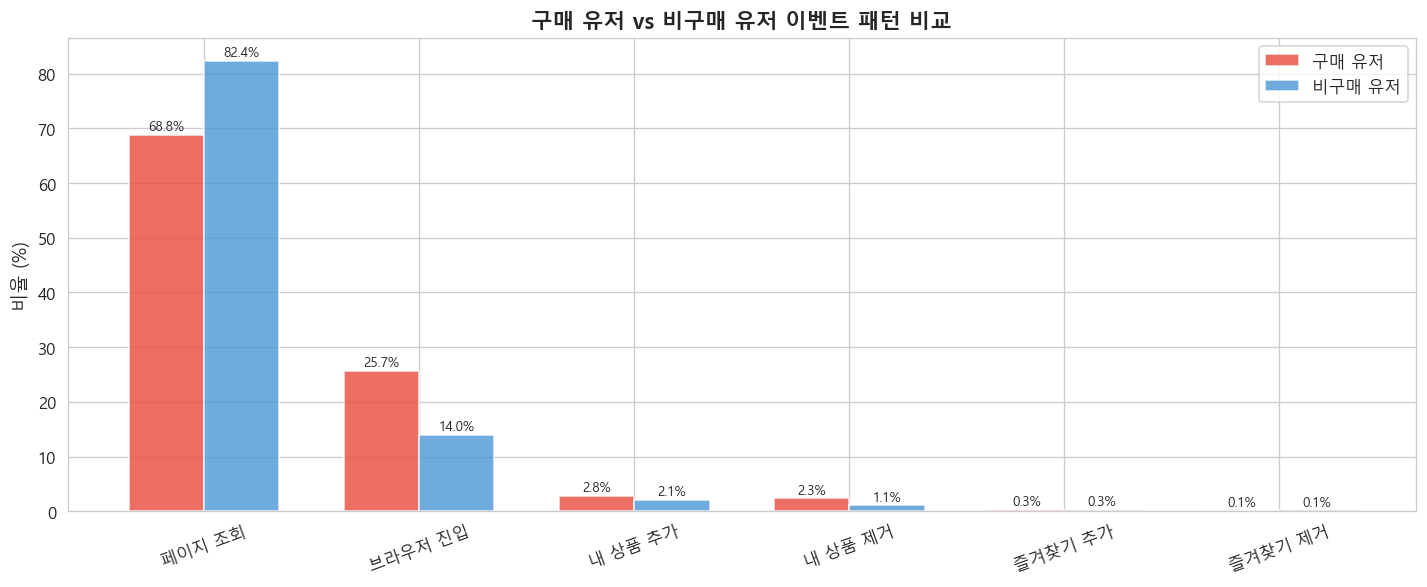

In [37]:
# ── 비구매 유저 vs 구매 유저 행동 비교 ──────────────────
buyer_ids = set(orders['user_id'].unique())
logs_u['is_buyer'] = logs_u['user_id'].isin(buyer_ids)

buyer_event = logs_u[logs_u['is_buyer']]['event_name'].value_counts(normalize=True)*100
nonbuyer_event = logs_u[~logs_u['is_buyer']]['event_name'].value_counts(normalize=True)*100

compare_df = pd.DataFrame({'구매 유저': buyer_event, '비구매 유저': nonbuyer_event}).fillna(0)
compare_df.index = [event_label_map.get(i, i) for i in compare_df.index]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(compare_df))
width = 0.35
bars1 = ax.bar(x - width/2, compare_df['구매 유저'], width,
               label='구매 유저', color='#E94B3C', alpha=0.8)
bars2 = ax.bar(x + width/2, compare_df['비구매 유저'], width,
               label='비구매 유저', color='#4C96D7', alpha=0.8)

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(compare_df.index, rotation=20)
ax.set_ylabel('비율 (%)', fontsize=11)
ax.set_title('구매 유저 vs 비구매 유저 이벤트 패턴 비교', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('output/fig_24_buyer_nonbuyer.png', bbox_inches='tight')
plt.show()

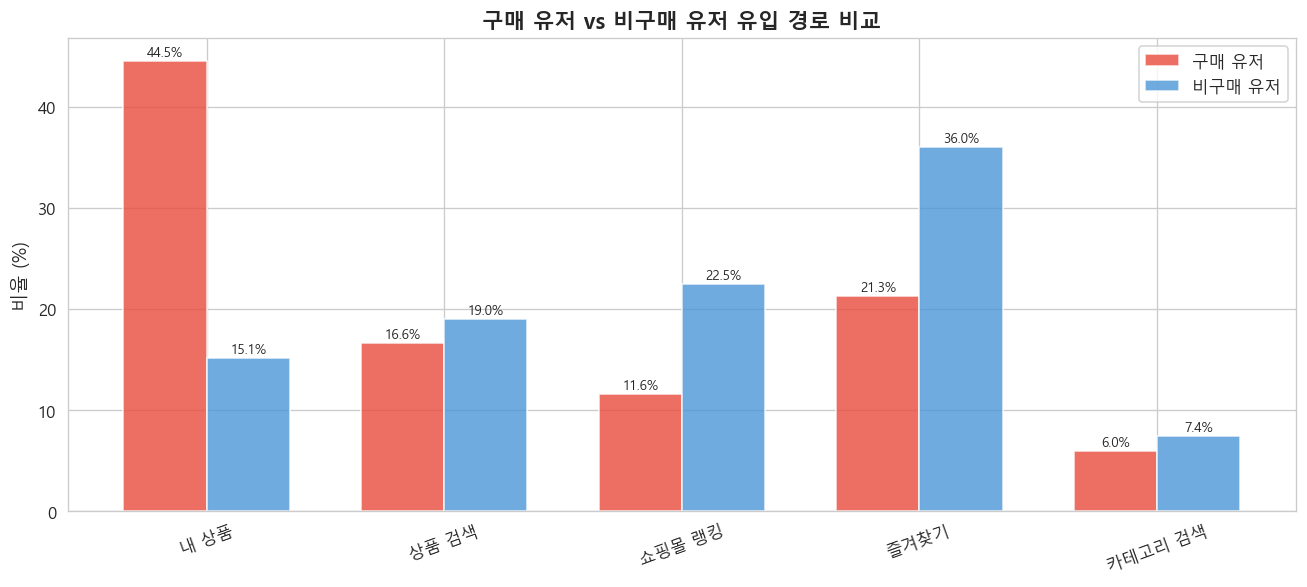

In [38]:
# ── 구매 전 행동 패턴 (구매 유저의 유입 경로) ─────────────
buyer_origin = logs_u[logs_u['is_buyer']]['origin_type'].value_counts()
nonbuyer_origin = logs_u[~logs_u['is_buyer']]['origin_type'].value_counts()

origin_compare = pd.DataFrame({
    '구매 유저': buyer_origin / buyer_origin.sum() * 100,
    '비구매 유저': nonbuyer_origin / nonbuyer_origin.sum() * 100
}).fillna(0)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(origin_compare))
width = 0.35
bars1 = ax.bar(x - width/2, origin_compare['구매 유저'], width,
               label='구매 유저', color='#E94B3C', alpha=0.8)
bars2 = ax.bar(x + width/2, origin_compare['비구매 유저'], width,
               label='비구매 유저', color='#4C96D7', alpha=0.8)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.2, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(origin_compare.index, rotation=20)
ax.set_ylabel('비율 (%)', fontsize=11)
ax.set_title('구매 유저 vs 비구매 유저 유입 경로 비교', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('output/fig_25_buyer_origin.png', bbox_inches='tight')
plt.show()

### 11-5. 활동 수준별 구매율 분석
단순히 이벤트 수 분포를 보는 것을 넘어,  
활동 수준이 높아질수록 실제 구매율이 어떻게 달라지는지 확인합니다.

,유저수,구매유저수,평균이벤트수,구매율(%)
activity_level,,,,
1-5회,5068,84,2.52,1.66
6-10회,1815,88,7.65,4.85
11-20회,1621,183,14.64,11.29
21-50회,1127,264,30.72,23.43
51회+,278,123,74.92,44.24


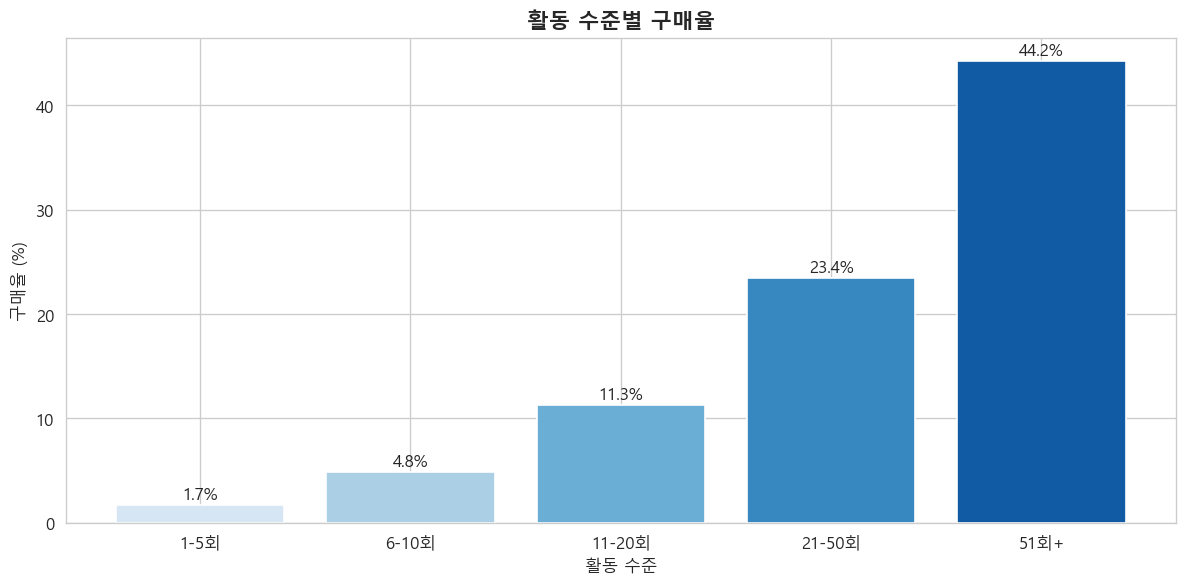

In [39]:
# ── 활동 수준별 구매율 분석 ───────────────────────────────
activity_user = logs.groupby('user_id').size().reset_index(name='event_count')
activity_user['is_buyer'] = activity_user['user_id'].isin(orders['user_id'].unique())

bins = [0, 5, 10, 20, 50, 10_000]
labels = ['1-5회', '6-10회', '11-20회', '21-50회', '51회+']
activity_user['activity_level'] = pd.cut(
    activity_user['event_count'],
    bins=bins,
    labels=labels
)

activity_purchase = activity_user.groupby('activity_level').agg(
    유저수=('user_id', 'count'),
    구매유저수=('is_buyer', 'sum'),
    평균이벤트수=('event_count', 'mean')
)
activity_purchase['구매율(%)'] = activity_purchase['구매유저수'] / activity_purchase['유저수'] * 100

display(activity_purchase.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(activity_purchase.index.astype(str), activity_purchase['구매율(%)'],
              color=sns.color_palette('Blues', len(activity_purchase)), edgecolor='white')
for bar, v in zip(bars, activity_purchase['구매율(%)']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.2, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=10)
ax.set_title('활동 수준별 구매율', fontsize=13, fontweight='bold')
ax.set_xlabel('활동 수준')
ax.set_ylabel('구매율 (%)')
plt.tight_layout()
plt.savefig('output/fig_26b_activity_purchase_rate.png', bbox_inches='tight')
plt.show()

### 11-6. 행동 지표 상관관계 히트맵
구매 여부와 가장 밀접한 행동 지표를 시각적으로 확인합니다.

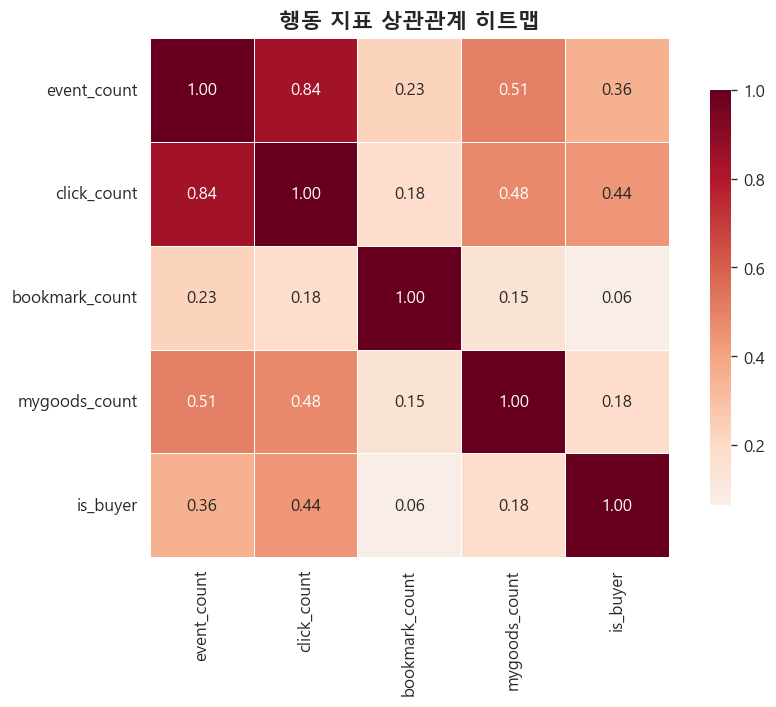

■ 구매 여부와의 상관계수
click_count       0.441
event_count       0.358
mygoods_count     0.183
bookmark_count    0.064


In [40]:
# ── 행동 지표 상관관계 히트맵 ─────────────────────────────
corr_cols = ['event_count', 'click_count', 'bookmark_count', 'mygoods_count', 'is_buyer']
corr_df = user_summary[corr_cols].copy()
corr_df['is_buyer'] = corr_df['is_buyer'].astype(int)
corr_mat = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('행동 지표 상관관계 히트맵', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/fig_26c_behavior_corr_heatmap.png', bbox_inches='tight')
plt.show()

buyer_corr = corr_mat['is_buyer'].drop('is_buyer').sort_values(ascending=False)
print('■ 구매 여부와의 상관계수')
print(buyer_corr.round(3).to_string())

## 12. 통계적 유의성 검정

단순 비율 비교에서 나아가, 관찰된 차이가 **통계적으로 유의미한지** 카이제곱·t검정으로 검증합니다.


 통계적 유의성 검정 (유의수준 α = 0.05)

[검정 1] iOS vs Android 구매율 – 카이제곱 검정
  iOS:     전환율 9.63%  (n=5,079)
  Android: 전환율 6.97%  (n=4,921)
  χ² = 22.798,  p = 0.0000,  Cramér's V = 0.048  →  ★ 유의미한 차이

[검정 2] 구매 vs 비구매 유저 평균 이벤트 수
  구매 유저:   29.82회  (n=742)
  비구매 유저: 9.13회  (n=9,167)
  Welch t = 20.009,  p = 5.8986e-72
  Mann-Whitney U p = 6.3556e-186,  Cohen's d = 1.458
  → ★ 유의미한 차이

[검정 3] 구매 vs 비구매 유저 평균 클릭 수
  구매 유저:   7.66회  (n=742)
  비구매 유저: 1.28회  (n=9,167)
  Welch t = 22.184,  p = 2.2352e-84
  Mann-Whitney U p = 0.0000e+00,  Cohen's d = 1.866
  → ★ 유의미한 차이

[검정 4] 연령 미입력 vs 입력 유저 구매율 – 카이제곱 검정
  미입력: 12.24%  (n=343)
  입력:   8.18%  (n=9,657)
  χ² = 6.650,  p = 0.0099,  Cramér's V = 0.026  →  ★ 유의미한 차이



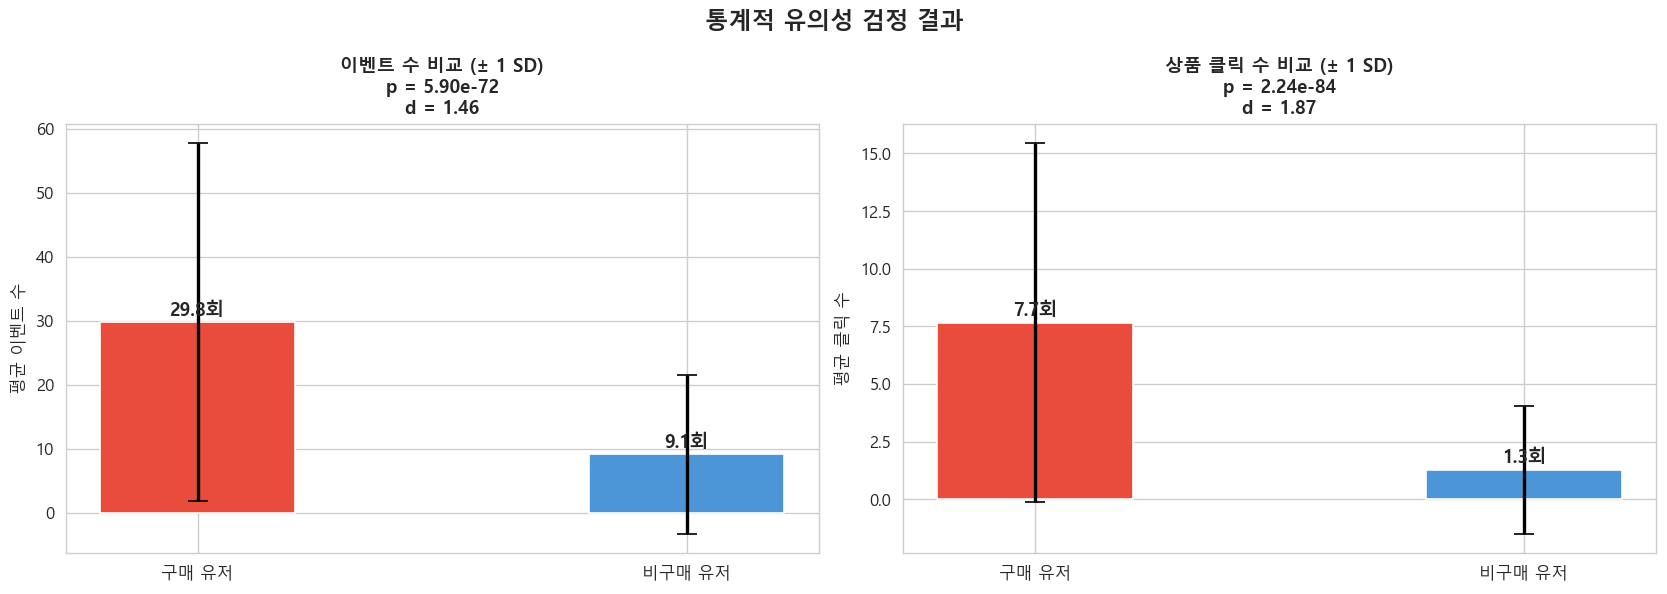

In [41]:
from scipy import stats as scipy_stats
import numpy as np

def cramers_v(table):
    chi2 = scipy_stats.chi2_contingency(table)[0]
    n = table.sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / max(min(r - 1, k - 1), 1))

def cohens_d(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / dof)
    if pooled_std == 0:
        return 0.0
    return (x.mean() - y.mean()) / pooled_std

print('='*60)
print(' 통계적 유의성 검정 (유의수준 α = 0.05)')
print('='*60)
print()

# ── 검정 1: iOS vs Android 구매율 차이 ───────────────────────
ios_users     = users[users['os'] == 'iOS']['user_id']
android_users = users[users['os'] == 'And']['user_id']
buyer_ids_set = set(orders['user_id'])

ios_buy   = ios_users.isin(buyer_ids_set).sum()
ios_nobuy = len(ios_users) - ios_buy
and_buy   = android_users.isin(buyer_ids_set).sum()
and_nobuy = len(android_users) - and_buy

ct1 = np.array([[ios_buy, ios_nobuy], [and_buy, and_nobuy]])
chi2_1, p1, _, _ = scipy_stats.chi2_contingency(ct1)
v1 = cramers_v(ct1)

print('[검정 1] iOS vs Android 구매율 – 카이제곱 검정')
print(f'  iOS:     전환율 {ios_buy/len(ios_users)*100:.2f}%  (n={len(ios_users):,})')
print(f'  Android: 전환율 {and_buy/len(android_users)*100:.2f}%  (n={len(android_users):,})')
print(f'  χ² = {chi2_1:.3f},  p = {p1:.4f},  Cramér\'s V = {v1:.3f}  →  {"★ 유의미한 차이" if p1 < 0.05 else "유의미한 차이 없음"}')
print()

# ── 검정 2: 구매 vs 비구매 유저 평균 이벤트 수 차이 ───────────
buyer_events    = user_summary[user_summary['is_buyer']]['event_count']
nonbuyer_events = user_summary[~user_summary['is_buyer']]['event_count']
t2, p2 = scipy_stats.ttest_ind(buyer_events, nonbuyer_events, equal_var=False)
u2, p2_mw = scipy_stats.mannwhitneyu(buyer_events, nonbuyer_events, alternative='two-sided')
d2 = cohens_d(buyer_events, nonbuyer_events)

print('[검정 2] 구매 vs 비구매 유저 평균 이벤트 수')
print(f'  구매 유저:   {buyer_events.mean():.2f}회  (n={len(buyer_events):,})')
print(f'  비구매 유저: {nonbuyer_events.mean():.2f}회  (n={len(nonbuyer_events):,})')
print(f'  Welch t = {t2:.3f},  p = {p2:.4e}')
print(f'  Mann-Whitney U p = {p2_mw:.4e},  Cohen\'s d = {d2:.3f}')
print(f'  → {"★ 유의미한 차이" if p2 < 0.05 else "유의미한 차이 없음"}')
print()

# ── 검정 3: 구매 vs 비구매 유저 평균 클릭 수 차이 ─────────────
buyer_clicks    = user_summary[user_summary['is_buyer']]['click_count']
nonbuyer_clicks = user_summary[~user_summary['is_buyer']]['click_count']
t3, p3 = scipy_stats.ttest_ind(buyer_clicks, nonbuyer_clicks, equal_var=False)
u3, p3_mw = scipy_stats.mannwhitneyu(buyer_clicks, nonbuyer_clicks, alternative='two-sided')
d3 = cohens_d(buyer_clicks, nonbuyer_clicks)

print('[검정 3] 구매 vs 비구매 유저 평균 클릭 수')
print(f'  구매 유저:   {buyer_clicks.mean():.2f}회  (n={len(buyer_clicks):,})')
print(f'  비구매 유저: {nonbuyer_clicks.mean():.2f}회  (n={len(nonbuyer_clicks):,})')
print(f'  Welch t = {t3:.3f},  p = {p3:.4e}')
print(f'  Mann-Whitney U p = {p3_mw:.4e},  Cohen\'s d = {d3:.3f}')
print(f'  → {"★ 유의미한 차이" if p3 < 0.05 else "유의미한 차이 없음"}')
print()

# ── 검정 4: 연령 미입력 vs 입력 유저 구매율 ───────────────────
unk_ids = set(users[users['age'] < 0]['user_id'])
kno_ids = set(users[users['age'] >= 0]['user_id'])
unk_buy = len(set(orders['user_id']) & unk_ids)
kno_buy = len(set(orders['user_id']) & kno_ids)
ct4 = np.array([[unk_buy, len(unk_ids) - unk_buy], [kno_buy, len(kno_ids) - kno_buy]])
chi2_4, p4, _, _ = scipy_stats.chi2_contingency(ct4)
v4 = cramers_v(ct4)

print('[검정 4] 연령 미입력 vs 입력 유저 구매율 – 카이제곱 검정')
print(f'  미입력: {unk_buy/len(unk_ids)*100:.2f}%  (n={len(unk_ids):,})')
print(f'  입력:   {kno_buy/len(kno_ids)*100:.2f}%  (n={len(kno_ids):,})')
print(f'  χ² = {chi2_4:.3f},  p = {p4:.4f},  Cramér\'s V = {v4:.3f}  →  {"★ 유의미한 차이" if p4 < 0.05 else "유의미한 차이 없음"}')
print()

# ── 시각화 ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('통계적 유의성 검정 결과', fontsize=14, fontweight='bold')

ax = axes[0]
grp_labels = ['구매 유저', '비구매 유저']
grp_means  = [buyer_events.mean(), nonbuyer_events.mean()]
grp_stds   = [buyer_events.std(), nonbuyer_events.std()]
bars = ax.bar(grp_labels, grp_means, color=['#E94B3C', '#4C96D7'],
              edgecolor='white', width=0.4, yerr=grp_stds, capsize=6,
              error_kw={'linewidth': 2})
for bar, m in zip(bars, grp_means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.3, f'{m:.1f}회',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
sig_str = f'p = {p2:.2e}\nd = {d2:.2f}'
ax.set_title(f'이벤트 수 비교 (± 1 SD)\n{sig_str}', fontsize=11, fontweight='bold')
ax.set_ylabel('평균 이벤트 수')

ax = axes[1]
grp_means2 = [buyer_clicks.mean(), nonbuyer_clicks.mean()]
grp_stds2  = [buyer_clicks.std(), nonbuyer_clicks.std()]
bars = ax.bar(grp_labels, grp_means2, color=['#E94B3C', '#4C96D7'],
              edgecolor='white', width=0.4, yerr=grp_stds2, capsize=6,
              error_kw={'linewidth': 2})
for bar, m in zip(bars, grp_means2):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.1, f'{m:.1f}회',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
sig_str2 = f'p = {p3:.2e}\nd = {d3:.2f}'
ax.set_title(f'상품 클릭 수 비교 (± 1 SD)\n{sig_str2}', fontsize=11, fontweight='bold')
ax.set_ylabel('평균 클릭 수')

plt.tight_layout()
plt.savefig('output/fig_26_stat_test.png', bbox_inches='tight')
plt.show()

## 13. 세션 분석

30분 비활동 기준으로 세션을 정의합니다.  
1회 방문당 행동 패턴을 파악해 UX 개선 방향을 도출합니다.


■ 세션 분석 기본 통계
  총 세션 수: 17,778개
  세션당 평균 이벤트: 6.0회
  세션당 평균 지속시간: 9.4분
  세션당 중앙 지속시간: 2.2분
  클릭 발생 세션 비율: 36.1%
  즐겨찾기 발생 세션 비율: 1.5%

■ 구매 경험 유저 vs 비구매 유저의 세션 비교
  구매 경험 유저 세션   – 평균 이벤트: 10.5회  /  평균 지속: 18.9분
  비구매 유저 세션      – 평균 이벤트: 5.3회  /  평균 지속: 8.2분



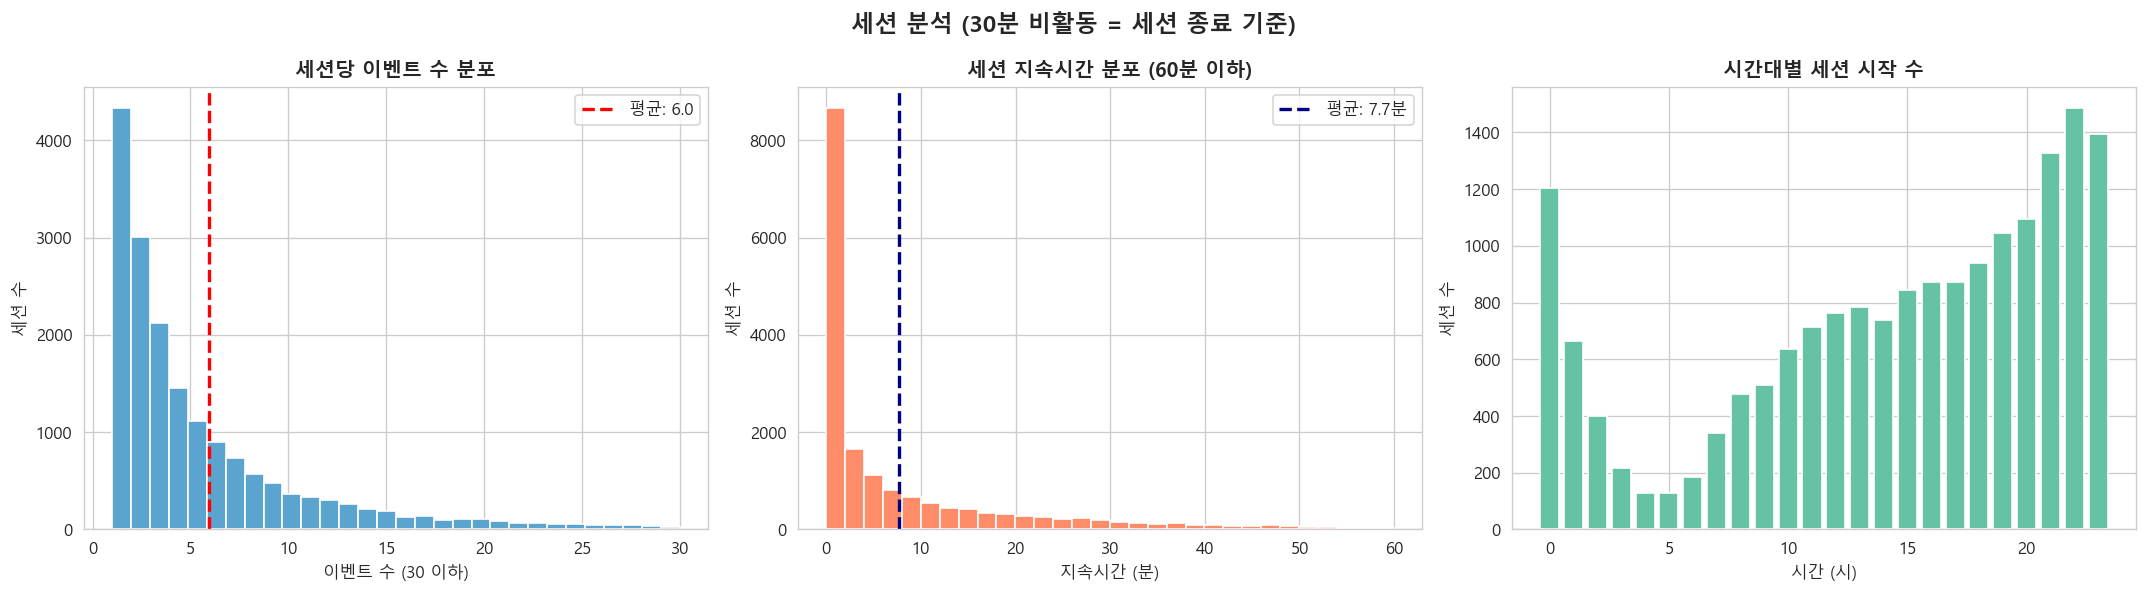

In [42]:
# ── 세션 정의 및 분석 (30분 비활동 = 세션 종료) ─────────────────
SESSION_GAP = pd.Timedelta(minutes=30)

logs_sorted = logs.sort_values(['user_id', 'timestamp']).copy()
logs_sorted['prev_ts'] = logs_sorted.groupby('user_id')['timestamp'].shift(1)
logs_sorted['time_diff'] = logs_sorted['timestamp'] - logs_sorted['prev_ts']
logs_sorted['new_session'] = (
    logs_sorted['prev_ts'].isna() | (logs_sorted['time_diff'] > SESSION_GAP)
)
logs_sorted['session_id'] = logs_sorted.groupby('user_id')['new_session'].cumsum()

# 세션별 통계
session_stats = logs_sorted.groupby(['user_id', 'session_id']).agg(
    session_events=('event_name', 'count'),
    session_duration=('timestamp', lambda x: (x.max() - x.min()).seconds / 60),
    has_click=('event_name', lambda x: (x == 'enter_browser').any()),
    has_bookmark=('event_name', lambda x: (x == 'add_bookmark').any()),
    start_hour=('hour', 'first'),
).reset_index()

# '구매 경험 유저의 세션'으로 정의
buyer_user_ids = set(orders['user_id'])
session_stats['is_buyer_user_session'] = session_stats['user_id'].isin(buyer_user_ids)

total_sessions = len(session_stats)
print('■ 세션 분석 기본 통계')
print(f'  총 세션 수: {total_sessions:,}개')
print(f'  세션당 평균 이벤트: {session_stats["session_events"].mean():.1f}회')
print(f'  세션당 평균 지속시간: {session_stats["session_duration"].mean():.1f}분')
print(f'  세션당 중앙 지속시간: {session_stats["session_duration"].median():.1f}분')
print(f'  클릭 발생 세션 비율: {session_stats["has_click"].mean()*100:.1f}%')
print(f'  즐겨찾기 발생 세션 비율: {session_stats["has_bookmark"].mean()*100:.1f}%')
print()

buyer_user_sess = session_stats[session_stats['is_buyer_user_session']]
nonbuyer_user_sess = session_stats[~session_stats['is_buyer_user_session']]
print('■ 구매 경험 유저 vs 비구매 유저의 세션 비교')
print(f'  구매 경험 유저 세션   – 평균 이벤트: {buyer_user_sess["session_events"].mean():.1f}회  /  평균 지속: {buyer_user_sess["session_duration"].mean():.1f}분')
print(f'  비구매 유저 세션      – 평균 이벤트: {nonbuyer_user_sess["session_events"].mean():.1f}회  /  평균 지속: {nonbuyer_user_sess["session_duration"].mean():.1f}분')
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('세션 분석 (30분 비활동 = 세션 종료 기준)', fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(session_stats['session_events'][session_stats['session_events'] <= 30],
        bins=30, color='#5BA4CF', edgecolor='white')
ax.axvline(session_stats['session_events'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'평균: {session_stats["session_events"].mean():.1f}')
ax.set_title('세션당 이벤트 수 분포', fontsize=12, fontweight='bold')
ax.set_xlabel('이벤트 수 (30 이하)')
ax.set_ylabel('세션 수')
ax.legend()

ax = axes[1]
dur_filtered = session_stats['session_duration'][session_stats['session_duration'] <= 60]
ax.hist(dur_filtered, bins=30, color='#FF8C69', edgecolor='white')
ax.axvline(dur_filtered.mean(), color='navy', linestyle='--', linewidth=2,
           label=f'평균: {dur_filtered.mean():.1f}분')
ax.set_title('세션 지속시간 분포 (60분 이하)', fontsize=12, fontweight='bold')
ax.set_xlabel('지속시간 (분)')
ax.set_ylabel('세션 수')
ax.legend()

ax = axes[2]
session_by_hour = session_stats['start_hour'].value_counts().sort_index()
ax.bar(session_by_hour.index, session_by_hour.values, color='#66C2A5', edgecolor='white')
ax.set_title('시간대별 세션 시작 수', fontsize=12, fontweight='bold')
ax.set_xlabel('시간 (시)')
ax.set_ylabel('세션 수')

plt.tight_layout()
plt.savefig('output/fig_27_session.png', bbox_inches='tight')
plt.show()

## 14. 가격 민감도 분석

유저가 클릭한 상품 가격대와 실제 구매한 상품 가격대를 비교하여 가격 민감도를 파악합니다.


■ 클릭 vs 구매 가격대 비율 비교
            클릭 비율(%)  구매 비율(%)  민감도 지수 (구매/클릭)
price_band                                    
1만원 미만           8.5      12.9            1.52
1-2만원           31.0      37.0            1.20
2-3만원           25.9      26.3            1.02
3-5만원           27.4      20.6            0.75
5-10만원           6.4       2.9            0.45
10만원 이상          0.9       0.2            0.27

※ 민감도 지수 > 1: 클릭 대비 구매 전환이 잘 되는 가격대
※ 민감도 지수 < 1: 클릭은 많지만 구매로 잘 이어지지 않는 가격대 → 가격 저항 존재


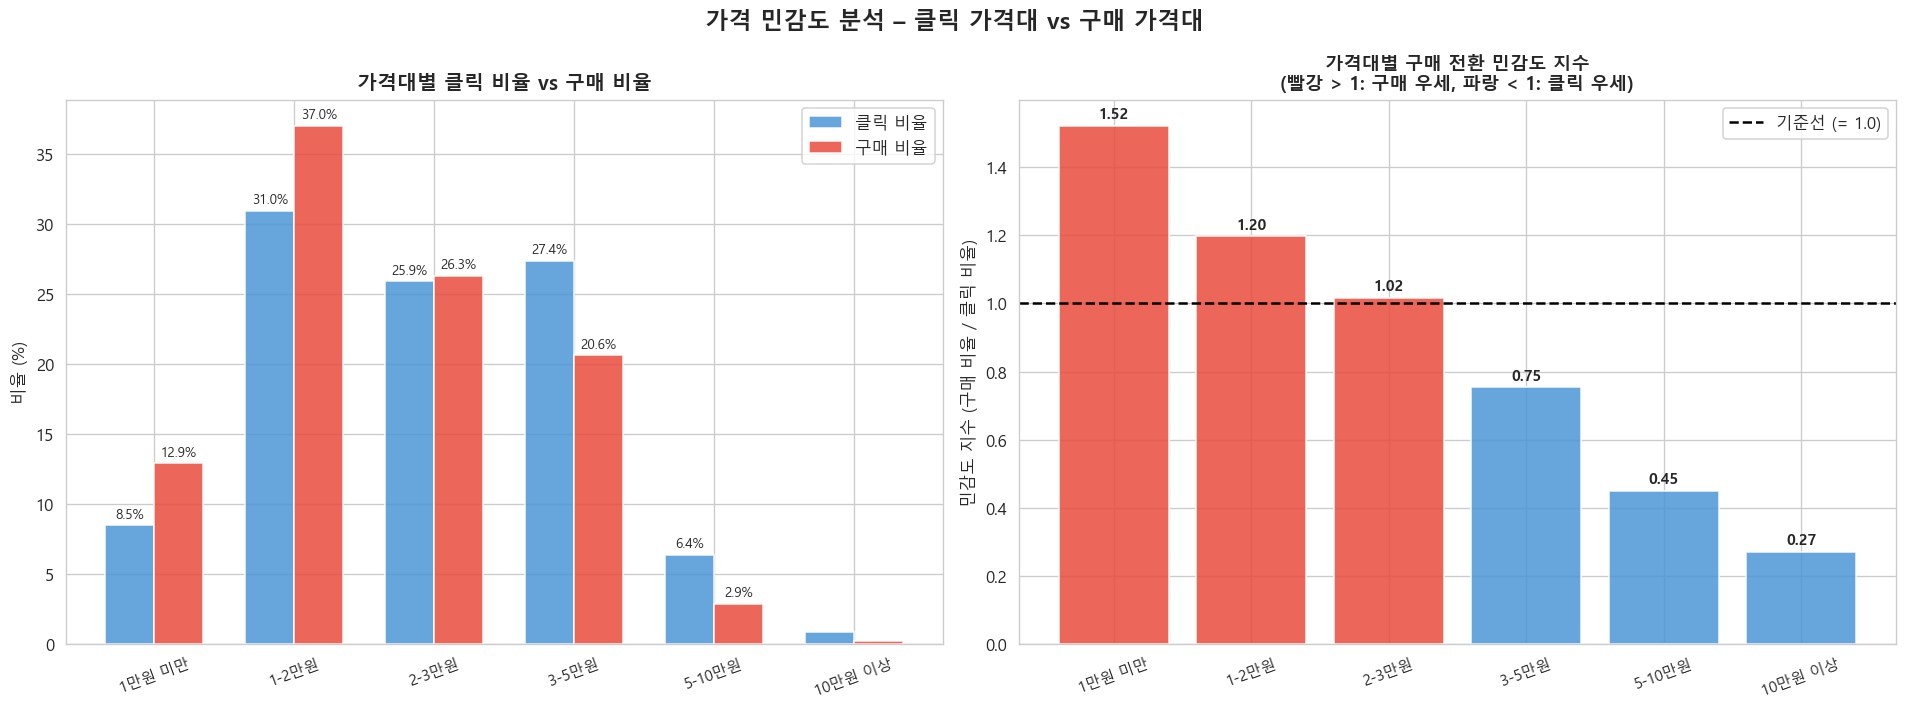

In [43]:
# ── 가격 민감도: 클릭 가격대 vs 구매 가격대 ─────────────────────
price_order = ['1만원 미만','1-2만원','2-3만원','3-5만원','5-10만원','10만원 이상']

# 클릭된 상품 가격대
enter_goods_all = logs[(logs['event_name']=='enter_browser') & (logs['event_goods_id'].notna())].copy()
enter_goods_all['event_goods_id'] = enter_goods_all['event_goods_id'].astype(int)
click_goods_df = enter_goods_all.merge(goods[['goods_id','price','price_band']], 
                                        left_on='event_goods_id', right_on='goods_id', how='left')
click_price = click_goods_df['price_band'].value_counts().reindex(price_order).fillna(0)
click_price_pct = click_price / click_price.sum() * 100

# 구매된 상품 가격대
buy_price = orders['price_band'].value_counts().reindex(price_order).fillna(0)
buy_price_pct = buy_price / buy_price.sum() * 100

# 가격 민감도 지수: 구매 비율 / 클릭 비율 (> 1 이면 해당 가격대가 클릭 대비 구매로 잘 이어짐)
sensitivity = (buy_price_pct / click_price_pct).fillna(0)

print('■ 클릭 vs 구매 가격대 비율 비교')
comparison = pd.DataFrame({
    '클릭 비율(%)': click_price_pct.round(1),
    '구매 비율(%)': buy_price_pct.round(1),
    '민감도 지수 (구매/클릭)': sensitivity.round(2)
})
print(comparison.to_string())
print()
print('※ 민감도 지수 > 1: 클릭 대비 구매 전환이 잘 되는 가격대')
print('※ 민감도 지수 < 1: 클릭은 많지만 구매로 잘 이어지지 않는 가격대 → 가격 저항 존재')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('가격 민감도 분석 – 클릭 가격대 vs 구매 가격대', fontsize=14, fontweight='bold')

# 클릭 vs 구매 가격대 비교 막대
ax = axes[0]
x = np.arange(len(price_order))
w = 0.35
b1 = ax.bar(x - w/2, click_price_pct, w, label='클릭 비율', color='#4C96D7', alpha=0.85)
b2 = ax.bar(x + w/2, buy_price_pct,   w, label='구매 비율', color='#E94B3C', alpha=0.85)
for bar in list(b1)+list(b2):
    h = bar.get_height()
    if h > 1:
        ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.1f}%',
                ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(price_order, rotation=20, fontsize=9)
ax.set_ylabel('비율 (%)')
ax.set_title('가격대별 클릭 비율 vs 구매 비율', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# 민감도 지수
ax = axes[1]
colors_sens = ['#E94B3C' if v > 1 else '#4C96D7' for v in sensitivity]
bars = ax.bar(price_order, sensitivity, color=colors_sens, edgecolor='white', alpha=0.85)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='기준선 (= 1.0)')
for bar, v in zip(bars, sensitivity):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticklabels(price_order, rotation=20, fontsize=9)
ax.set_ylabel('민감도 지수 (구매 비율 / 클릭 비율)')
ax.set_title('가격대별 구매 전환 민감도 지수\n(빨강 > 1: 구매 우세, 파랑 < 1: 클릭 우세)', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('output/fig_28_price_sensitivity.png', bbox_inches='tight')
plt.show()


## 15. 종합 인사이트 요약


In [44]:
print('='*70)
print(' ★ 지그재그 앱 사용자 행동 데이터 EDA - 종합 인사이트 요약 ★')
print('='*70)

print('\n[1] 데이터 개요')
print(f'   - 분석 기간: 2018년 6월 11일 (하루치)')
print(f'   - 총 유저: {users["user_id"].nunique():,}명 (iOS {users[users["os"]=="iOS"].shape[0]:,}명 / Android {users[users["os"]=="And"].shape[0]:,}명)')
print(f'   - 활동 유저: {logs["user_id"].nunique():,}명 ({logs["user_id"].nunique()/users["user_id"].nunique()*100:.1f}%)')
print(f'   - 총 이벤트: {len(logs):,}건  /  총 구매: {len(orders):,}건  /  구매 유저: {orders["user_id"].nunique():,}명')

print('\n[2] 데이터 품질')
print(f'   - 연령 미입력 유저: {(users["age"] < 0).sum():,}명 ({(users["age"] < 0).mean()*100:.1f}%)')
print(f'   - 연령 미입력 구매율 검정 p-value: {p4:.4f}, 효과크기(V): {v4:.3f}')

print('\n[3] 유저 특성')
dominant_age = users[users['age'] >= 0]['age_group'].value_counts().index[0]
print(f'   - 주요 연령층: {dominant_age} ({users[users["age_group"] == dominant_age].shape[0]:,}명)')
print(f'   - iOS vs Android: {users[users["os"]=="iOS"].shape[0]/len(users)*100:.1f}% vs {users[users["os"]=="And"].shape[0]/len(users)*100:.1f}%')
print(f'   - 유저 1인당 평균 이벤트: {user_event_cnt.mean():.1f}회 (중앙값: {user_event_cnt.median():.0f}회)')

print('\n[4] 이벤트/행동 패턴')
peak_hour = hourly.loc[hourly['count'].idxmax(), 'hour']
top_origin = logs['origin_type'].value_counts().index[0]
print(f'   - 피크 시간대: {int(peak_hour)}시 ({hourly.loc[hourly["count"].idxmax(), "count"]:,}건)')
print(f'   - 주요 유입 경로: {top_origin}')
print(f'   - 유저 단위 퍼널 – 조회→클릭: {users_clicked/users_viewed*100:.1f}%  /  클릭→구매: {users_bought/users_clicked*100:.1f}%')
if "origin_eff" in globals():
    print(f'   - 클릭→구매 연결 효율 1위 유입 경로: {origin_eff.index[0]} ({origin_eff.iloc[0]["클릭대비_구매연결율(%)"]:.2f}%)')

print('\n[5] 상품/카테고리 인사이트')
top_cat = goods['category'].value_counts().index[0]
print(f'   - 상품 수 1위 카테고리: {top_cat} ({goods["category"].value_counts().iloc[0]:,}개)')
print(f'   - 구매 전환율 1위 카테고리: {cat_conv.index[0]} ({cat_conv["전환율"].iloc[0]:.1f}%) ← 95% CI 함께 해석')
print(f'   - 평균 상품가: {goods["price"].mean():,.0f}원  /  평균 구매가: {orders["price"].mean():,.0f}원')

print('\n[6] 심화 분석 결과')
print(f'   - 세션 분석: 총 {total_sessions:,}개 세션, 세션당 평균 이벤트 {session_stats["session_events"].mean():.1f}회')
print(f'   - 구매 여부와 가장 높은 상관 행동: {buyer_corr.index[0]} (r={buyer_corr.iloc[0]:.3f})')
print(f'   - 가격 민감도 최고 구간: {comparison["민감도 지수 (구매/클릭)"].astype(float).idxmax()}')
print(f'   - 활동 수준별 최고 구매율 구간: {activity_purchase["구매율(%)"].idxmax()} ({activity_purchase["구매율(%)"].max():.1f}%)')
if "top_hidden" in globals():
    print(f'   - 상품 수 보정 후 숨은 고효율 쇼핑몰 예시: {top_hidden.iloc[0]["name"]}')

print('\n' + '='*70)

 ★ 지그재그 앱 사용자 행동 데이터 EDA - 종합 인사이트 요약 ★

[1] 데이터 개요
   - 분석 기간: 2018년 6월 11일 (하루치)
   - 총 유저: 10,000명 (iOS 5,079명 / Android 4,921명)
   - 활동 유저: 9,909명 (99.1%)
   - 총 이벤트: 105,815건  /  총 구매: 867건  /  구매 유저: 832명

[2] 데이터 품질
   - 연령 미입력 유저: 343명 (3.4%)
   - 연령 미입력 구매율 검정 p-value: 0.0099, 효과크기(V): 0.026

[3] 유저 특성
   - 주요 연령층: 10대 (1,737명)
   - iOS vs Android: 50.8% vs 49.2%
   - 유저 1인당 평균 이벤트: 10.7회 (중앙값: 5회)

[4] 이벤트/행동 패턴
   - 피크 시간대: 22시 (9,677건)
   - 주요 유입 경로: 즐겨찾기
   - 유저 단위 퍼널 – 조회→클릭: 44.7%  /  클릭→구매: 18.8%
   - 클릭→구매 연결 효율 1위 유입 경로: 내 상품 (31.53%)

[5] 상품/카테고리 인사이트
   - 상품 수 1위 카테고리: 상의 (2,046개)
   - 구매 전환율 1위 카테고리: 란제리&파자마 (13.8%) ← 95% CI 함께 해석
   - 평균 상품가: 30,186원  /  평균 구매가: 22,790원

[6] 심화 분석 결과
   - 세션 분석: 총 17,778개 세션, 세션당 평균 이벤트 6.0회
   - 구매 여부와 가장 높은 상관 행동: click_count (r=0.441)
   - 가격 민감도 최고 구간: 1만원 미만
   - 활동 수준별 최고 구매율 구간: 51회+ (44.2%)
   - 상품 수 보정 후 숨은 고효율 쇼핑몰 예시: Edie

